# MNIST AGOP Analysis

Comprehensive analysis of 12 completed MNIST experiments comparing:
- **Optimizers**: AdamW, Muon, SGD
- **Weight Decays**: 0.01, 0.1, 0.5, 1.0

This notebook analyzes:
1. Performance metrics (accuracy, grokking outcomes)
2. AGOP metric evolution and relationship to grokking
3. Statistical comparisons between optimizers
4. Normalized overlay plots of AGOP metrics with train/test accuracy


In [16]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

sys.path.append(str(Path.cwd()))
from analysis_utils import (
    load_all_experiments, generate_summary_table, classify_grokking,
    compute_time_to_grok, statistical_comparison, filter_experiments,
    plot_agop_comparison, create_comparison_heatmap, smooth_series,
    detect_phase_transitions, compute_correlation
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Paths
RESULTS_DIR = Path('../results/mnist')
FIGURES_DIR = Path('./figures/mnist')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Results directory: {RESULTS_DIR.absolute()}")
print(f"Figures will be saved to: {FIGURES_DIR.absolute()}")


Results directory: /net/vast-storage/scratch/vast/lhtsai/mabdel03/files/Classes/9.520/9.520-The-Geometry-of-Grok/New_Explorations/agop_experiments/analysis/../results/mnist
Figures will be saved to: /net/vast-storage/scratch/vast/lhtsai/mabdel03/files/Classes/9.520/9.520-The-Geometry-of-Grok/New_Explorations/agop_experiments/analysis/figures/mnist


## Load All MNIST Experiments


In [17]:
experiments = load_all_experiments(RESULTS_DIR)
print(f"Loaded {len(experiments)} experiments")

summary_df = generate_summary_table(experiments)
print(f"\nSummary of experiments:")
display(summary_df.sort_values(['optimizer', 'weight_decay']))


Loaded 12 experiments

Summary of experiments:


,experiment,architecture,optimizer,weight_decay,lr,final_test_acc,max_test_acc,final_train_acc,grokked,grok_epoch
0,mnist_adamw_wd0.01_seed42,unknown,adamw,0.01,0.001,0.6772,0.6772,1.000,False,-1
1,mnist_adamw_wd0.1_seed42,unknown,adamw,0.10,0.001,0.9246,0.9258,1.000,False,-1
2,mnist_adamw_wd0.5_seed42,unknown,adamw,0.50,0.001,0.9146,0.9213,1.000,False,-1
3,mnist_adamw_wd1.0_seed42,unknown,adamw,1.00,0.001,0.9098,0.9167,1.000,False,-1
4,mnist_muon_wd0.01_seed42,unknown,muon,0.01,0.001,0.6026,0.6026,1.000,False,-1
5,mnist_muon_wd0.1_seed42,unknown,muon,0.10,0.001,0.9005,0.9013,1.000,False,-1
6,mnist_muon_wd0.5_seed42,unknown,muon,0.50,0.001,0.9162,0.9168,1.000,False,-1
7,mnist_muon_wd1.0_seed42,unknown,muon,1.00,0.001,0.9250,0.9267,1.000,False,-1
8,mnist_sgd_wd0.01_seed42,unknown,sgd,0.01,0.001,0.7742,0.8609,0.795,False,-1
9,mnist_sgd_wd0.1_seed42,unknown,sgd,0.10,0.001,0.1135,0.5651,0.120,False,-1


In [ ]:
# Define grokking detection function (needed for statistics)
def detect_grokking_epoch(train_acc, test_acc, grok_threshold=0.85, min_epoch=100, 
                         slope_window=20, slope_threshold=0.0005):
    """
    Detect the grokking epoch as the inflection point where test accuracy curve 
    transitions from increasing to flattening, for experiments that end with accuracy ≥ 0.85.
    
    Args:
        train_acc: Array of training accuracies (unused, kept for compatibility)
        test_acc: Array of test accuracies
        grok_threshold: Final test accuracy threshold to define grokking (default 0.85)
        min_epoch: Minimum epoch to start checking (avoid early noise)
        slope_window: Window size for computing slope (default 20)
        slope_threshold: Slope threshold to consider "flattening" (default 0.0005)
    
    Returns:
        Grokking epoch (int) or None if no grokking detected
    """
    # First check if this experiment grokked (final accuracy >= threshold)
    if len(test_acc) == 0 or test_acc[-1] < grok_threshold:
        return None
    
    if len(test_acc) < min_epoch + slope_window:
        return None
    
    # Compute rolling slopes to find inflection point
    best_inflection = None
    max_slope_before = 0
    
    for i in range(min_epoch, len(test_acc) - slope_window):
        # Compute slope before this point
        if i >= slope_window:
            window_before = test_acc[i-slope_window:i]
            slope_before = (window_before[-1] - window_before[0]) / slope_window
        else:
            slope_before = (test_acc[i] - test_acc[max(0, i-10)]) / min(i, 10)
        
        # Compute slope after this point
        window_after = test_acc[i:i+slope_window]
        slope_after = (window_after[-1] - window_after[0]) / slope_window
        
        # Look for transition: was increasing (slope_before > threshold), now flattening (slope_after < threshold)
        if slope_before > slope_threshold and slope_after <= slope_threshold:
            # Found an inflection point
            if slope_before > max_slope_before:
                max_slope_before = slope_before
                best_inflection = i
    
    return best_inflection

print("Grokking detection function loaded.")
print(f"Grokking definition: Inflection point where test accuracy curve transitions from increasing to flattening")
print(f"                     (only for experiments ending with test accuracy ≥ 0.85)")

# Group experiments by optimizer for organized plotting
mnist_by_opt = {}
for opt in ['adamw', 'muon', 'sgd']:
    opt_exps = {name: data for name, data in experiments.items() 
                if data['config'].get('optimizer') == opt}
    if len(opt_exps) > 0:
        mnist_by_opt[opt] = sorted(opt_exps.items(), 
                                   key=lambda x: x[1]['config'].get('weight_decay', 0))

print(f"\nExperiments grouped by optimizer: {list(mnist_by_opt.keys())}")


Grokking detection function loaded.
Grokking definition: Inflection point where test accuracy curve transitions from increasing to flattening
                     (only for experiments ending with test accuracy ≥ 0.85)

Experiments grouped by optimizer: ['adamw', 'muon', 'sgd']


## Quick Statistics


In [ ]:
# Compute grokking statistics using our custom detection function
total = len(experiments)
grokking_results = {}

for exp_name, exp_data in experiments.items():
    history = exp_data.get('history', {})
    config = exp_data.get('config', {})
    
    if 'train_acc' in history and 'test_acc' in history:
        train_acc = np.array(history['train_acc'])
        test_acc = np.array(history['test_acc'])
        grok_epoch_idx = detect_grokking_epoch(train_acc, test_acc)
        
        grokking_results[exp_name] = {
            'optimizer': config.get('optimizer', 'unknown'),
            'weight_decay': config.get('weight_decay', 0),
            'grokked': grok_epoch_idx is not None,
            'final_test_acc': test_acc[-1] if len(test_acc) > 0 else 0
        }

# Overall statistics
grokked = sum(1 for r in grokking_results.values() if r['grokked'])
grok_rate = (grokked / total * 100) if total > 0 else 0

print(f"="*80)
print(f"MNIST DATASET - OVERALL STATISTICS")
print(f"="*80)
print(f"Total experiments: {total}")
print(f"Grokked: {grokked} ({grok_rate:.1f}%)")
print(f"Failed to grok: {total - grokked} ({100-grok_rate:.1f}%)")
print()

# By optimizer
print(f"By Optimizer:")
print(f"-"*80)
for opt in ['adamw', 'muon', 'sgd']:
    opt_results = [r for r in grokking_results.values() if r['optimizer'] == opt]
    if opt_results:
        opt_grok = sum(1 for r in opt_results if r['grokked'])
        opt_total = len(opt_results)
        print(f"  {opt.upper()}: {opt_grok}/{opt_total} grokked ({opt_grok/opt_total*100:.1f}%)")

print(f"="*80)

# Store grok rate for later use
grok_rate_value = grok_rate


MNIST DATASET - OVERALL STATISTICS
Total experiments: 12
Grokked: 4 (33.3%)
Failed to grok: 8 (66.7%)

By Optimizer:
--------------------------------------------------------------------------------
  ADAMW: 3/4 grokked (75.0%)
  MUON: 1/4 grokked (25.0%)
  SGD: 0/4 grokked (0.0%)


---
# Section 0: Training Dynamics - Accuracy and Loss Curves

**First Analytical Insight**: Visualize training and test accuracy/loss over epochs for all completed experiments. 
Red dashed vertical lines indicate the "grokking epoch" where test performance catches up with train performance.


In [ ]:
def detect_grokking_epoch(train_acc, test_acc, grok_threshold=0.85, min_epoch=100, 
                         slope_window=20, slope_threshold=0.0005):
    """
    Detect the grokking epoch as the inflection point where test accuracy curve 
    transitions from increasing to flattening, for experiments that end with accuracy ≥ 0.85.
    
    Args:
        train_acc: Array of training accuracies (unused, kept for compatibility)
        test_acc: Array of test accuracies
        grok_threshold: Final test accuracy threshold to define grokking (default 0.85)
        min_epoch: Minimum epoch to start checking (avoid early noise)
        slope_window: Window size for computing slope (default 20)
        slope_threshold: Slope threshold to consider "flattening" (default 0.0005)
    
    Returns:
        Grokking epoch (int) or None if no grokking detected
    """
    # First check if this experiment grokked (final accuracy >= threshold)
    if len(test_acc) == 0 or test_acc[-1] < grok_threshold:
        return None
    
    if len(test_acc) < min_epoch + slope_window:
        return None
    
    # Compute rolling slopes to find inflection point
    best_inflection = None
    max_slope_before = 0
    
    for i in range(min_epoch, len(test_acc) - slope_window):
        # Compute slope before this point
        if i >= slope_window:
            window_before = test_acc[i-slope_window:i]
            slope_before = (window_before[-1] - window_before[0]) / slope_window
        else:
            slope_before = (test_acc[i] - test_acc[max(0, i-10)]) / min(i, 10)
        
        # Compute slope after this point
        window_after = test_acc[i:i+slope_window]
        slope_after = (window_after[-1] - window_after[0]) / slope_window
        
        # Look for transition: was increasing (slope_before > threshold), now flattening (slope_after < threshold)
        if slope_before > slope_threshold and slope_after <= slope_threshold:
            # Found an inflection point
            if slope_before > max_slope_before:
                max_slope_before = slope_before
                best_inflection = i
    
    return best_inflection

print("Grokking detection function loaded.")
print(f"Grokking definition: Inflection point where test accuracy curve transitions from increasing to flattening")
print(f"                     (only for experiments ending with test accuracy ≥ 0.85)")

# Group experiments by optimizer for organized plotting
mnist_by_opt = {}
for opt in ['adamw', 'muon', 'sgd']:
    opt_exps = {name: data for name, data in experiments.items() 
                if data['config'].get('optimizer') == opt}
    if len(opt_exps) > 0:
        mnist_by_opt[opt] = sorted(opt_exps.items(), 
                                   key=lambda x: x[1]['config'].get('weight_decay', 0))

print(f"\nExperiments grouped by optimizer: {list(mnist_by_opt.keys())}")


Grokking detection function loaded.
Grokking definition: Inflection point where test accuracy curve transitions from increasing to flattening
                     (only for experiments ending with test accuracy ≥ 0.85)

Experiments grouped by optimizer: ['adamw', 'muon', 'sgd']


## Generate Training Dynamics Plots for All Experiments


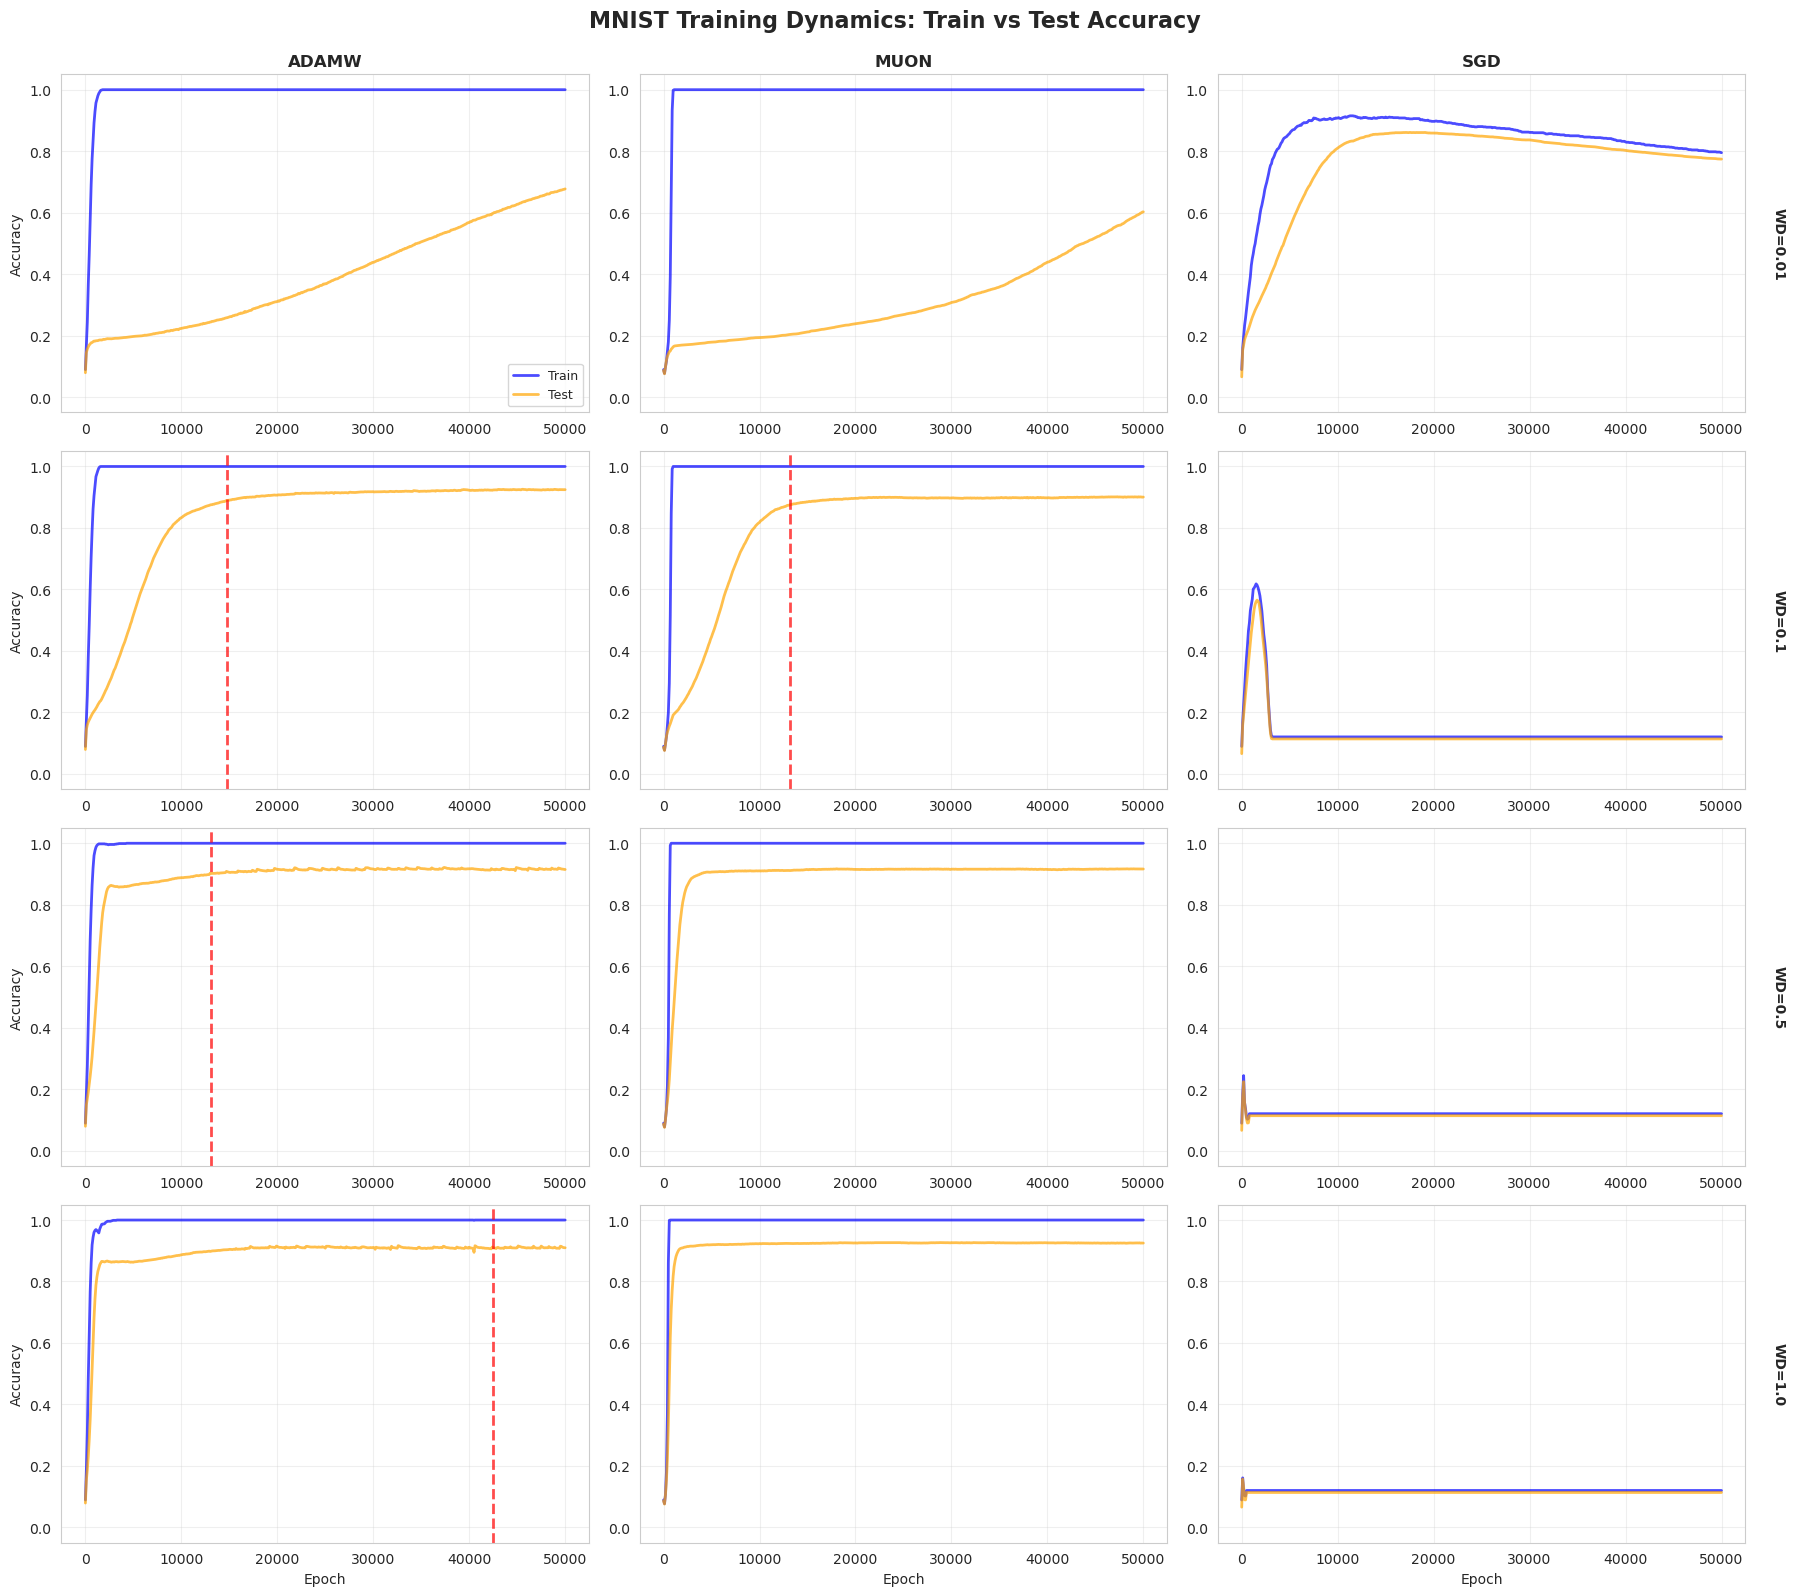

Generated 4×3 accuracy panel


In [ ]:
# Create single 4x3 panel for train/test accuracy
fig, axes = plt.subplots(4, 3, figsize=(18, 16))

for row_idx, wd in enumerate([0.01, 0.1, 0.5, 1.0]):
    for col_idx, opt in enumerate(['adamw', 'muon', 'sgd']):
        ax = axes[row_idx, col_idx]
        
        # Find the experiment for this optimizer-weight_decay combination
        if opt not in mnist_by_opt:
            ax.axis('off')
            continue
        
        exp_found = False
        for exp_name, exp_data in mnist_by_opt[opt]:
            config = exp_data.get('config', {})
            if config.get('weight_decay', 0) == wd:
                history = exp_data.get('history', {})
                
                if 'train_acc' not in history or 'test_acc' not in history:
                    break
                
                epochs = np.array(history.get('epoch', range(len(history['test_acc']))))
                train_acc = np.array(history['train_acc'])
                test_acc = np.array(history['test_acc'])
                
                # Detect grokking
                grok_epoch_idx = detect_grokking_epoch(train_acc, test_acc)
                grok_epoch = epochs[grok_epoch_idx] if grok_epoch_idx is not None else None
                
                # Plot train and test accuracy
                ax.plot(epochs, train_acc, 'b-', linewidth=2, label='Train', alpha=0.7)
                ax.plot(epochs, test_acc, 'orange', linewidth=2, label='Test', alpha=0.7)
                
                # Mark grokking epoch
                if grok_epoch is not None:
                    ax.axvline(x=grok_epoch, color='red', linestyle='--', linewidth=2, alpha=0.7)
                
                exp_found = True
                break
        
        if not exp_found:
            ax.axis('off')
            continue
        
        # Formatting
        ax.set_ylabel('Accuracy' if col_idx == 0 else '', fontsize=10)
        ax.set_xlabel('Epoch' if row_idx == 3 else '', fontsize=10)
        ax.set_ylim([-0.05, 1.05])
        ax.grid(alpha=0.3)
        
        # Add title for top row (optimizer names)
        if row_idx == 0:
            ax.set_title(opt.upper(), fontsize=12, fontweight='bold')
        
        # Add weight decay label on right side
        if col_idx == 2:
            ax.text(1.05, 0.5, f'WD={wd}', transform=ax.transAxes,
                   fontsize=10, fontweight='bold', rotation=270,
                   verticalalignment='center')
        
        # Add legend only on top-left subplot
        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=9, loc='best')

fig.suptitle('MNIST Training Dynamics: Train vs Test Accuracy', 
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'mnist_training_accuracy_4x3.png', dpi=300, bbox_inches='tight')
plt.show()

print("Generated 4×3 accuracy panel")


## Training Dynamics Overview (Grid of All Experiments)



Generating absolute Variation Collapse Ratio plot...


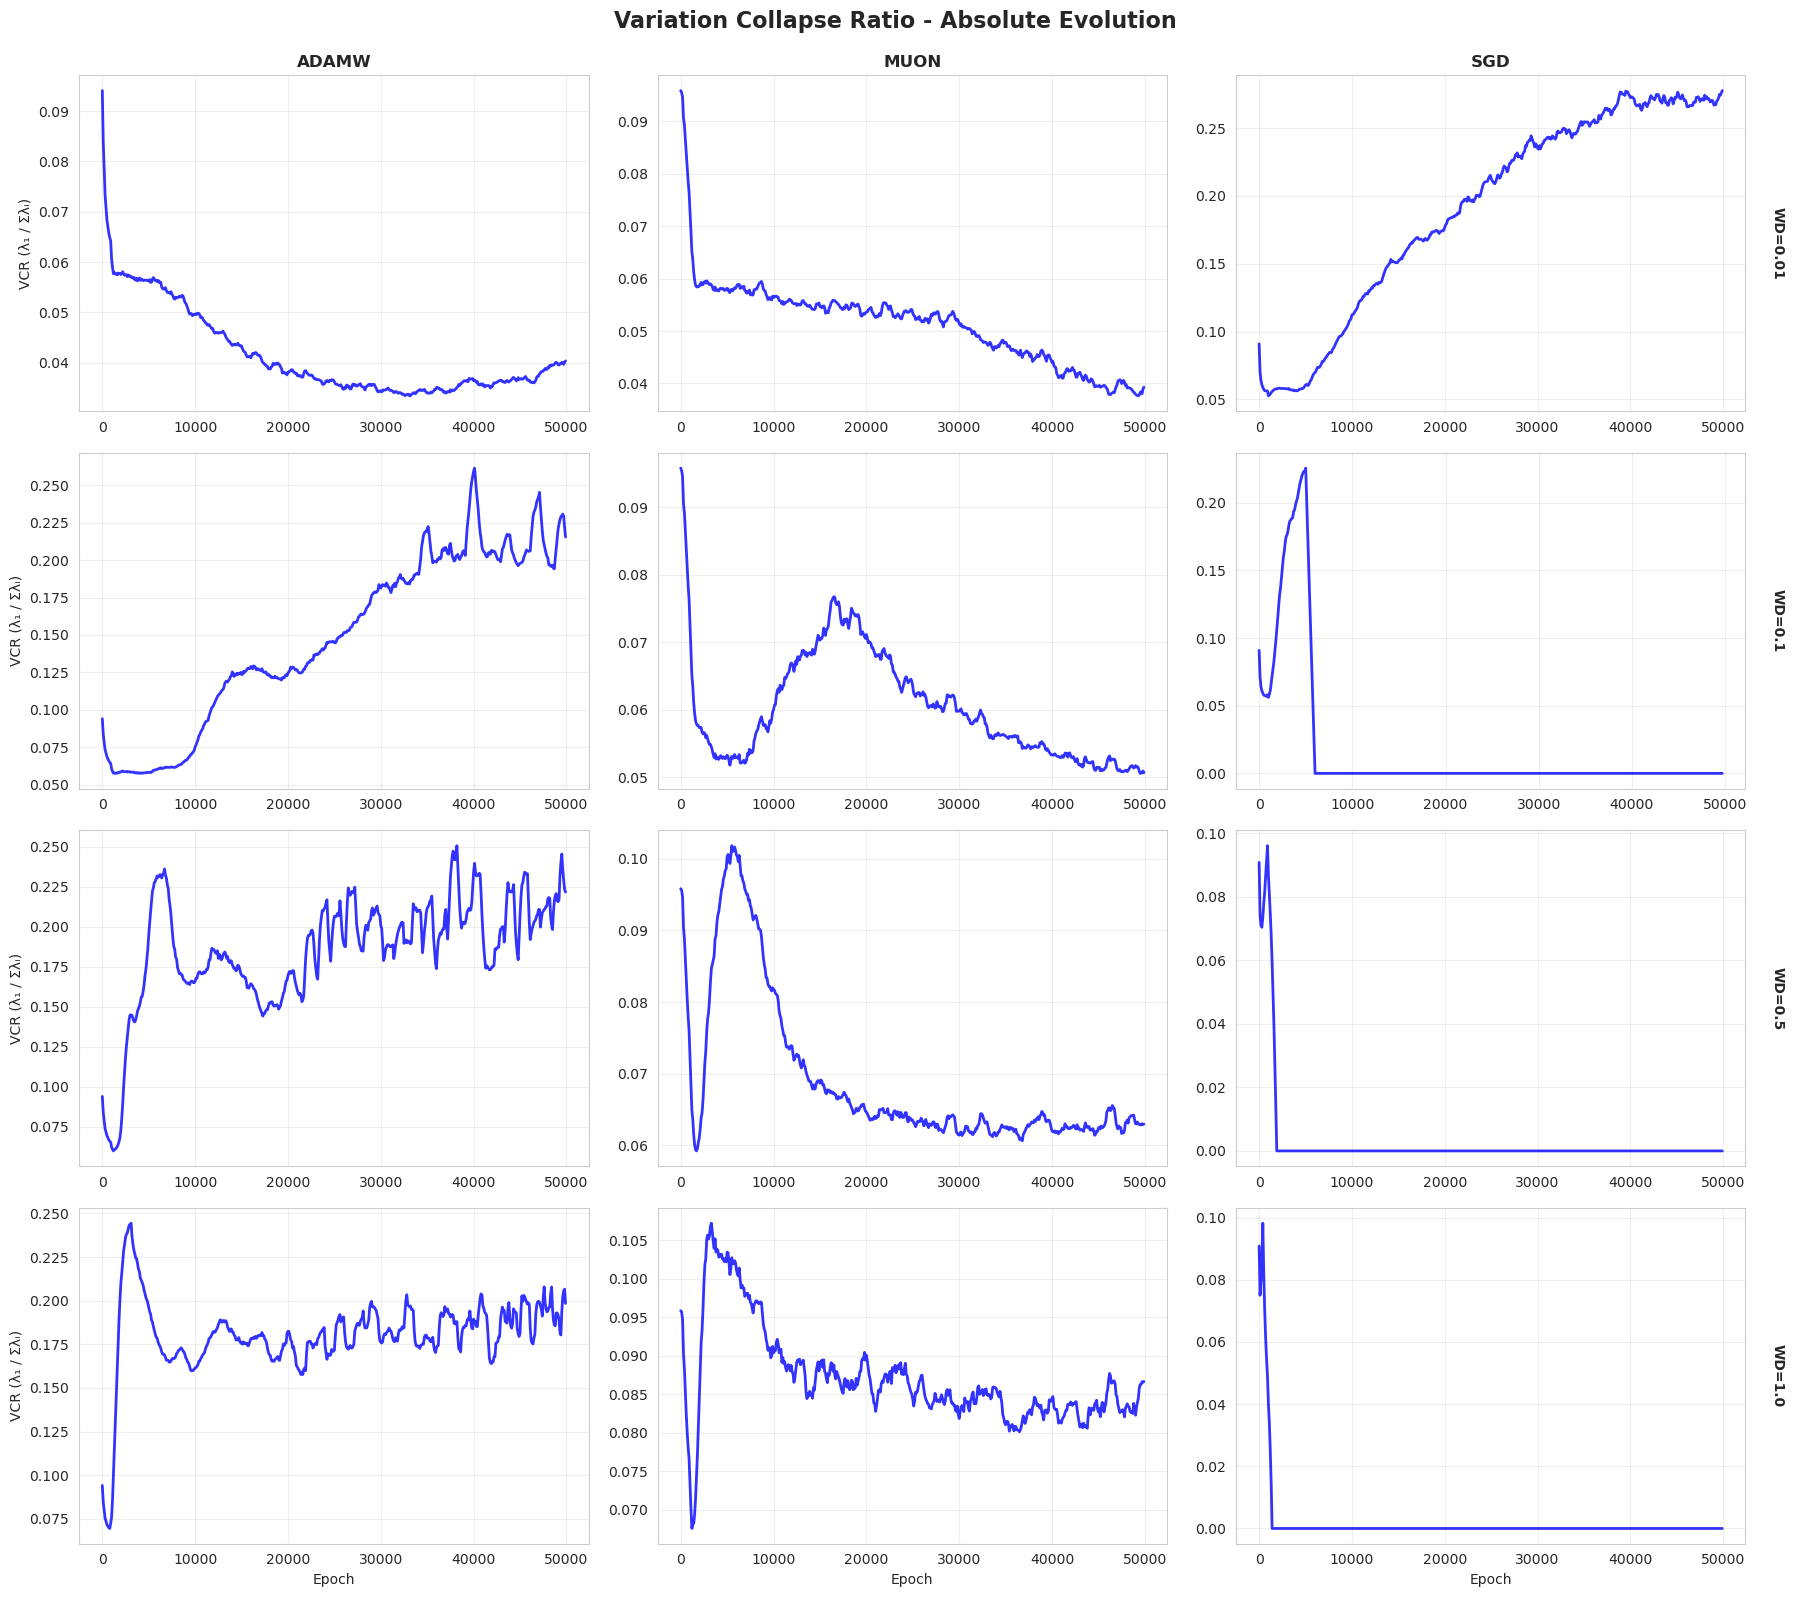

  Saved: mnist_agop_variation_collapse_ratio_absolute_4x3.png

Generating absolute Eigengap plot...


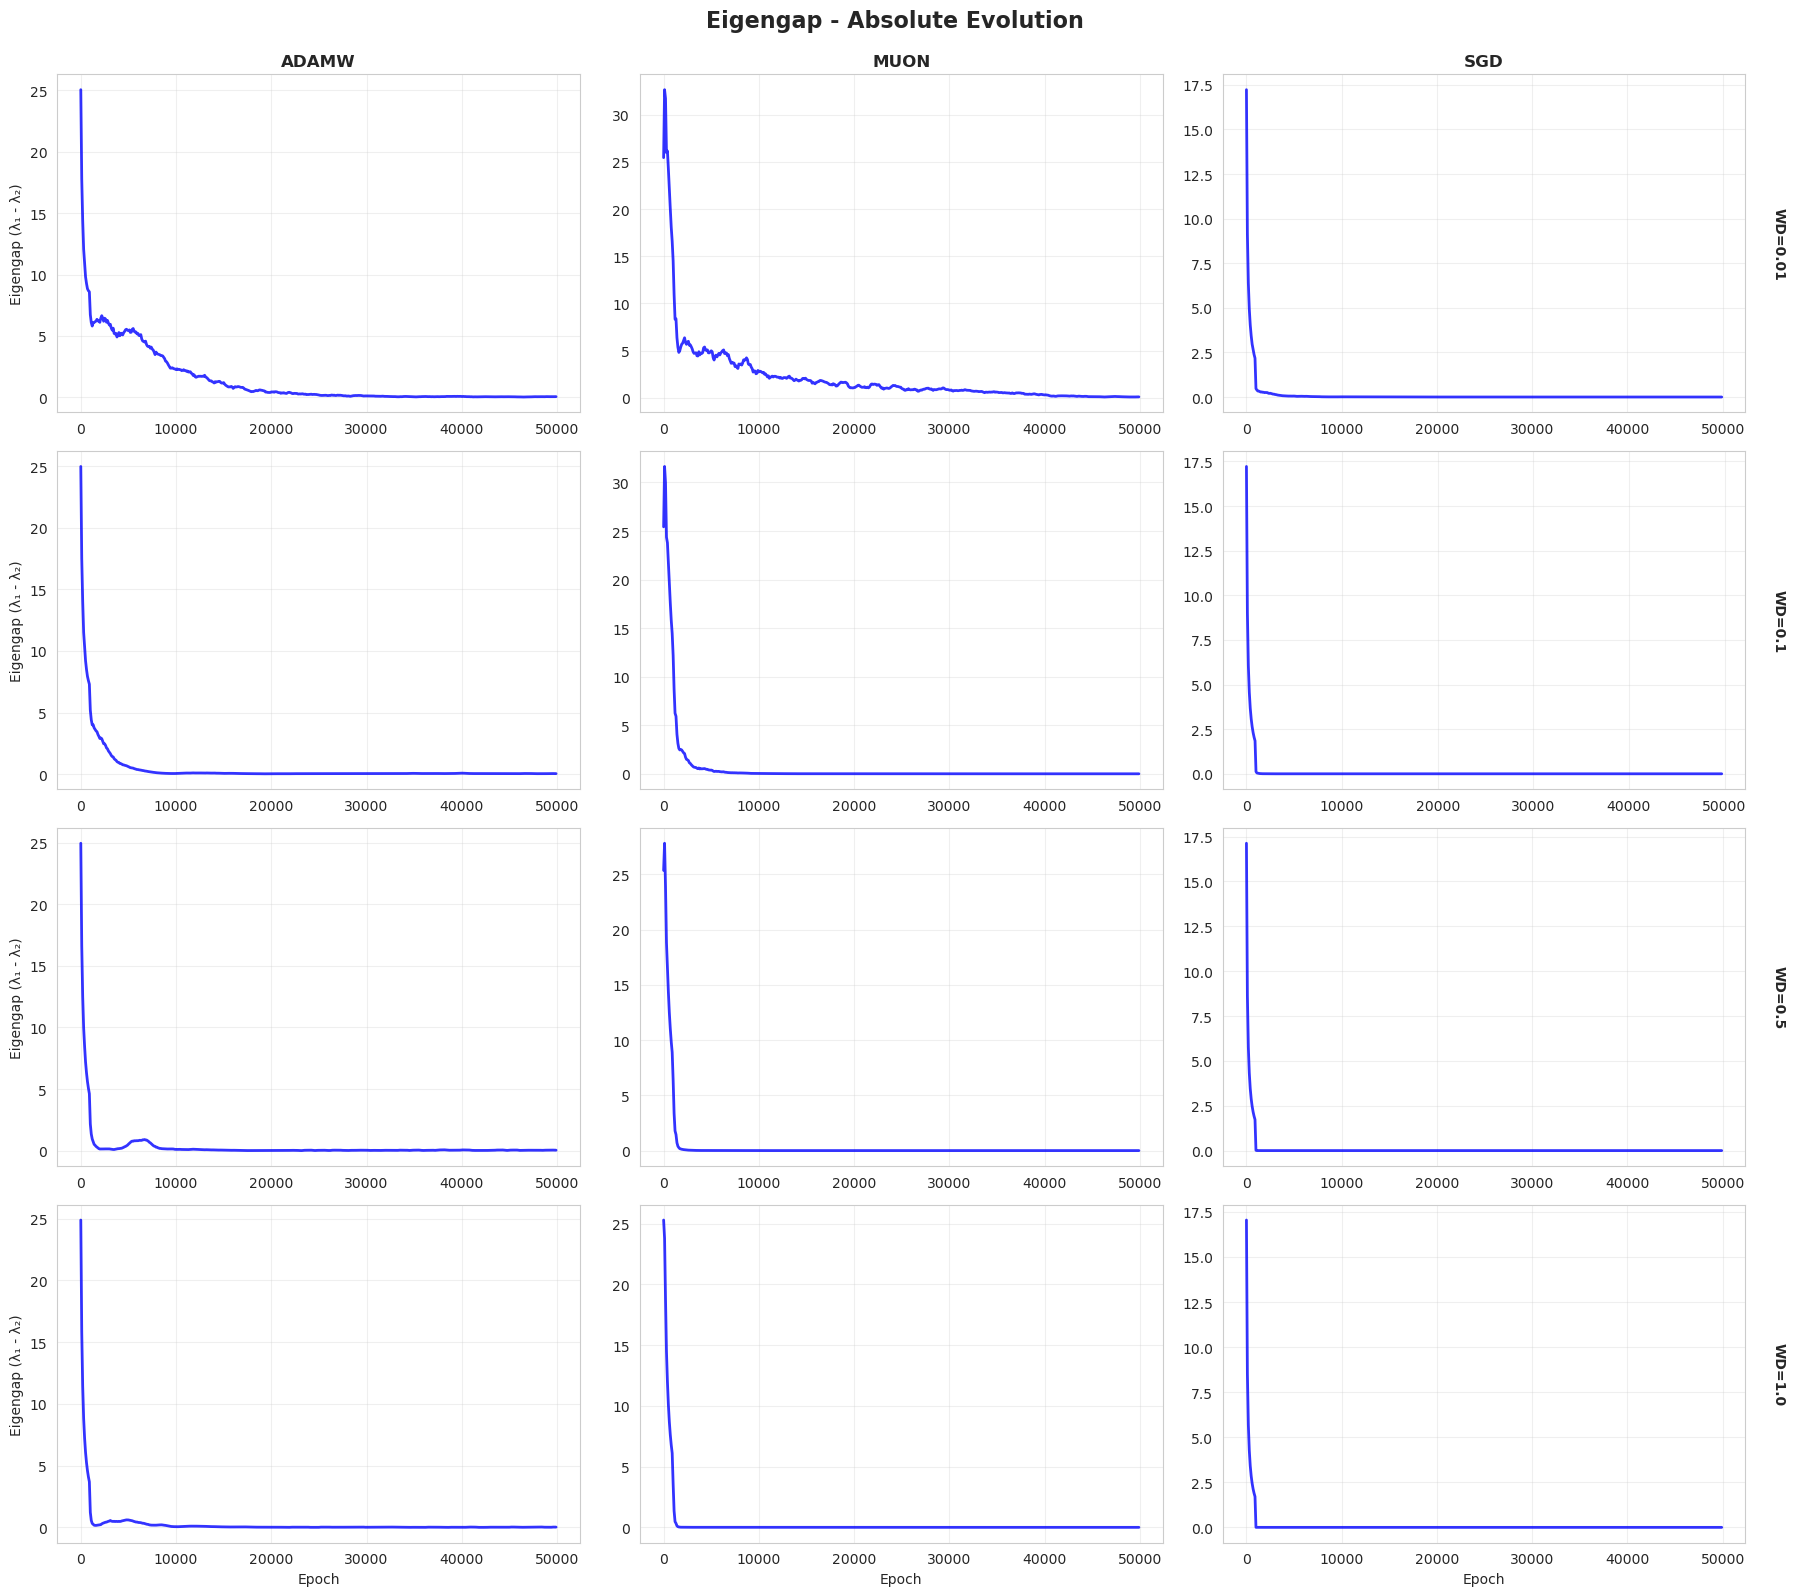

  Saved: mnist_agop_eigengap_absolute_4x3.png

Generating absolute Trace plot...


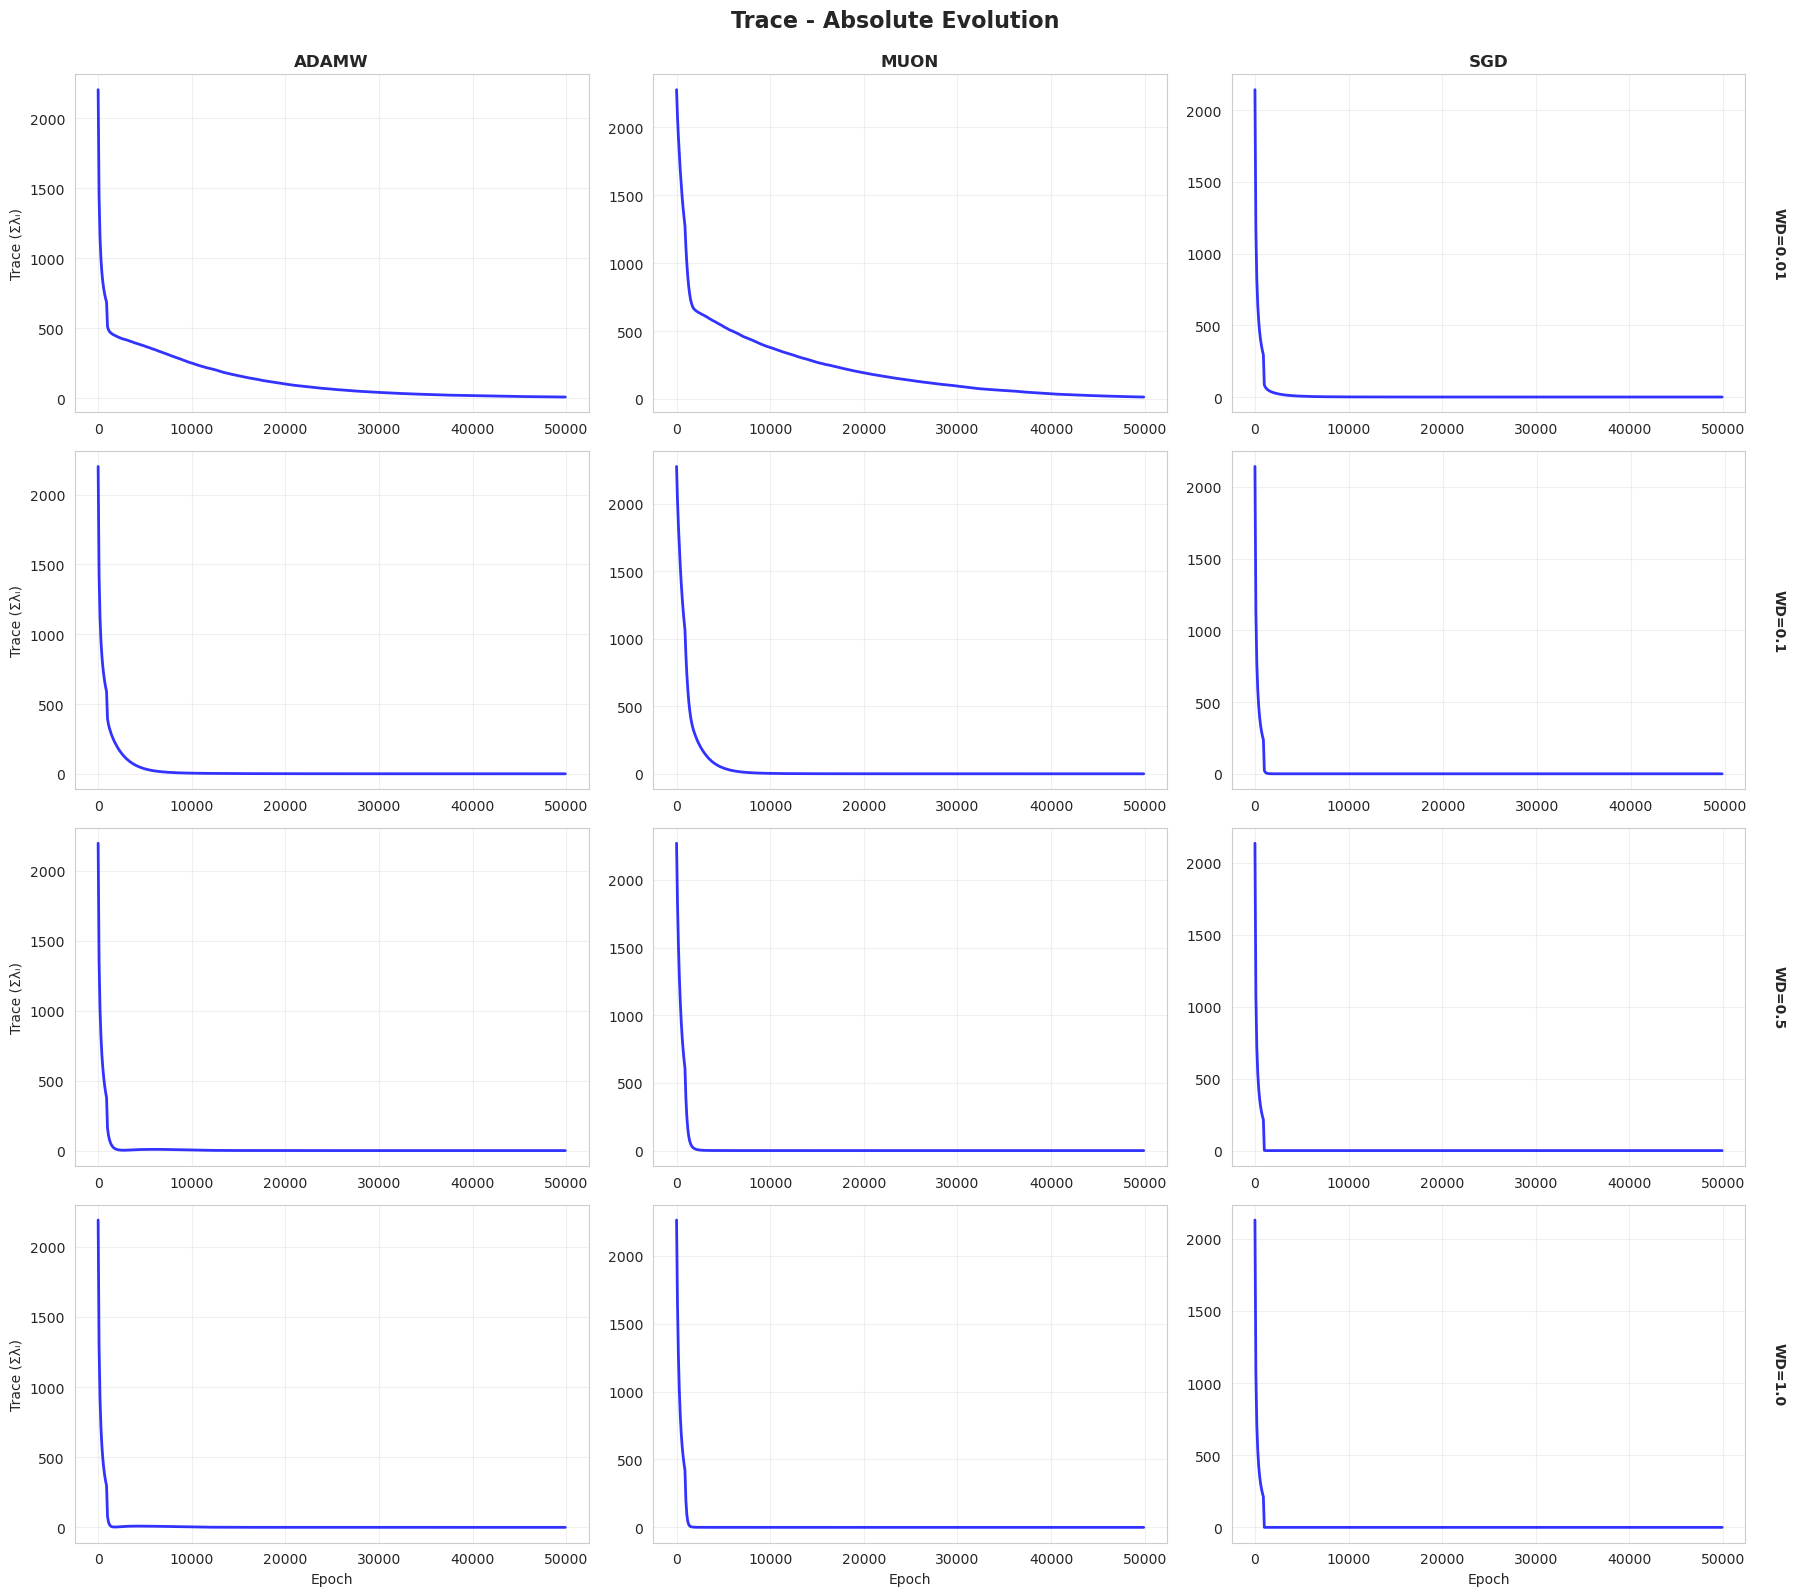

  Saved: mnist_agop_trace_absolute_4x3.png

Generating absolute Spectral Radius plot...


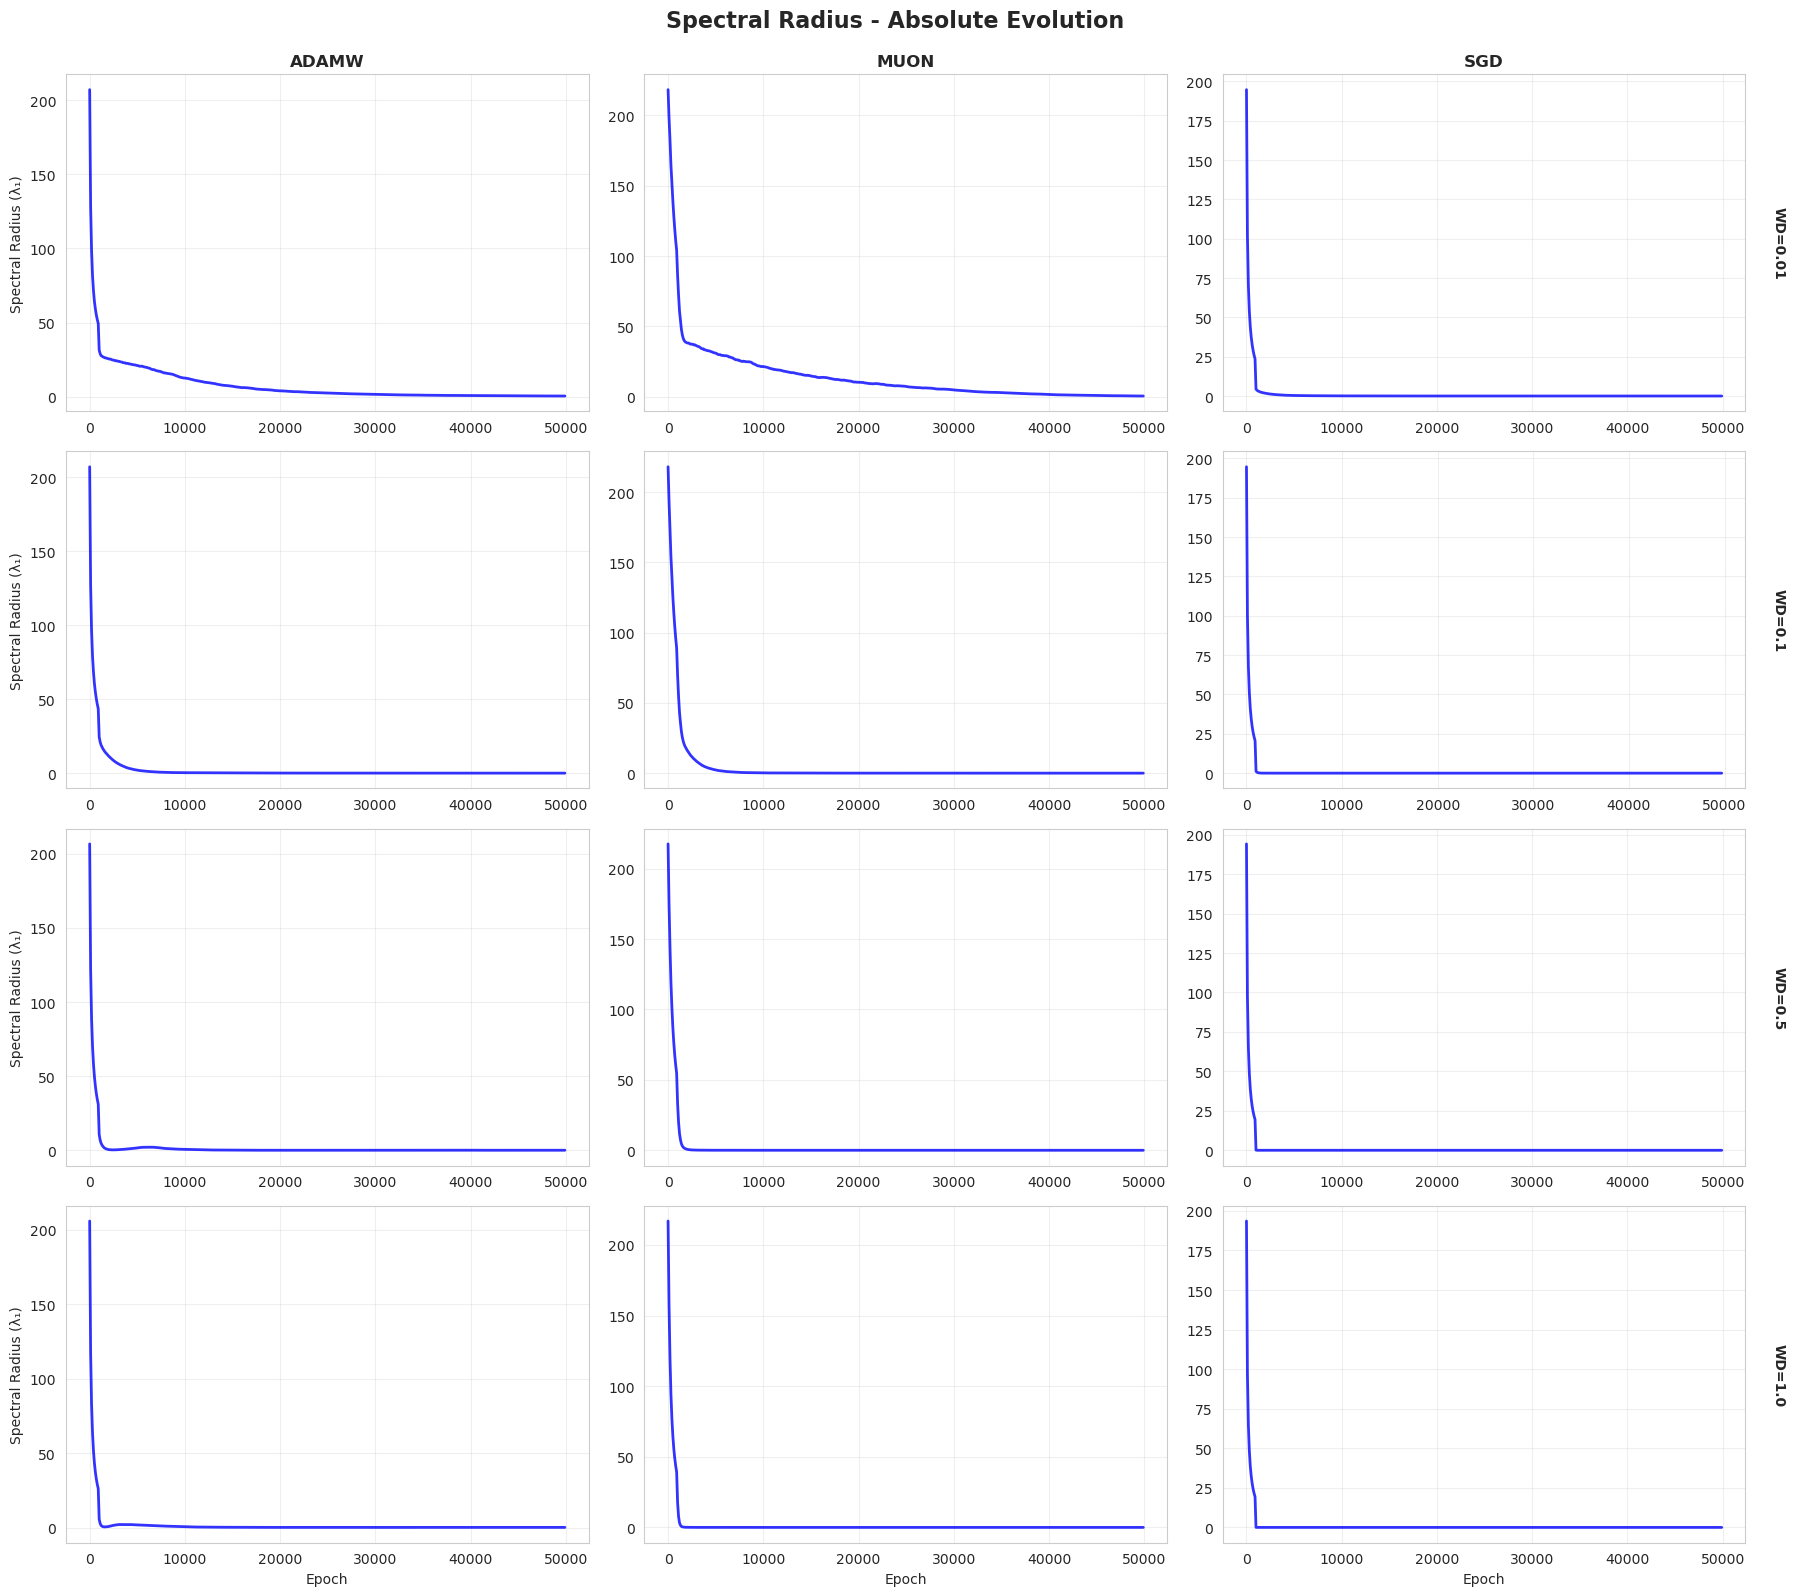

  Saved: mnist_agop_spectral_radius_absolute_4x3.png

Completed Section 1: Absolute AGOP metrics


In [ ]:
# Define AGOP metrics to analyze
agop_metrics = [
    ('agop_variation_collapse_ratio', 'VCR (λ₁ / Σλᵢ)', 'Variation Collapse Ratio'),
    ('agop_eigengap', 'Eigengap (λ₁ - λ₂)', 'Eigengap'),
    ('agop_trace', 'Trace (Σλᵢ)', 'Trace'),
    ('agop_spectral_radius', 'Spectral Radius (λ₁)', 'Spectral Radius'),
]

# Create 4x3 panel for each AGOP metric (absolute values)
for metric_name, metric_label, metric_title in agop_metrics:
    print(f"\nGenerating absolute {metric_title} plot...")
    
    fig, axes = plt.subplots(4, 3, figsize=(18, 16))
    
    for row_idx, wd in enumerate([0.01, 0.1, 0.5, 1.0]):
        for col_idx, opt in enumerate(['adamw', 'muon', 'sgd']):
            ax = axes[row_idx, col_idx]
            
            # Find the experiment for this optimizer-weight_decay combination
            if opt not in mnist_by_opt:
                ax.axis('off')
                continue
            
            exp_found = False
            for exp_name, exp_data in mnist_by_opt[opt]:
                config = exp_data.get('config', {})
                if config.get('weight_decay', 0) == wd:
                    history = exp_data.get('history', {})
                    
                    if metric_name not in history:
                        break
                    
                    epochs = np.array(history.get('epoch', range(len(history.get('test_acc', [])))))
                    metric_values = np.array(history[metric_name])
                    
                    # Smooth the metric
                    metric_smooth = smooth_series(metric_values, window=10)
                    
                    # Plot absolute metric evolution
                    ax.plot(epochs[:len(metric_smooth)], metric_smooth, linewidth=2, 
                           color='blue', alpha=0.8)
                    
                    exp_found = True
                    break
            
            if not exp_found:
                ax.axis('off')
                continue
            
            # Formatting
            ax.set_ylabel(metric_label if col_idx == 0 else '', fontsize=10)
            ax.set_xlabel('Epoch' if row_idx == 3 else '', fontsize=10)
            ax.grid(alpha=0.3)
            
            # Add title for top row (optimizer names)
            if row_idx == 0:
                ax.set_title(opt.upper(), fontsize=12, fontweight='bold')
            
            # Add weight decay label on right side
            if col_idx == 2:
                ax.text(1.05, 0.5, f'WD={wd}', transform=ax.transAxes,
                       fontsize=10, fontweight='bold', rotation=270,
                       verticalalignment='center')
    
    fig.suptitle(f'{metric_title} - Absolute Evolution', 
                fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'mnist_{metric_name}_absolute_4x3.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"  Saved: mnist_{metric_name}_absolute_4x3.png")

print("\nCompleted Section 1: Absolute AGOP metrics")


## Focused Analysis: Grokking by Optimizer

Deep dive into configurations that achieve grokking.
We'll examine how different optimizers and weight decay settings affect the grokking phenomenon.


In [ ]:
# Group experiments by optimizer
mnist_by_opt = {}
for opt in ['adamw', 'muon', 'sgd']:
    opt_exps = {name: data for name, data in experiments.items() 
                if data['config'].get('optimizer') == opt}
    if len(opt_exps) > 0:
        mnist_by_opt[opt] = sorted(opt_exps.items(), 
                                   key=lambda x: x[1]['config'].get('weight_decay', 0))

# Detailed breakdown by optimizer
for opt in ['adamw', 'muon', 'sgd']:
    if opt not in mnist_by_opt:
        continue
    
    sorted_exps = mnist_by_opt[opt]
    
    print(f"\n{opt.upper()} MNIST experiments: {len(sorted_exps)}")
    
    # Count grokking
    grok_count = sum(1 for _, data in sorted_exps 
                     if classify_grokking(data))
    print(f"  Grokked: {grok_count}/{len(sorted_exps)}")
    
    for exp_name, exp_data in sorted_exps:
        wd = exp_data['config'].get('weight_decay', 0)
        history = exp_data['history']
        
        if 'test_acc' not in history:
            continue
        
        test_acc = np.array(history['test_acc'])
        train_acc = np.array(history['train_acc'])
        
        grok_epoch_idx = detect_grokking_epoch(train_acc, test_acc)
        epochs = np.array(history.get('epoch', range(len(test_acc))))
        grok_epoch = epochs[grok_epoch_idx] if grok_epoch_idx is not None else None
        
        final_test = test_acc[-1]
        final_train = train_acc[-1]
        
        if grok_epoch:
            print(f"  WD={wd:5.2f}: GROKKED at epoch {grok_epoch:5d} | Final train/test: {final_train:.4f}/{final_test:.4f}")
        else:
            print(f"  WD={wd:5.2f}: NO GROK                  | Final train/test: {final_train:.4f}/{final_test:.4f}")



ADAMW MNIST experiments: 4
  Grokked: 0/4
  WD= 0.01: NO GROK                  | Final train/test: 1.0000/0.6772
  WD= 0.10: GROKKED at epoch 14800 | Final train/test: 1.0000/0.9246
  WD= 0.50: GROKKED at epoch 13100 | Final train/test: 1.0000/0.9146
  WD= 1.00: GROKKED at epoch 42500 | Final train/test: 1.0000/0.9098

MUON MNIST experiments: 4
  Grokked: 0/4
  WD= 0.01: NO GROK                  | Final train/test: 1.0000/0.6026
  WD= 0.10: GROKKED at epoch 13200 | Final train/test: 1.0000/0.9005
  WD= 0.50: NO GROK                  | Final train/test: 1.0000/0.9162
  WD= 1.00: NO GROK                  | Final train/test: 1.0000/0.9250

SGD MNIST experiments: 4
  Grokked: 0/4
  WD= 0.01: NO GROK                  | Final train/test: 0.7950/0.7742
  WD= 0.10: NO GROK                  | Final train/test: 0.1200/0.1135
  WD= 0.50: NO GROK                  | Final train/test: 0.1200/0.1135
  WD= 1.00: NO GROK                  | Final train/test: 0.1200/0.1135


---
# Section 1: AGOP Metrics Analysis

Now let's examine how AGOP metrics evolve differently across optimizers.
We'll compare configurations that grok vs those that don't with **normalized overlay plots**.


In [ ]:
# Define AGOP metrics to analyze
agop_metrics = [
    ('agop_variation_collapse_ratio', 'VCR (λ₁ / Σλᵢ)', 'Variation Collapse Ratio'),
    ('agop_eigengap', 'Eigengap (λ₁ - λ₂)', 'Eigengap'),
    ('agop_trace', 'Trace (Σλᵢ)', 'Trace'),
    ('agop_spectral_radius', 'Spectral Radius (λ₁)', 'Spectral Radius'),
]

def normalize_series(series):
    """Normalize a series to [0, 1] range using min-max normalization."""
    s_min = np.min(series)
    s_max = np.max(series)
    if s_max - s_min < 1e-10:  # Avoid division by zero
        return np.zeros_like(series)
    return (series - s_min) / (s_max - s_min)

print(f"Analyzing AGOP metrics for MNIST experiments by optimizer")
print(f"{'='*80}\n")


Analyzing AGOP metrics for MNIST experiments by optimizer




Generating normalized Variation Collapse Ratio overlay...


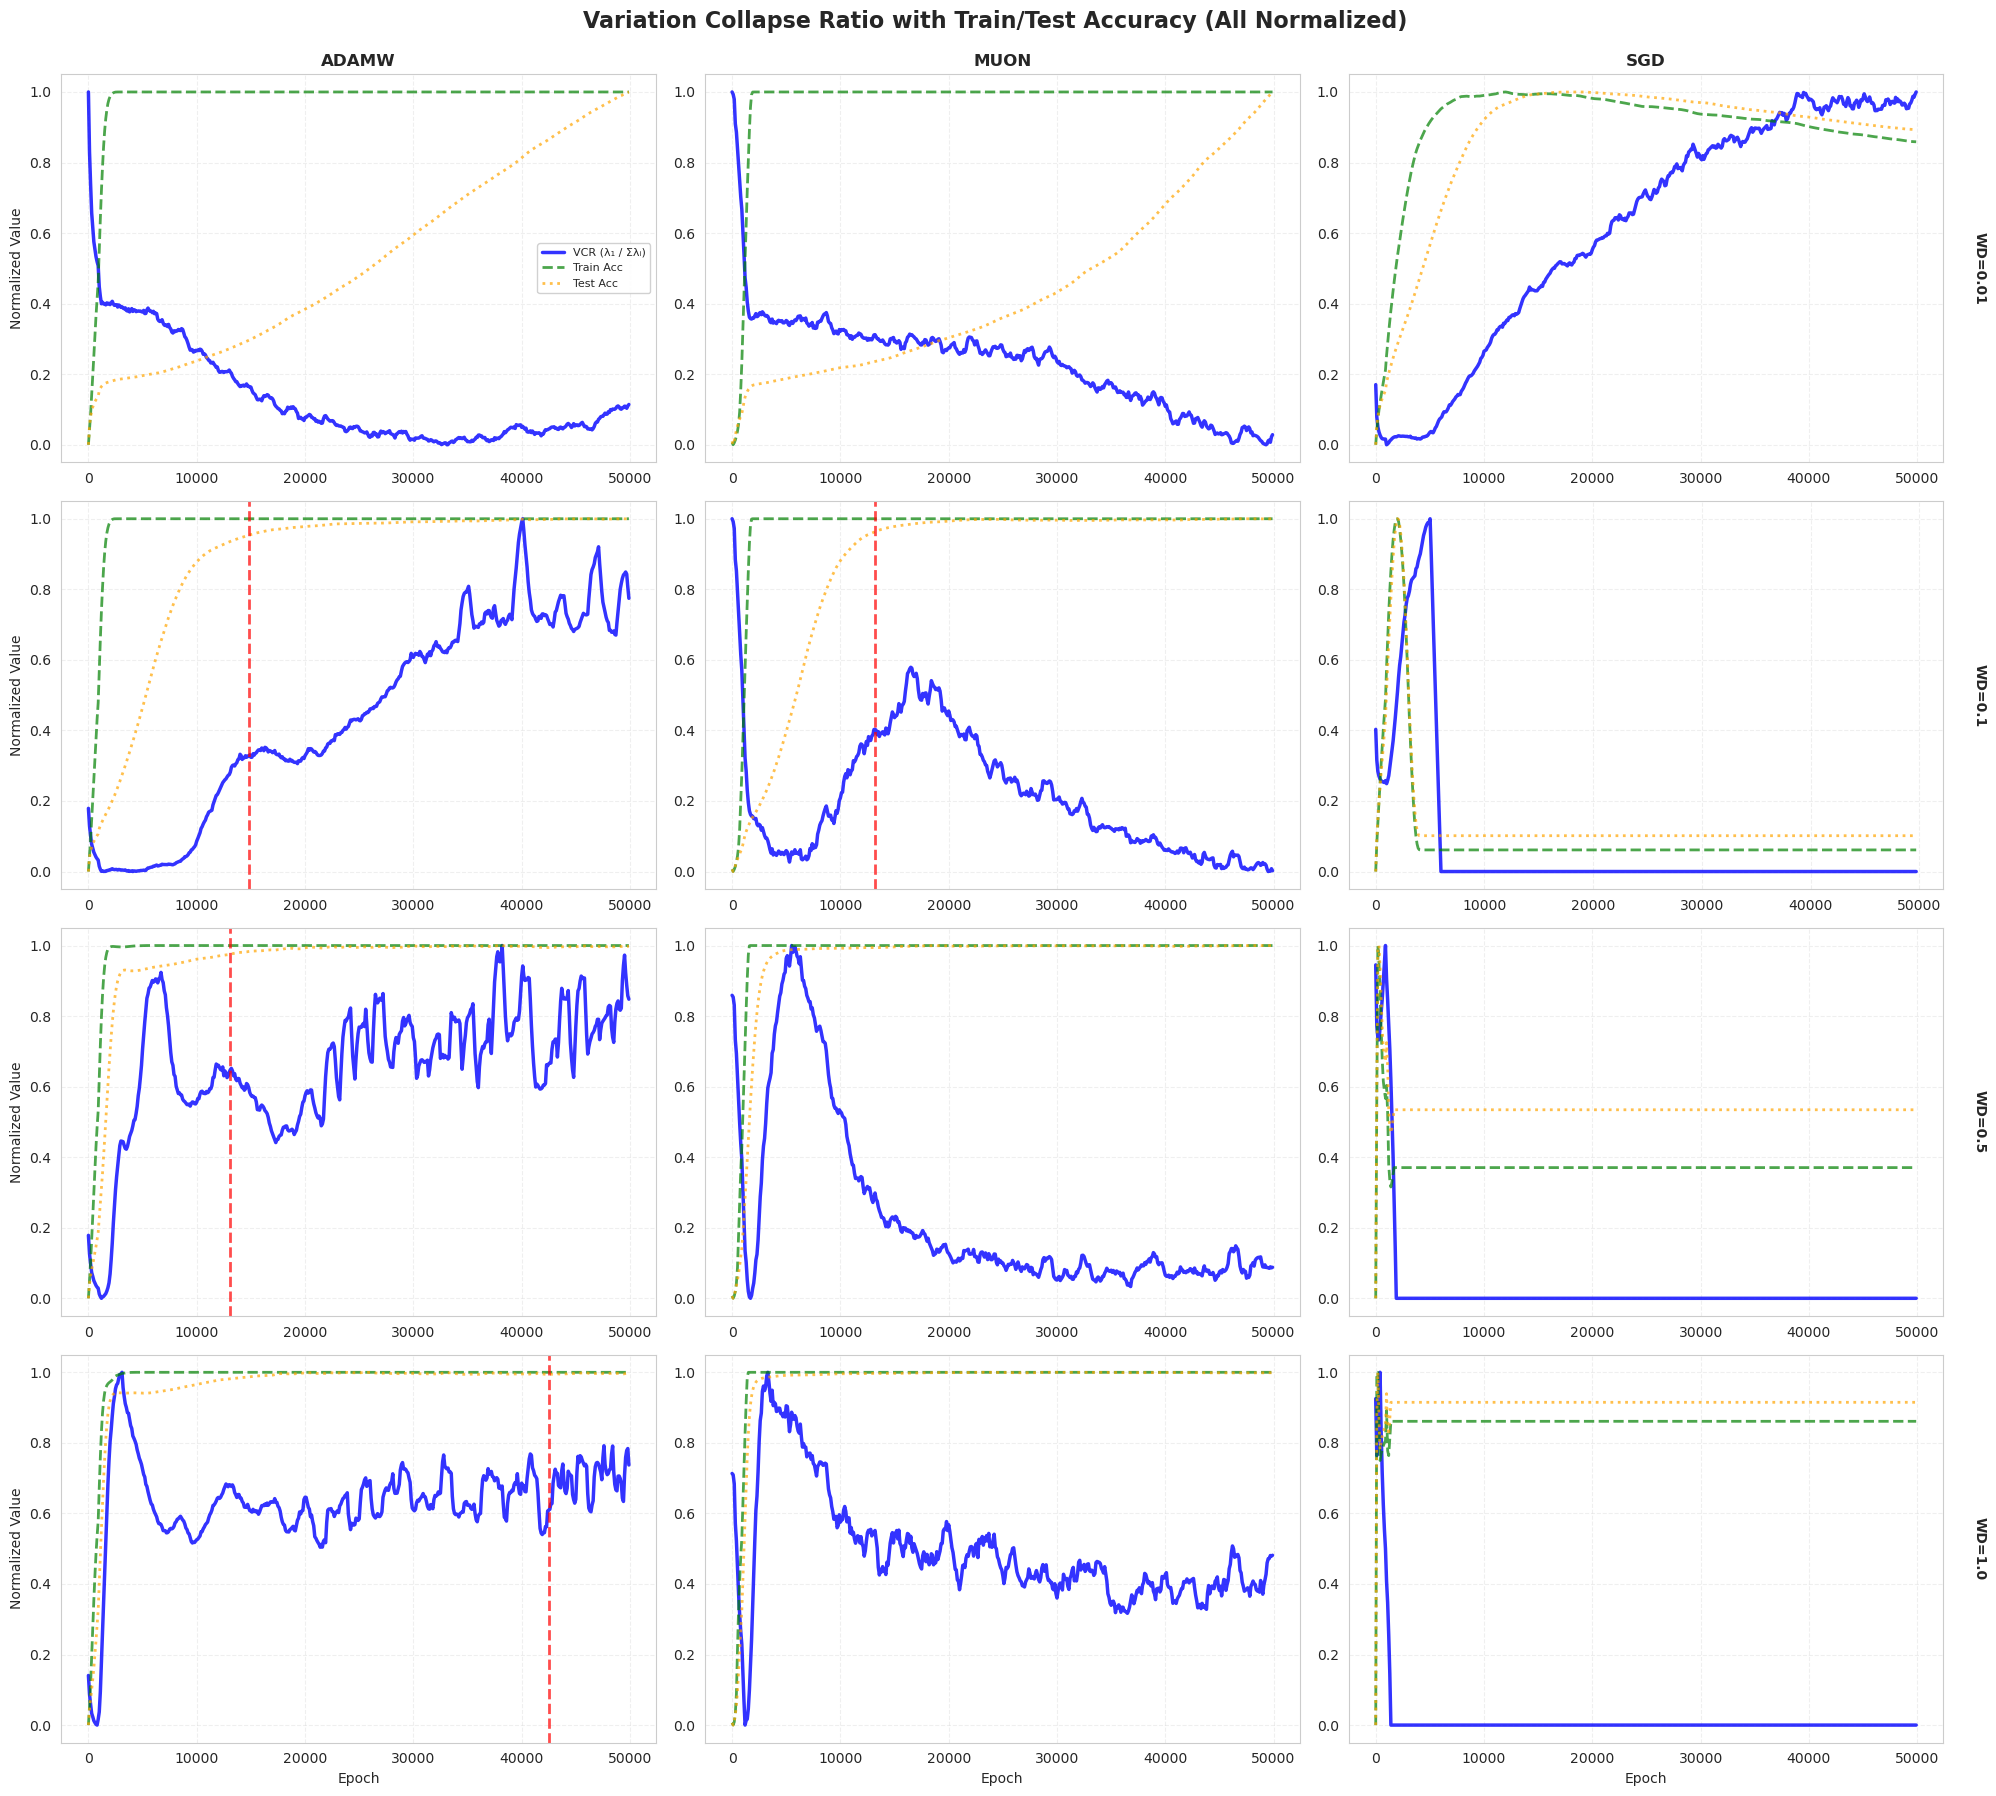

  Saved: mnist_agop_variation_collapse_ratio_normalized_4x3.png

Generating normalized Eigengap overlay...


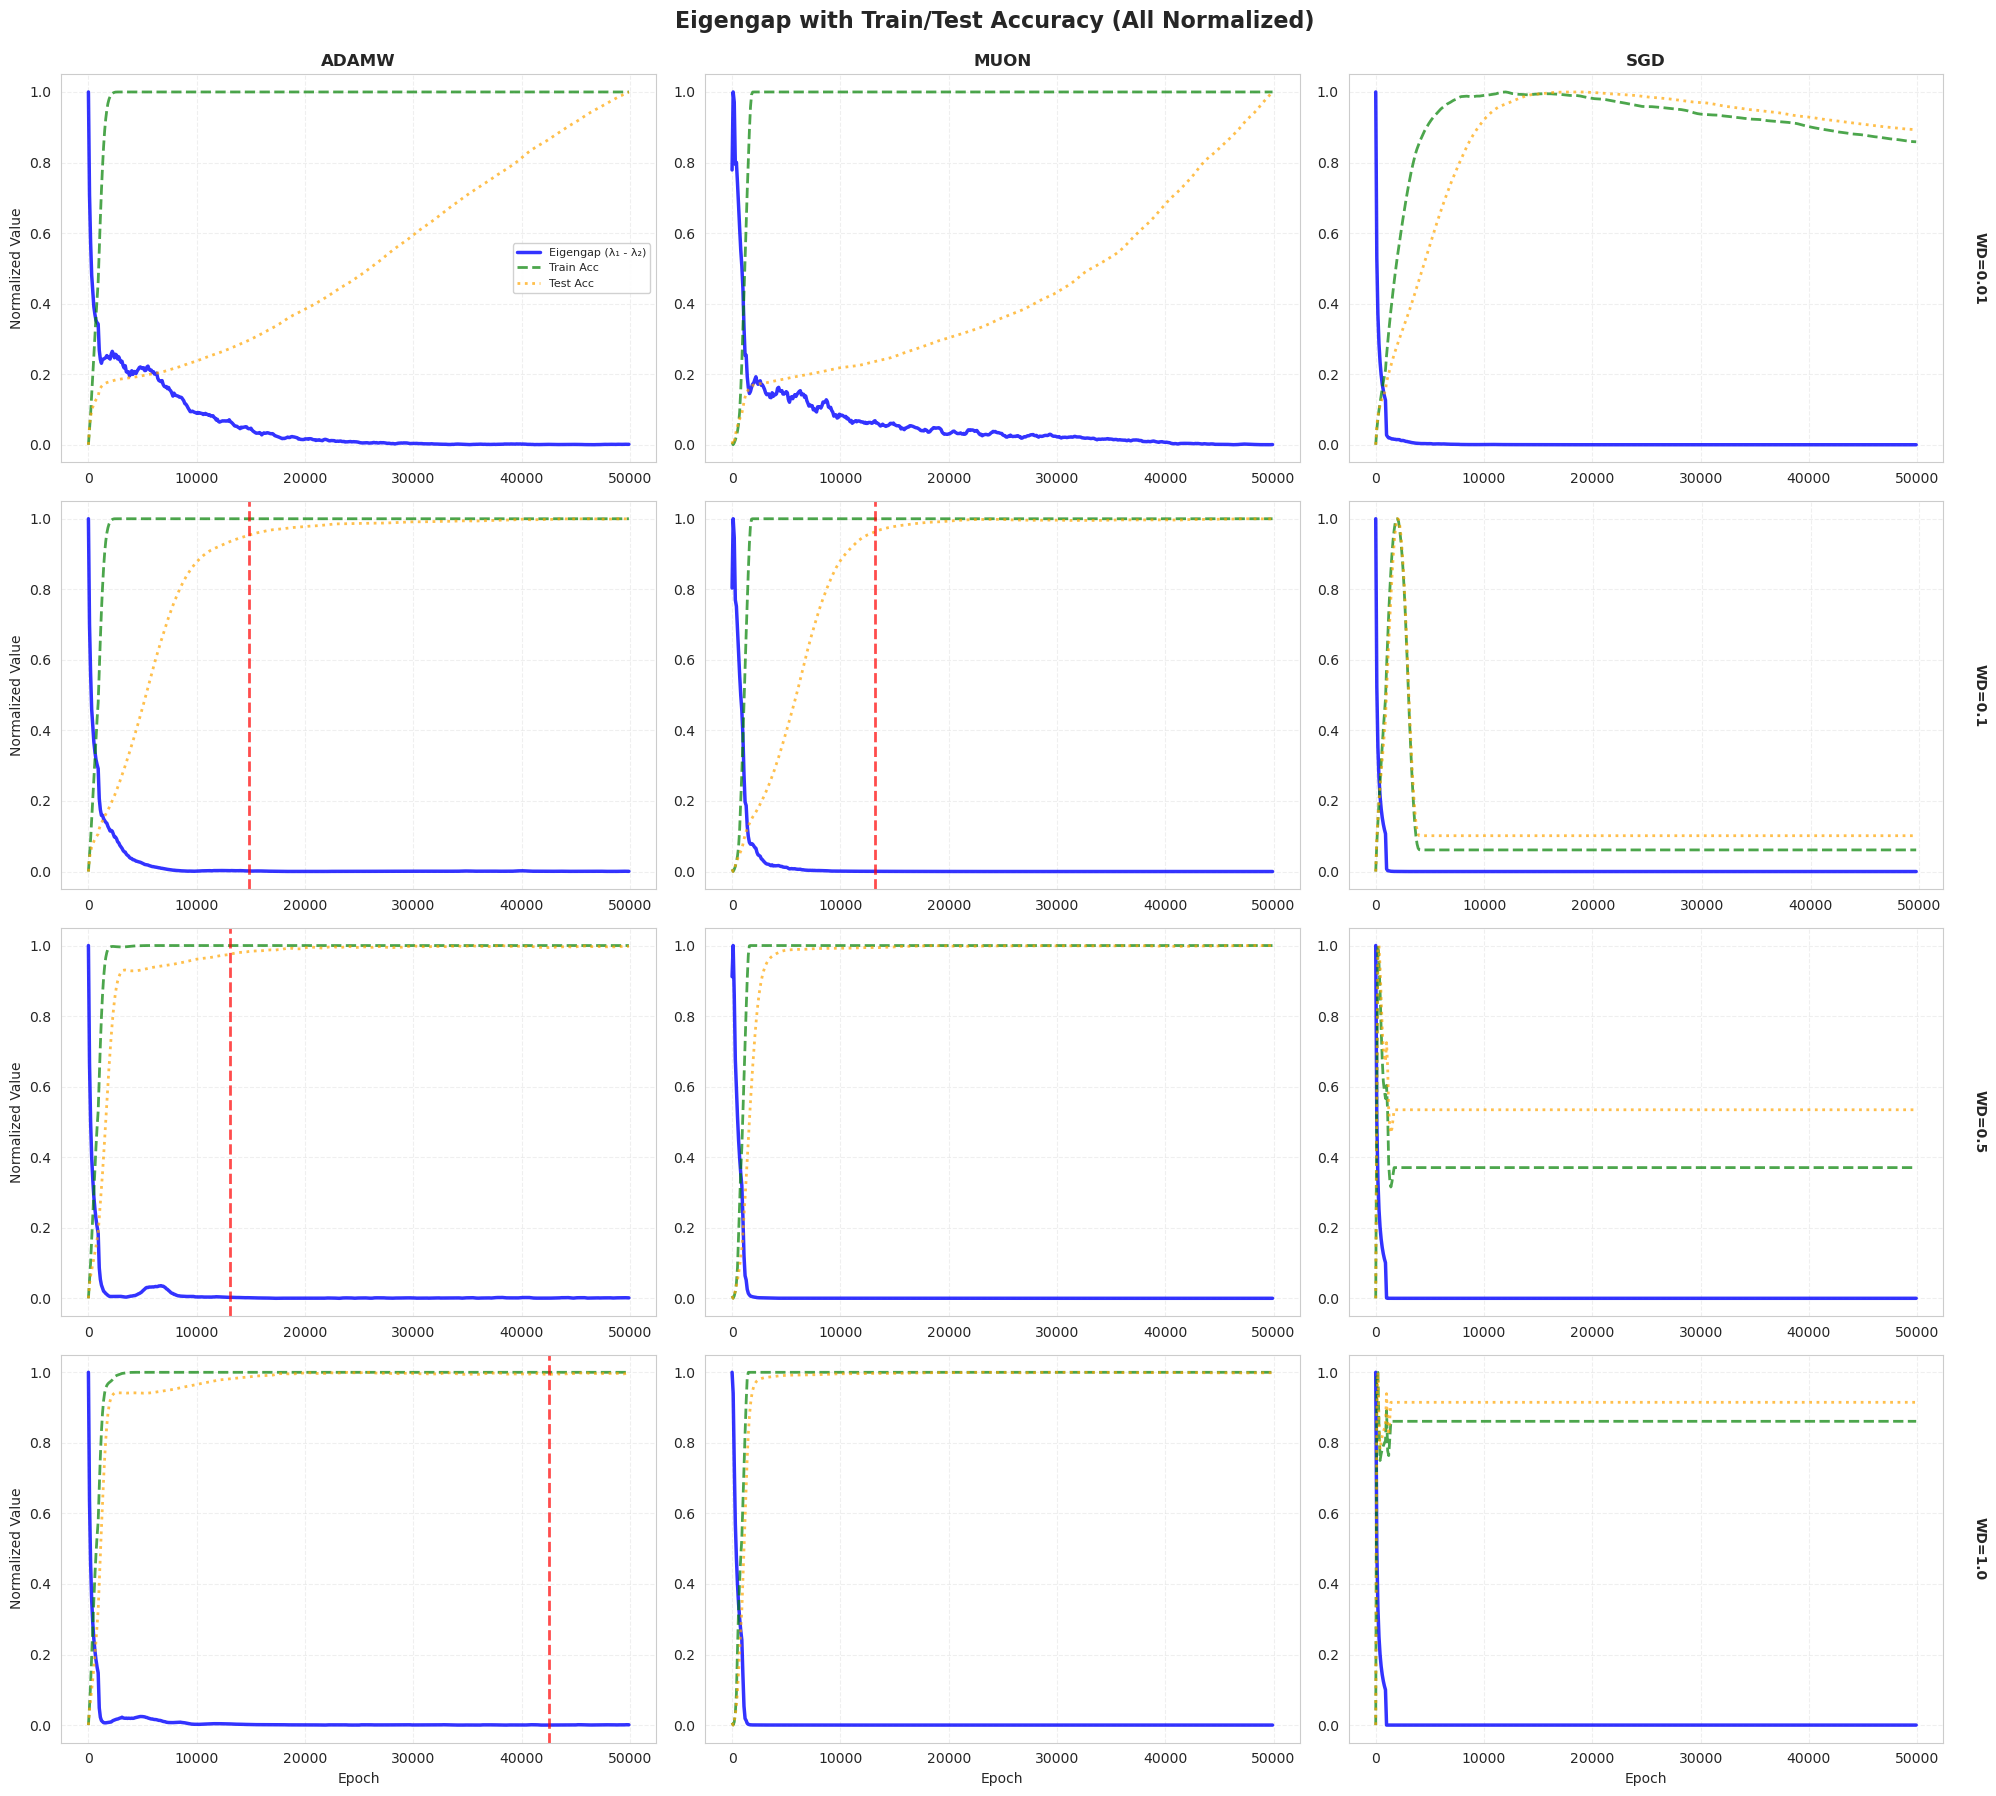

  Saved: mnist_agop_eigengap_normalized_4x3.png

Generating normalized Trace overlay...


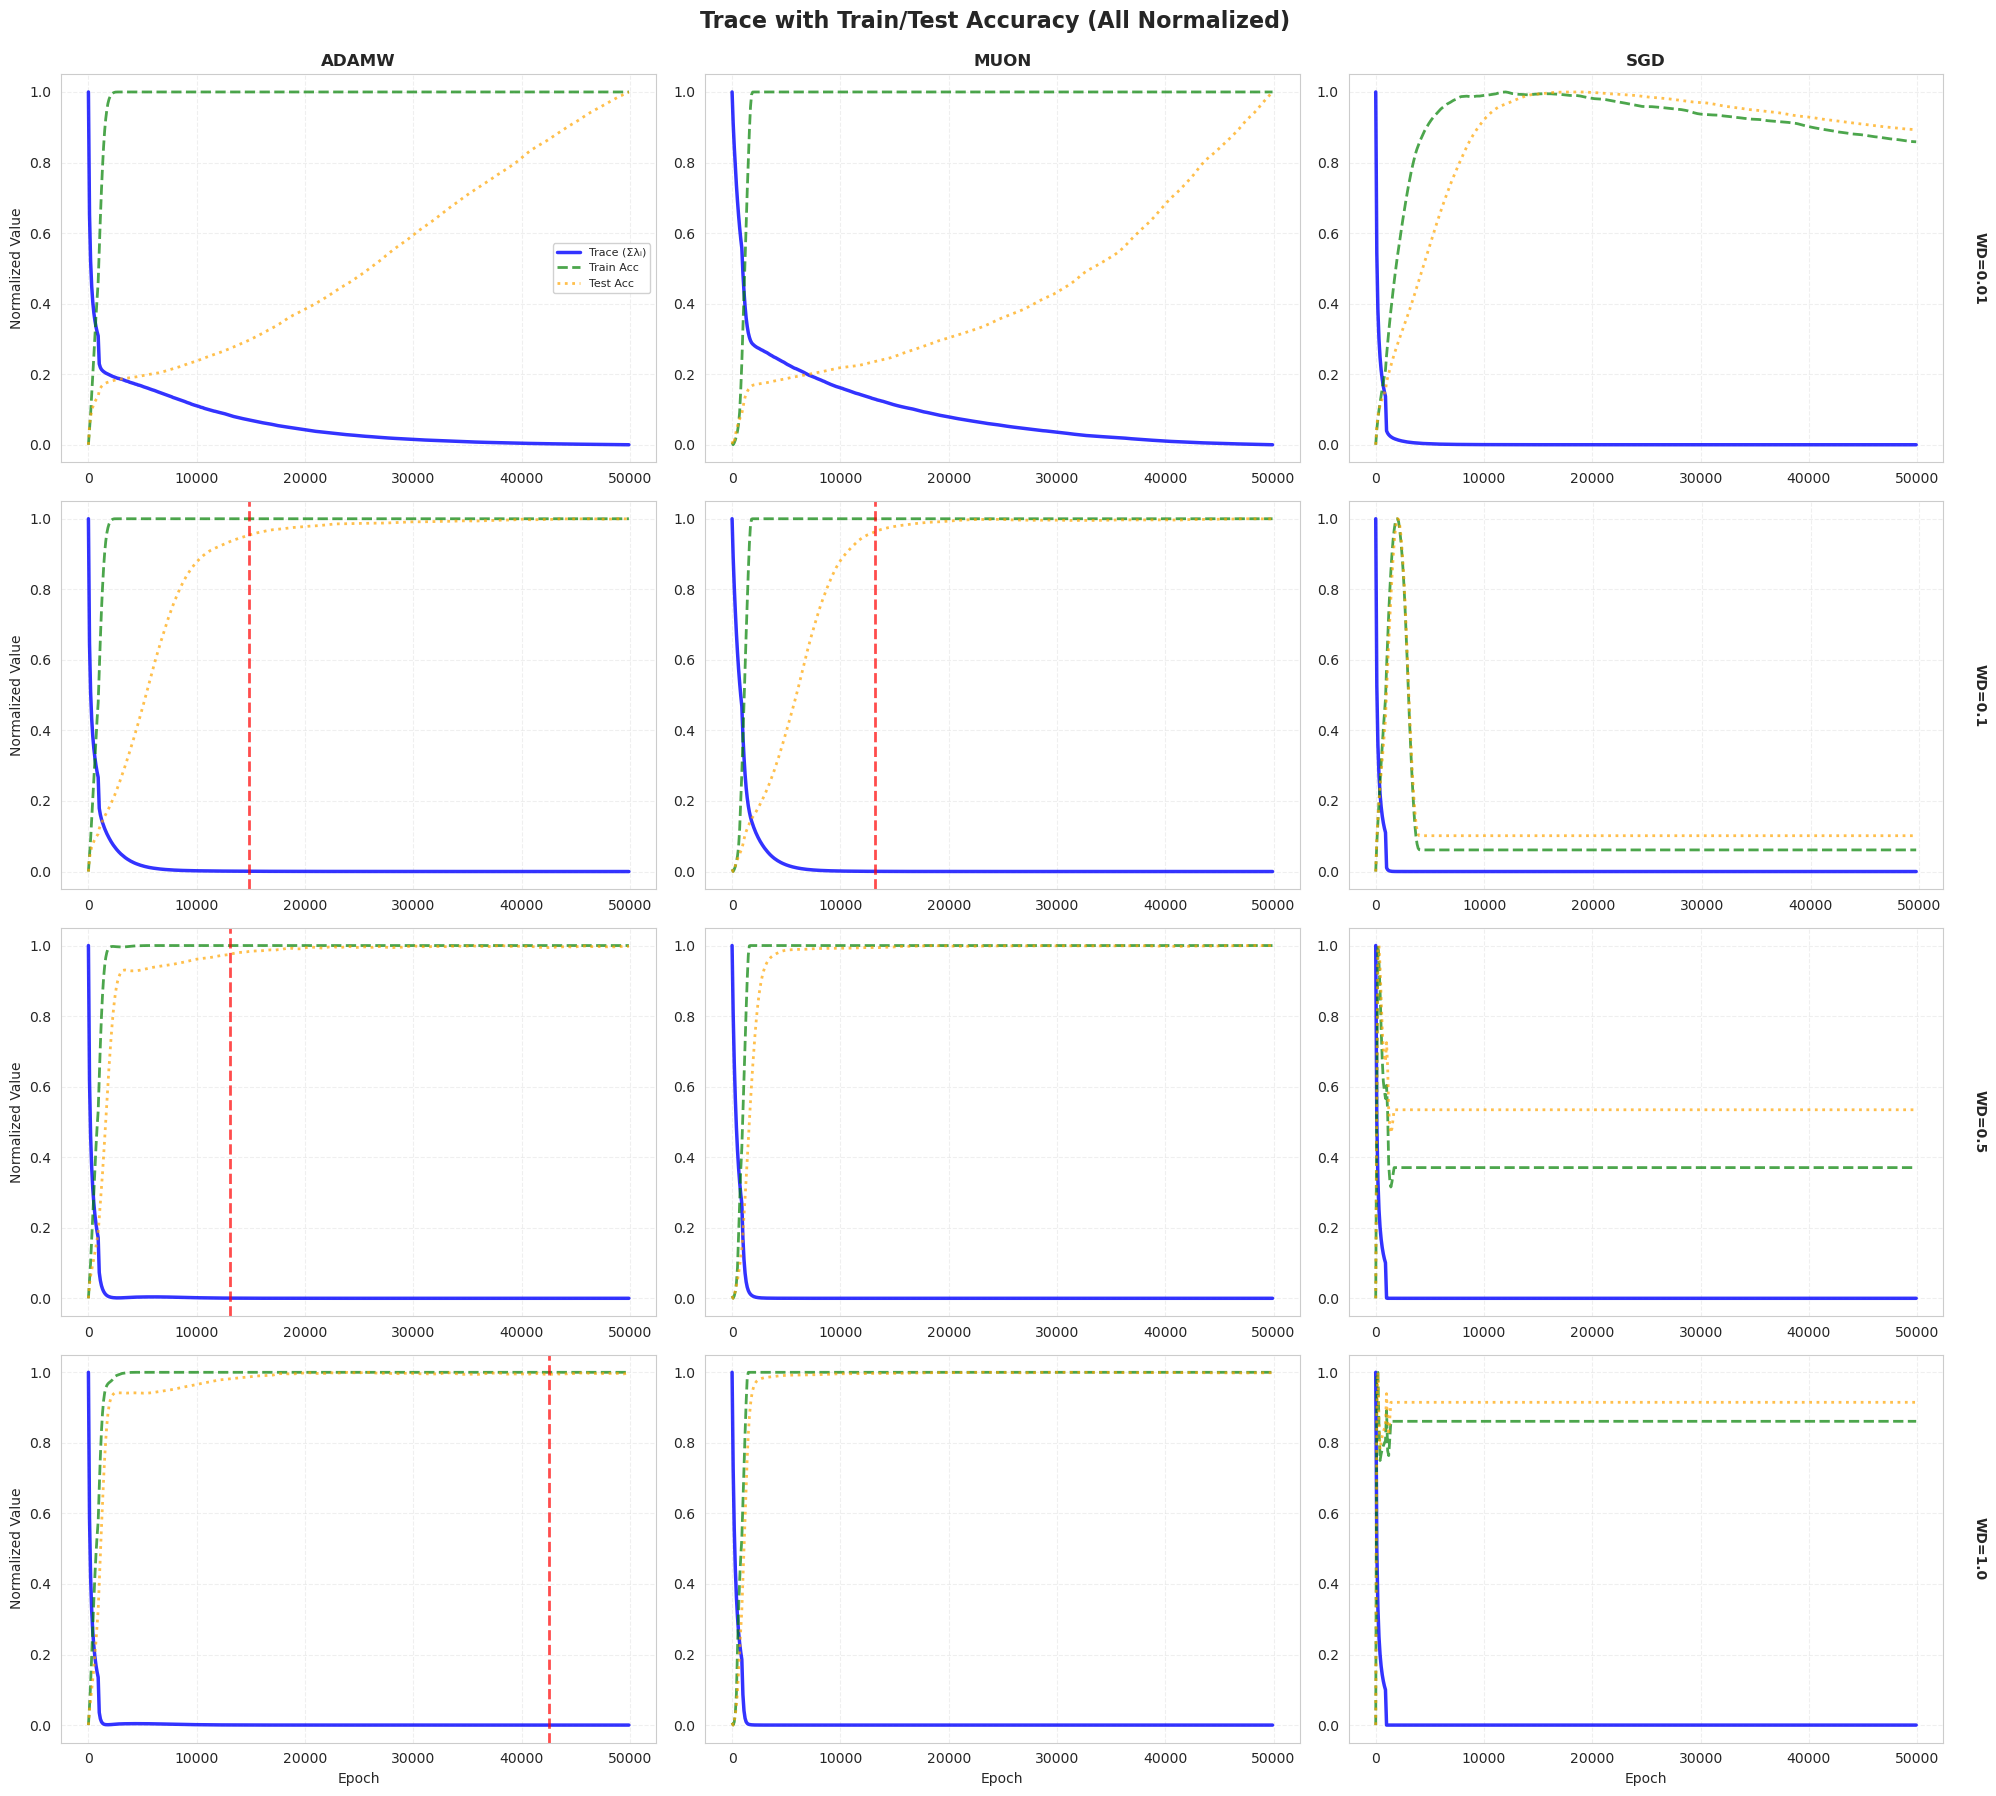

  Saved: mnist_agop_trace_normalized_4x3.png

Generating normalized Spectral Radius overlay...


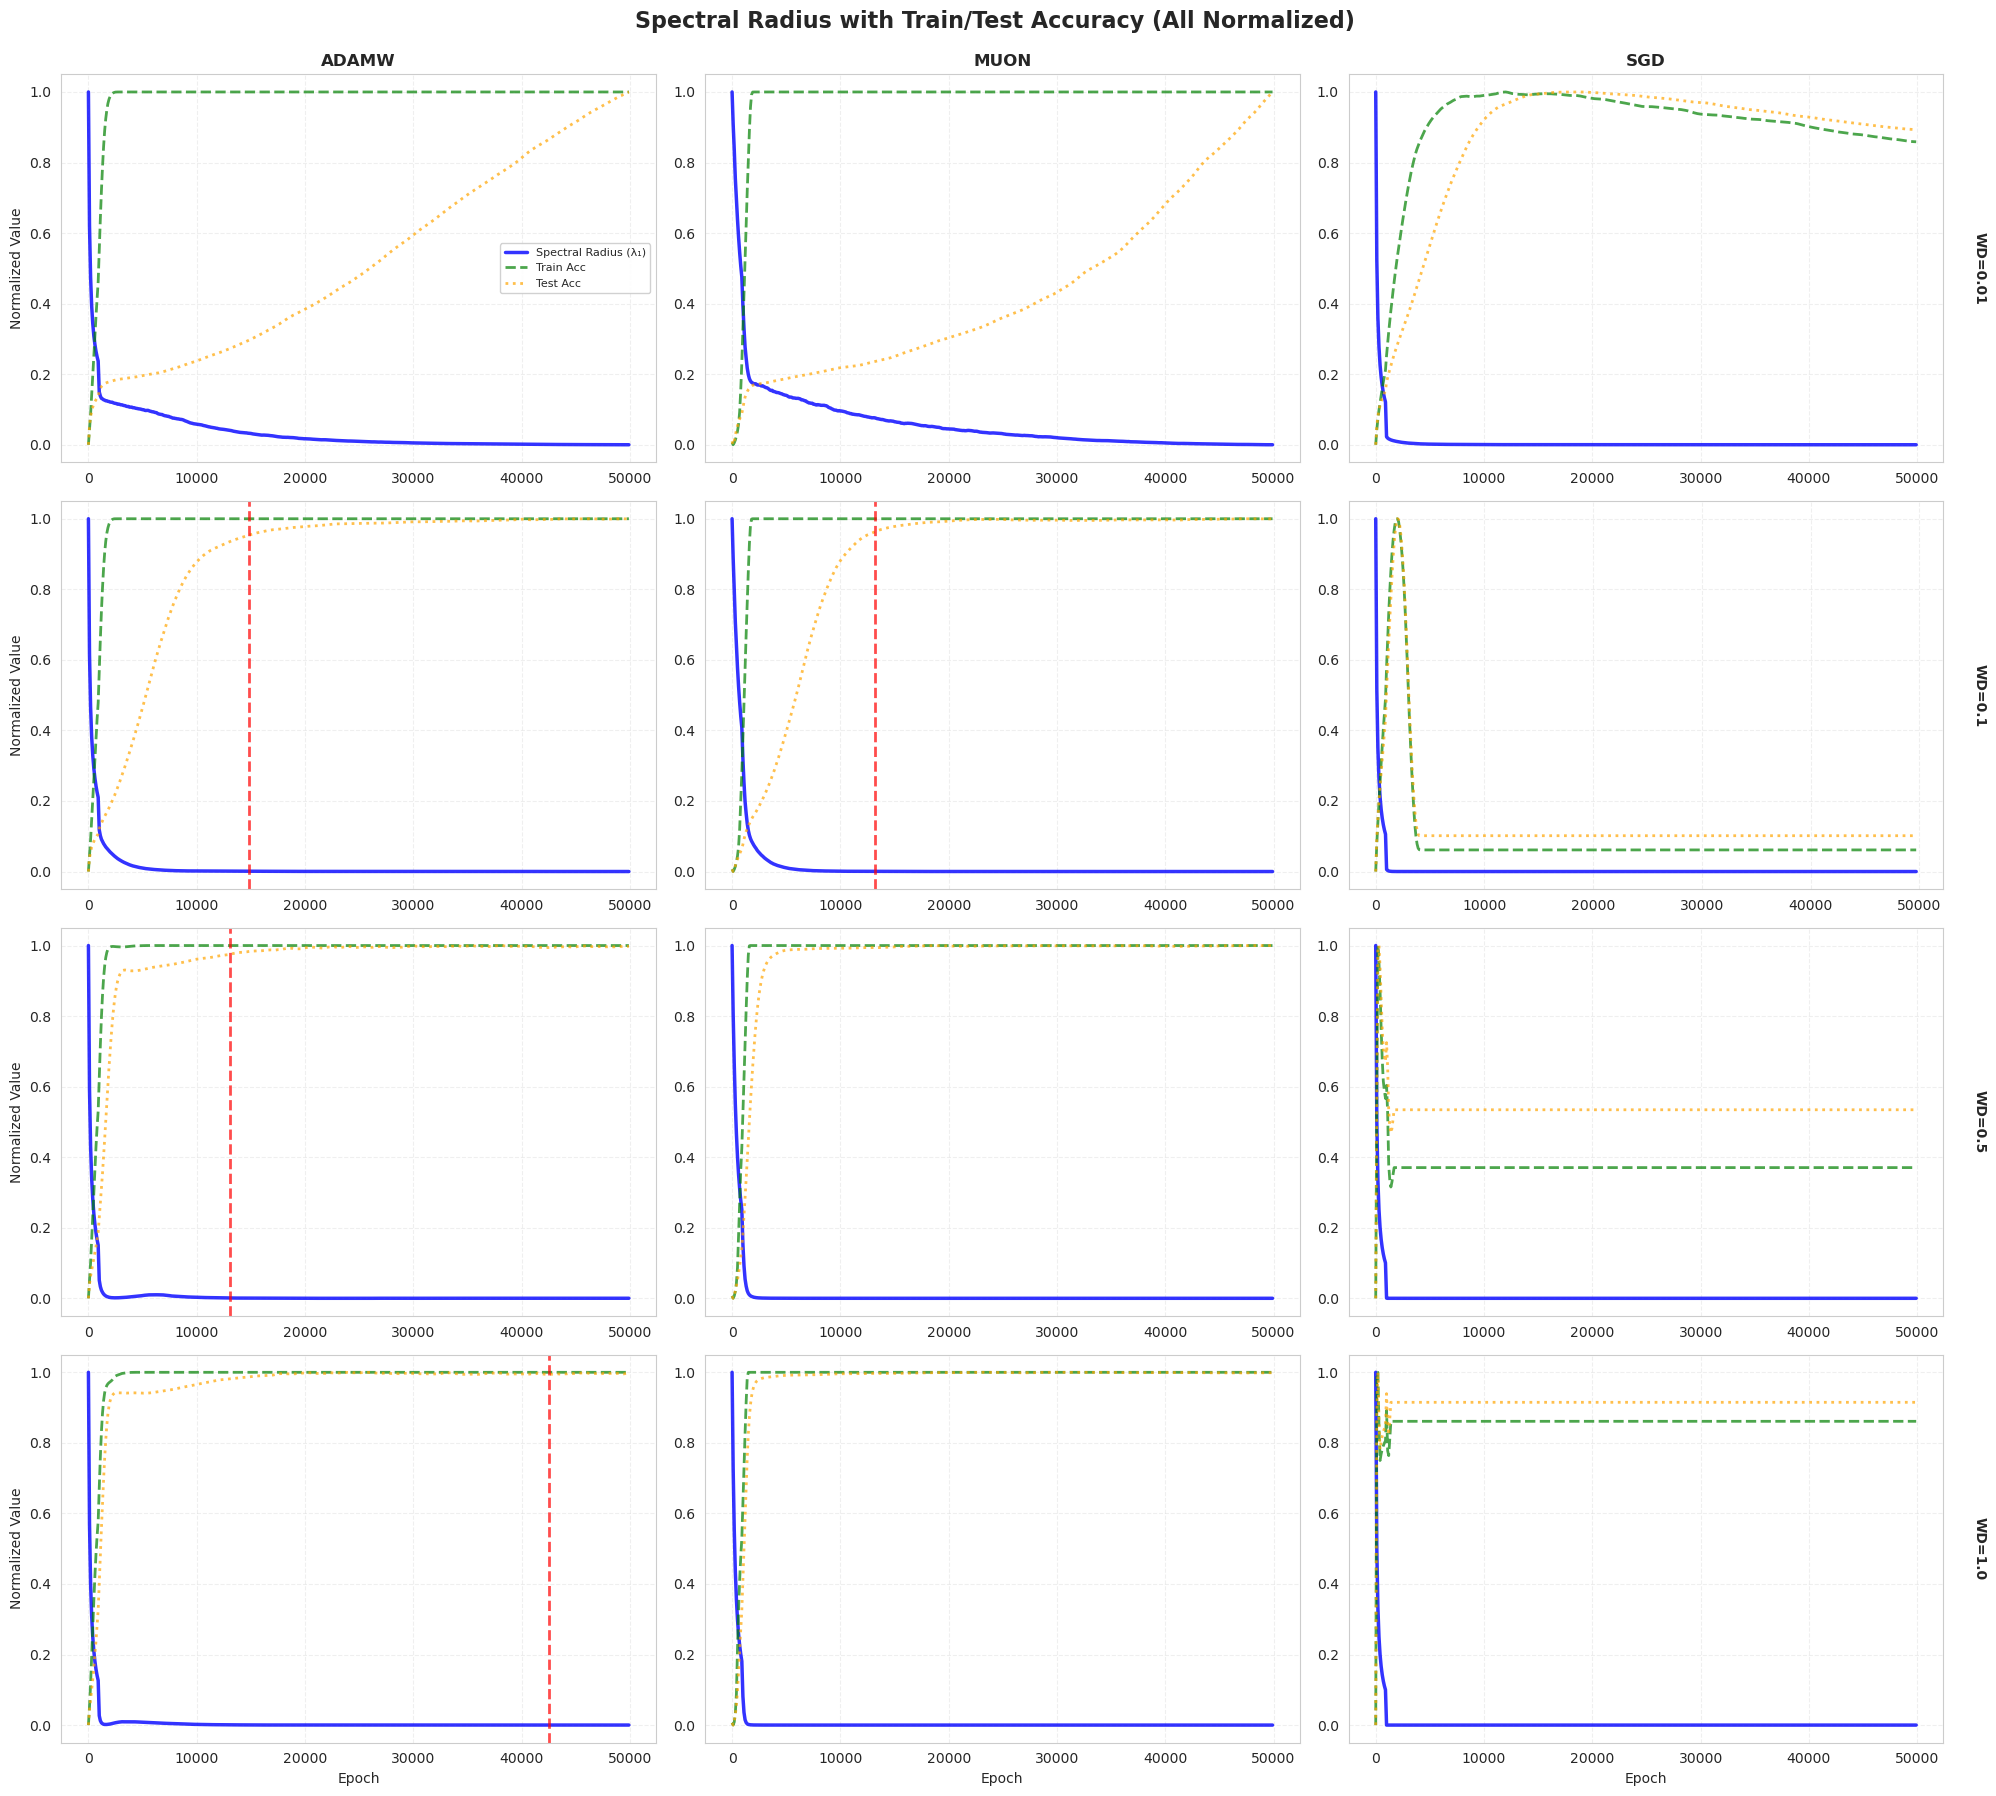

  Saved: mnist_agop_spectral_radius_normalized_4x3.png

Completed Section 2: Normalized AGOP overlays


In [25]:
# Helper function for normalization
def normalize_series(series):
    """Normalize a series to [0, 1] range using min-max normalization."""
    s_min = np.min(series)
    s_max = np.max(series)
    if s_max - s_min < 1e-10:  # Avoid division by zero
        return np.zeros_like(series)
    return (series - s_min) / (s_max - s_min)

# Create 4x3 panel for each AGOP metric (normalized overlays)
for metric_name, metric_label, metric_title in agop_metrics:
    print(f"\nGenerating normalized {metric_title} overlay...")
    
    fig, axes = plt.subplots(4, 3, figsize=(20, 18))
    
    for row_idx, wd in enumerate([0.01, 0.1, 0.5, 1.0]):
        for col_idx, opt in enumerate(['adamw', 'muon', 'sgd']):
            ax = axes[row_idx, col_idx]
            
            # Find the experiment for this optimizer-weight_decay combination
            if opt not in mnist_by_opt:
                ax.axis('off')
                continue
            
            exp_found = False
            for exp_name, exp_data in mnist_by_opt[opt]:
                config = exp_data.get('config', {})
                if config.get('weight_decay', 0) == wd:
                    history = exp_data.get('history', {})
                    
                    # Check if all required data exists
                    if metric_name not in history or 'train_acc' not in history or 'test_acc' not in history:
                        break
                    
                    epochs = np.array(history.get('epoch', range(len(history.get('test_acc', [])))))
                    metric_values = np.array(history[metric_name])
                    train_acc = np.array(history['train_acc'])
                    test_acc = np.array(history['test_acc'])
                    
                    # Align lengths
                    min_len = min(len(epochs), len(metric_values), len(train_acc), len(test_acc))
                    epochs = epochs[:min_len]
                    metric_values = metric_values[:min_len]
                    train_acc = train_acc[:min_len]
                    test_acc = test_acc[:min_len]
                    
                    # Detect grokking
                    grok_epoch_idx = detect_grokking_epoch(train_acc, test_acc)
                    grok_epoch = epochs[grok_epoch_idx] if grok_epoch_idx is not None else None
                    
                    # Smooth and normalize
                    metric_smooth = smooth_series(metric_values, window=10)
                    train_smooth = smooth_series(train_acc, window=10)
                    test_smooth = smooth_series(test_acc, window=10)
                    
                    metric_norm = normalize_series(metric_smooth)
                    train_norm = normalize_series(train_smooth)
                    test_norm = normalize_series(test_smooth)
                    
                    # Plot all three normalized curves
                    ax.plot(epochs[:len(metric_norm)], metric_norm, linewidth=2.5, color='blue', 
                           alpha=0.8, label=metric_label, linestyle='-')
                    ax.plot(epochs[:len(train_norm)], train_norm, linewidth=2.0, color='green', 
                           alpha=0.7, label='Train Acc', linestyle='--')
                    ax.plot(epochs[:len(test_norm)], test_norm, linewidth=2.0, color='orange', 
                           alpha=0.7, label='Test Acc', linestyle=':')
                    
                    # Mark grokking epoch
                    if grok_epoch is not None:
                        ax.axvline(x=grok_epoch, color='red', linestyle='--', linewidth=2, alpha=0.7)
                    
                    exp_found = True
                    break
            
            if not exp_found:
                ax.axis('off')
                continue
            
            # Formatting
            ax.set_ylabel('Normalized Value' if col_idx == 0 else '', fontsize=10)
            ax.set_xlabel('Epoch' if row_idx == 3 else '', fontsize=10)
            ax.set_ylim([-0.05, 1.05])
            ax.grid(alpha=0.3, linestyle='--')
            
            # Add title for top row (optimizer names)
            if row_idx == 0:
                ax.set_title(opt.upper(), fontsize=12, fontweight='bold')
            
            # Add weight decay label on right side
            if col_idx == 2:
                ax.text(1.05, 0.5, f'WD={wd}', transform=ax.transAxes,
                       fontsize=10, fontweight='bold', rotation=270,
                       verticalalignment='center')
            
            # Add legend only on top-left subplot
            if row_idx == 0 and col_idx == 0:
                ax.legend(fontsize=8, loc='best', framealpha=0.9)
    
    fig.suptitle(f'{metric_title} with Train/Test Accuracy (All Normalized)', 
                fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'mnist_{metric_name}_normalized_4x3.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"  Saved: mnist_{metric_name}_normalized_4x3.png")

print("\nCompleted Section 2: Normalized AGOP overlays")


## AGOP Metrics with Train/Test Accuracy Overlays (Normalized)

For each optimizer and each AGOP metric, we create vertically stacked plots showing:
- **Blue solid line**: AGOP metric (normalized)
- **Green dashed line**: Train accuracy (normalized)
- **Orange dotted line**: Test accuracy (normalized)
- **Red vertical line**: Grokking epoch (if applicable)

This allows us to see temporal relationships between AGOP metrics and learning dynamics.



Processing ADAMW MNIST experiments...


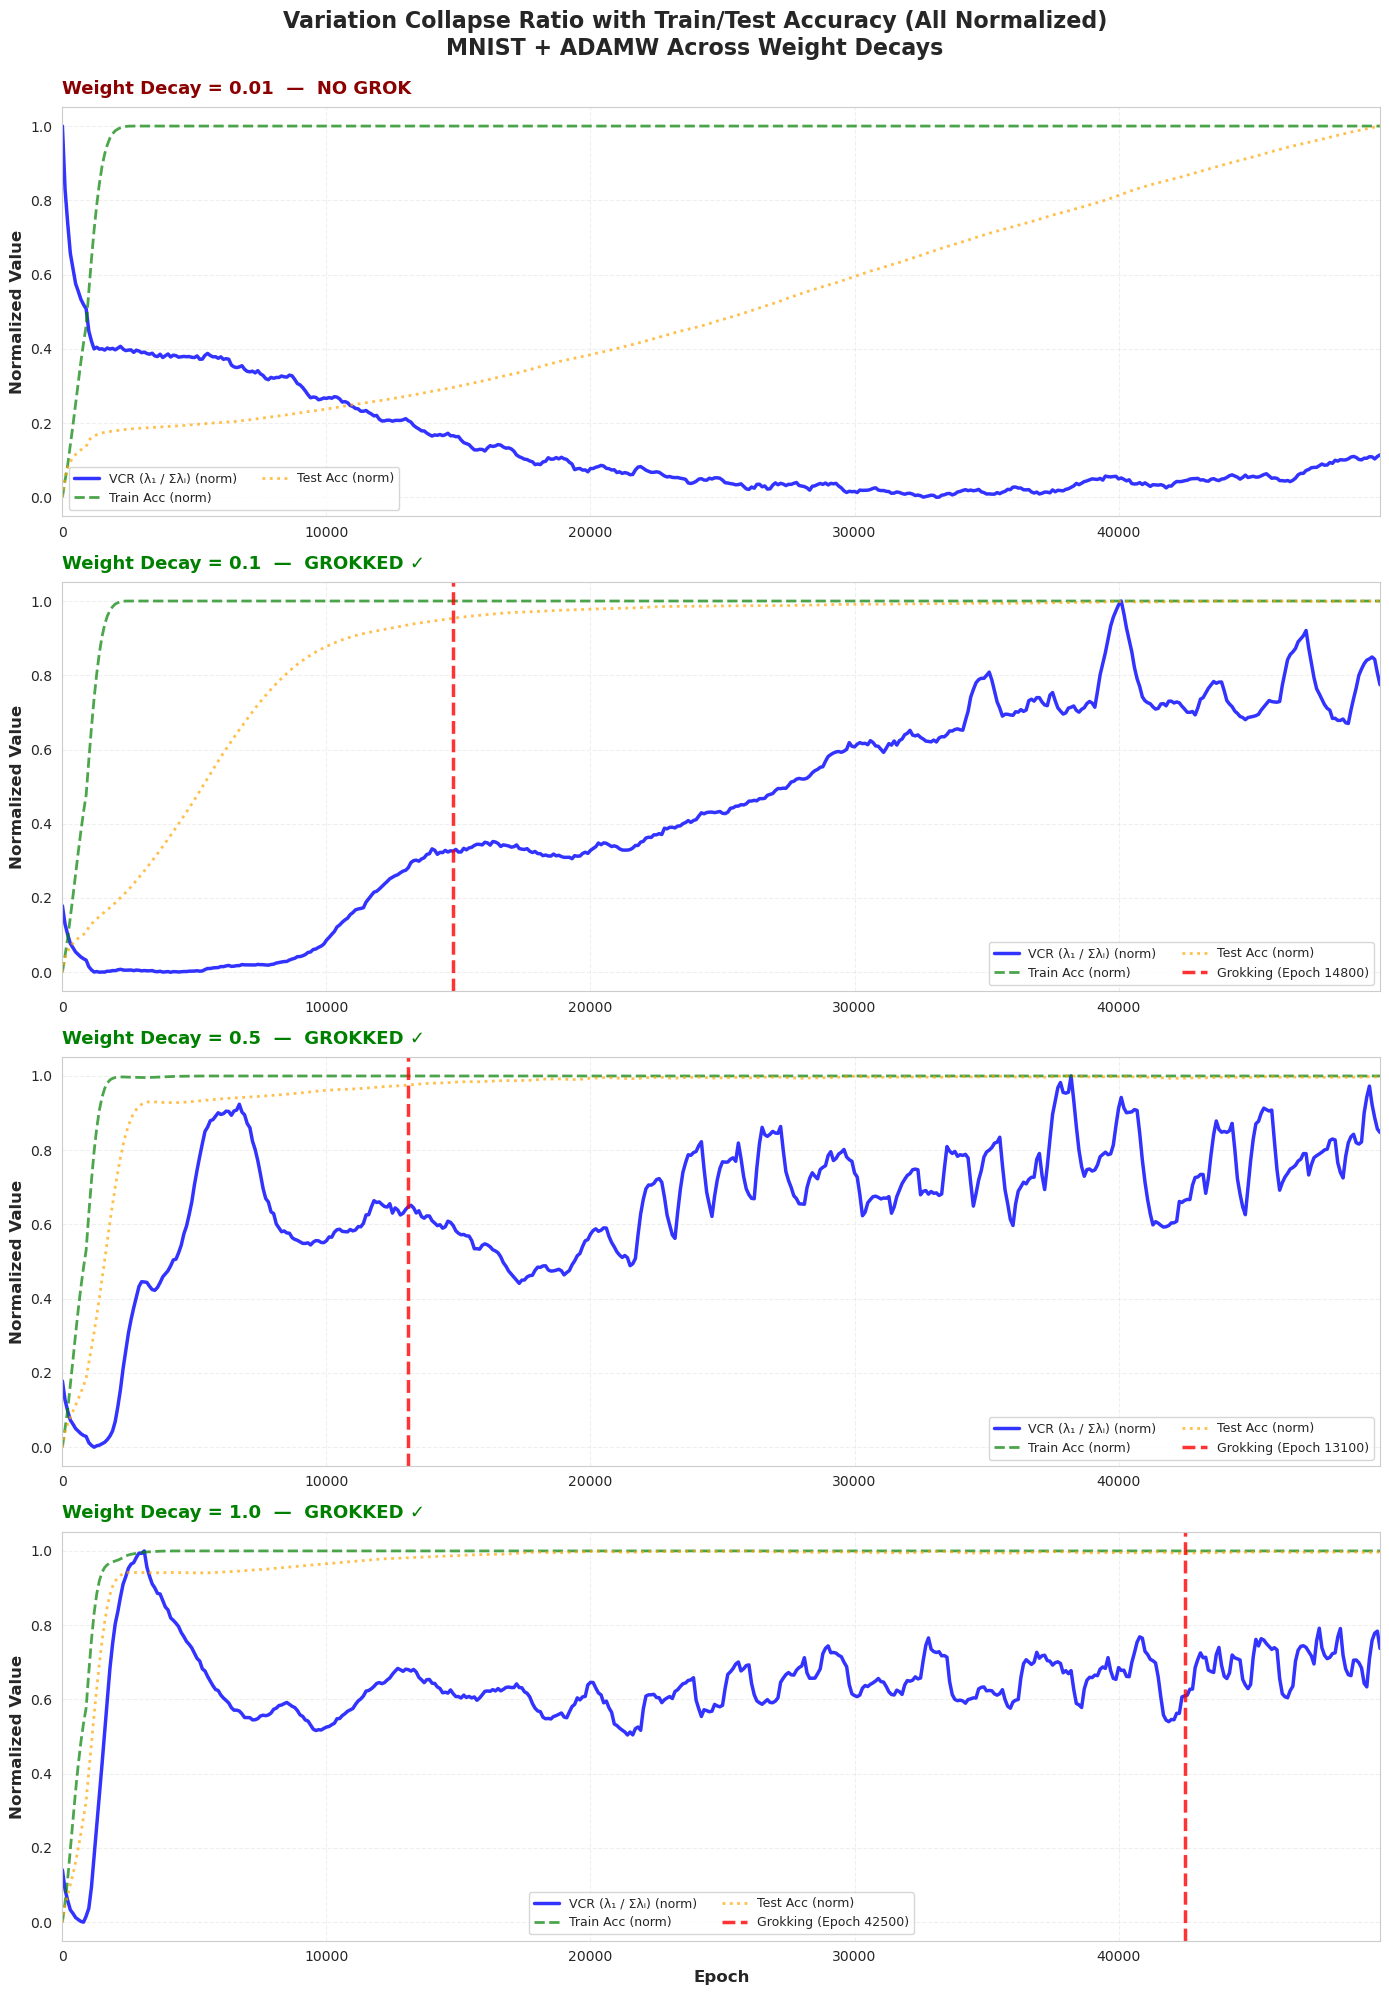

  Generated overlay panel for Variation Collapse Ratio


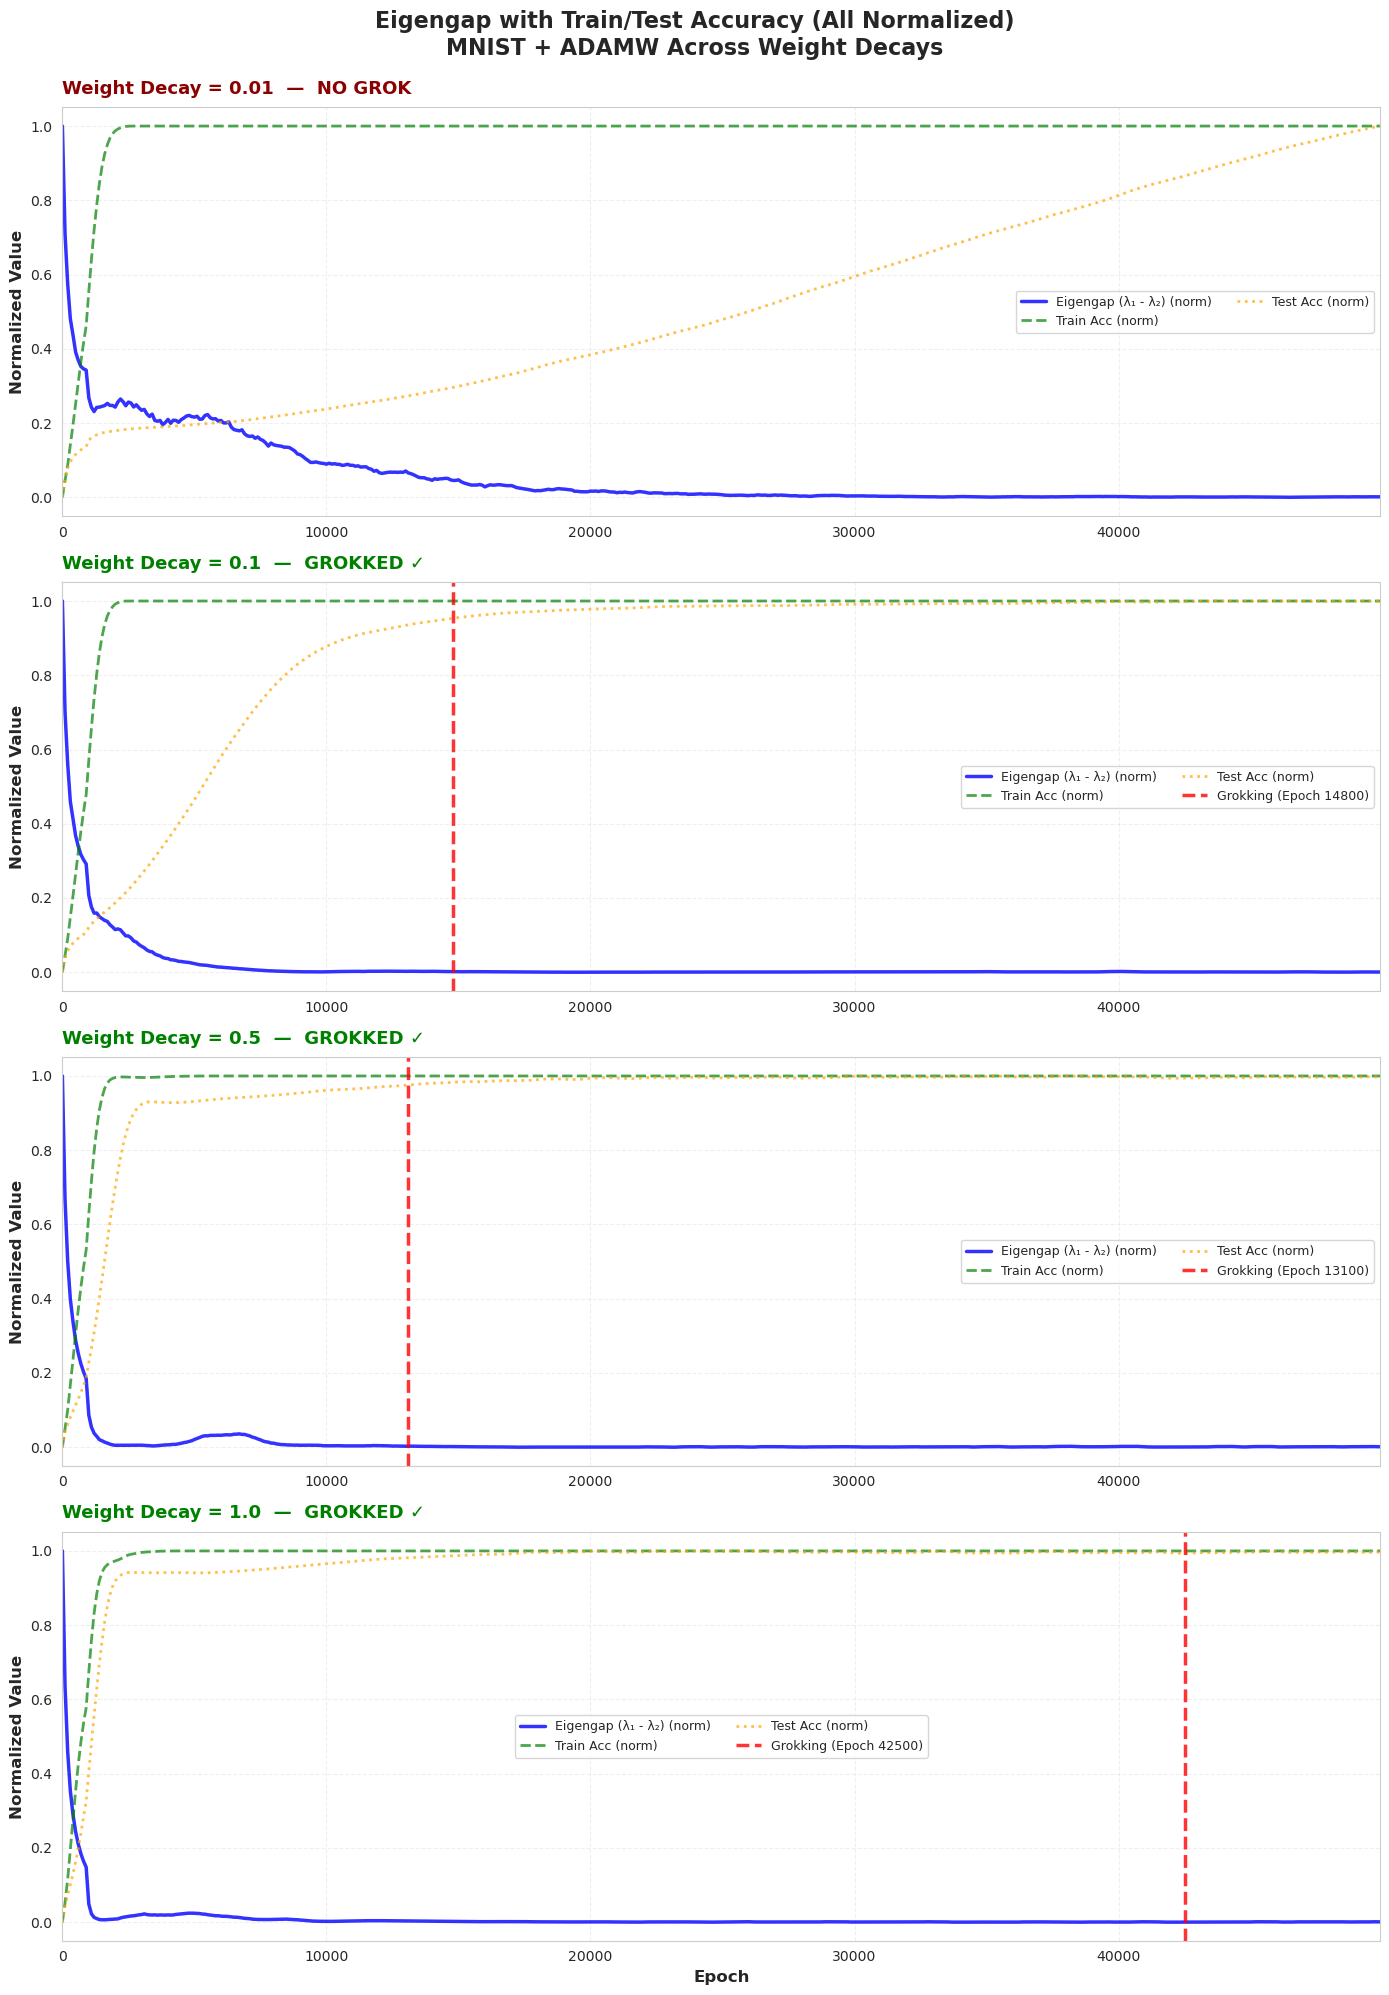

  Generated overlay panel for Eigengap


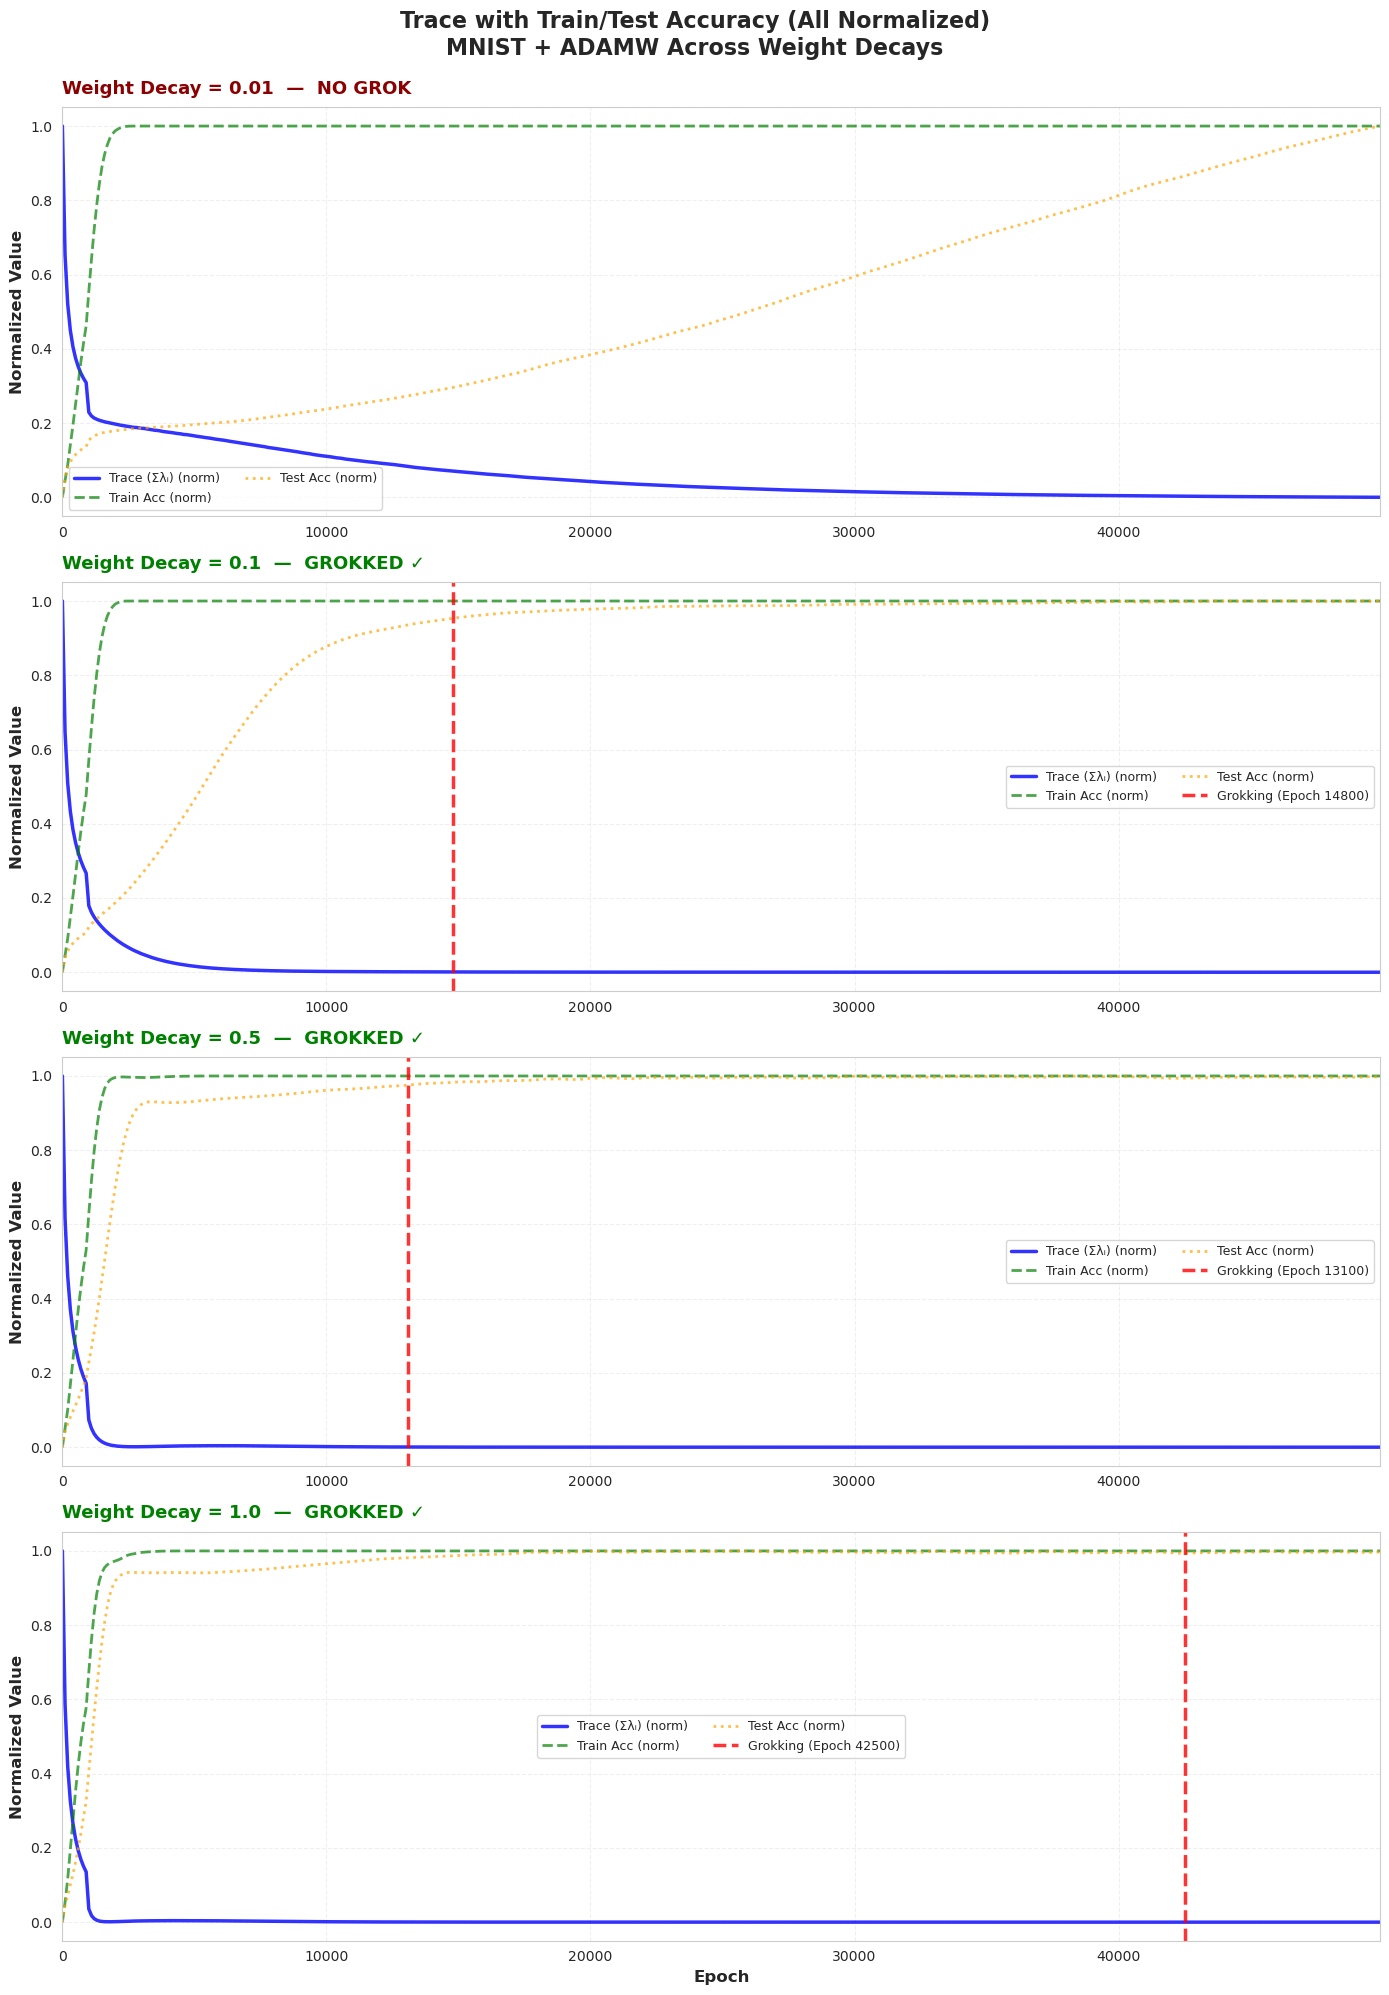

  Generated overlay panel for Trace


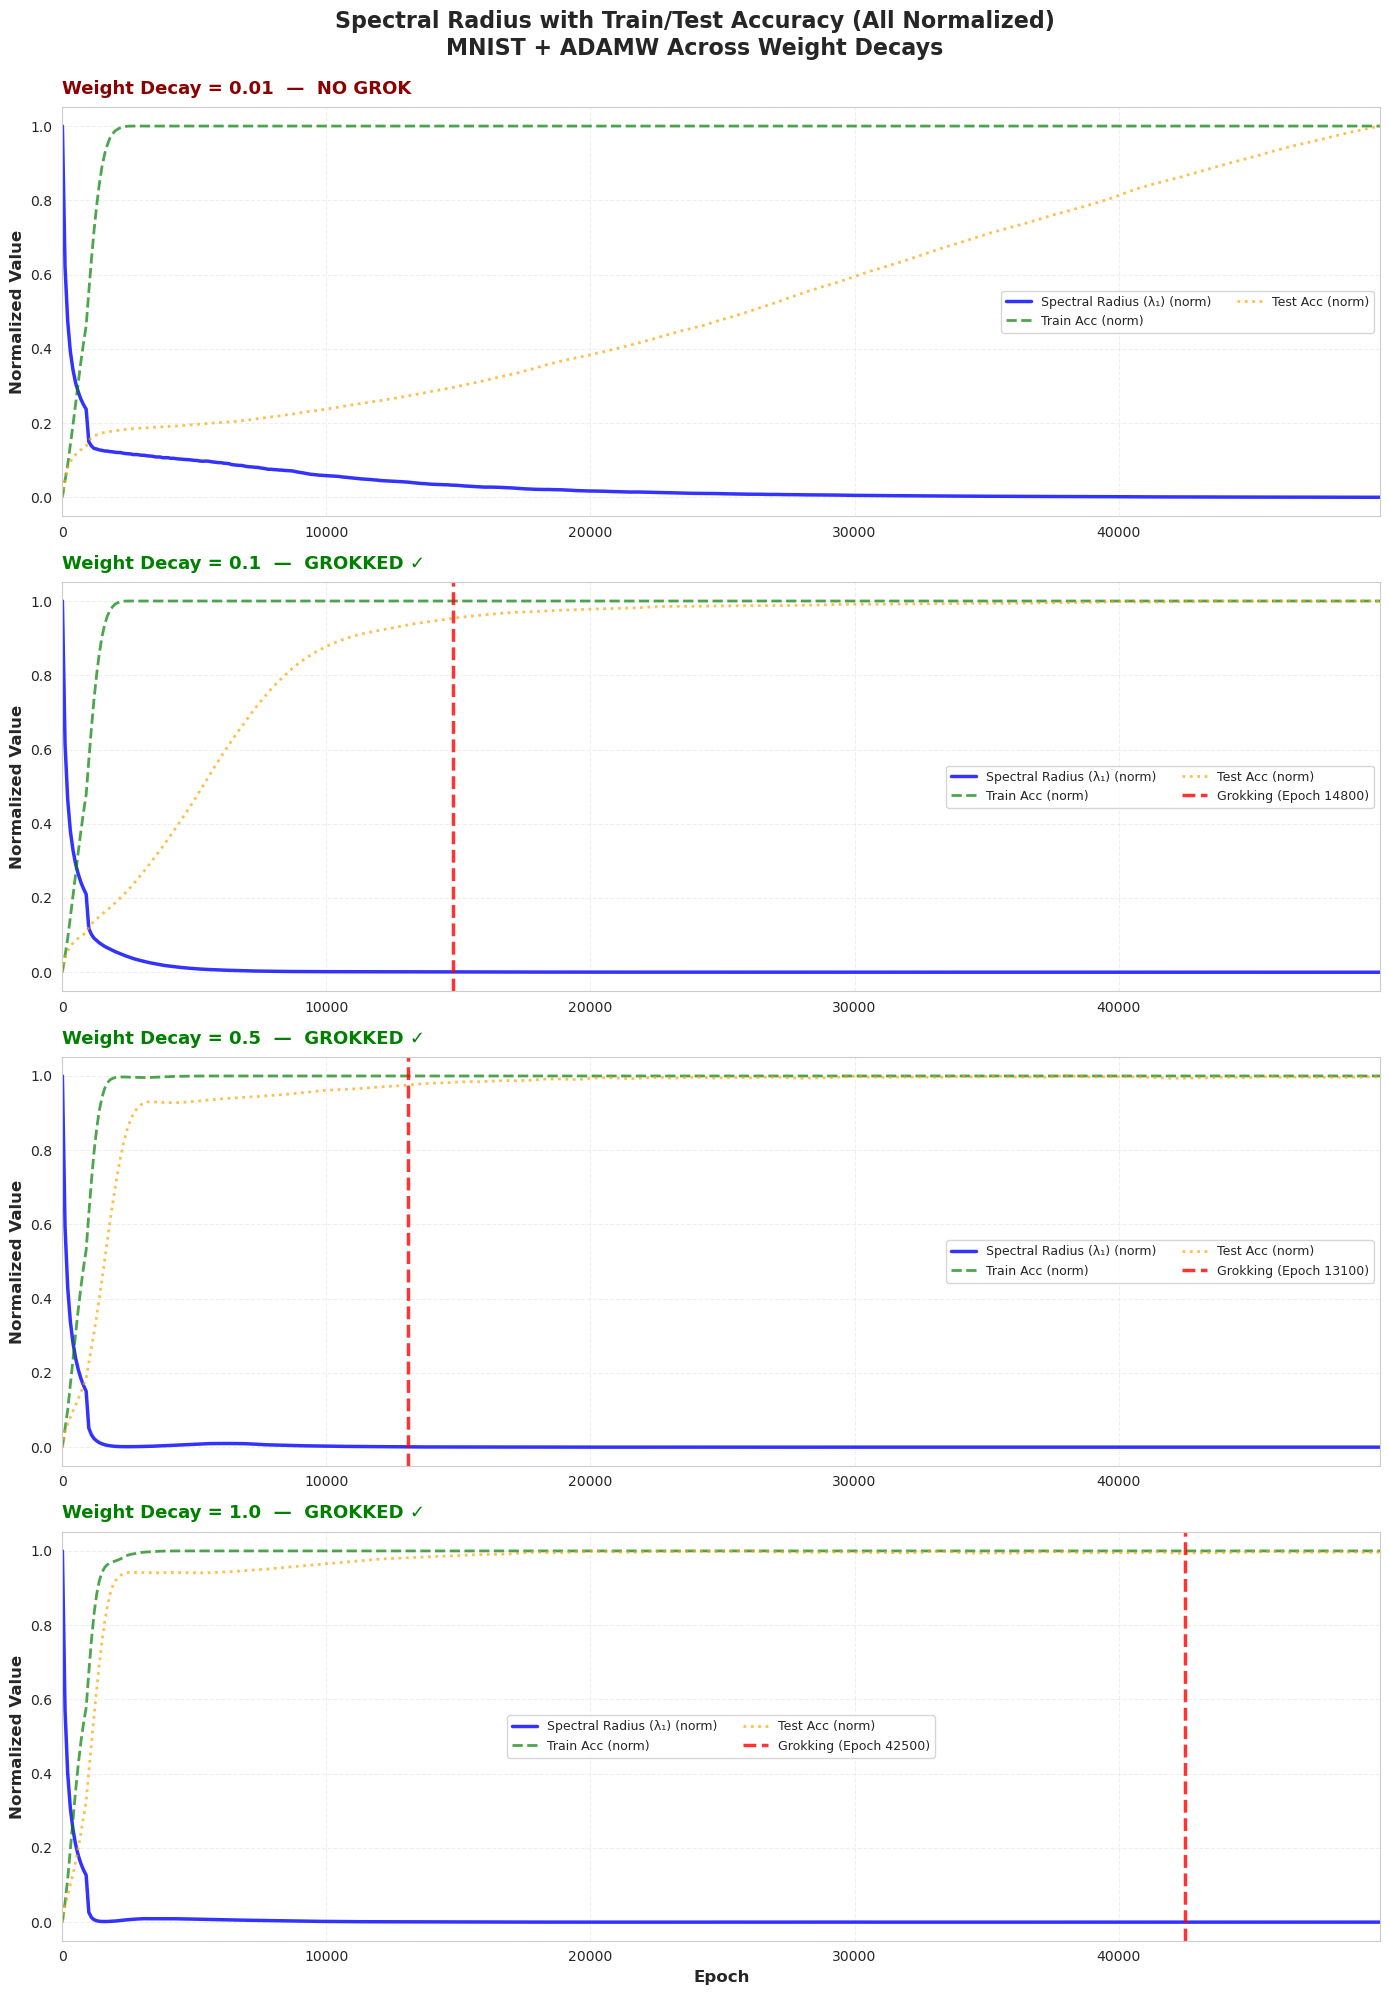

  Generated overlay panel for Spectral Radius

Processing MUON MNIST experiments...


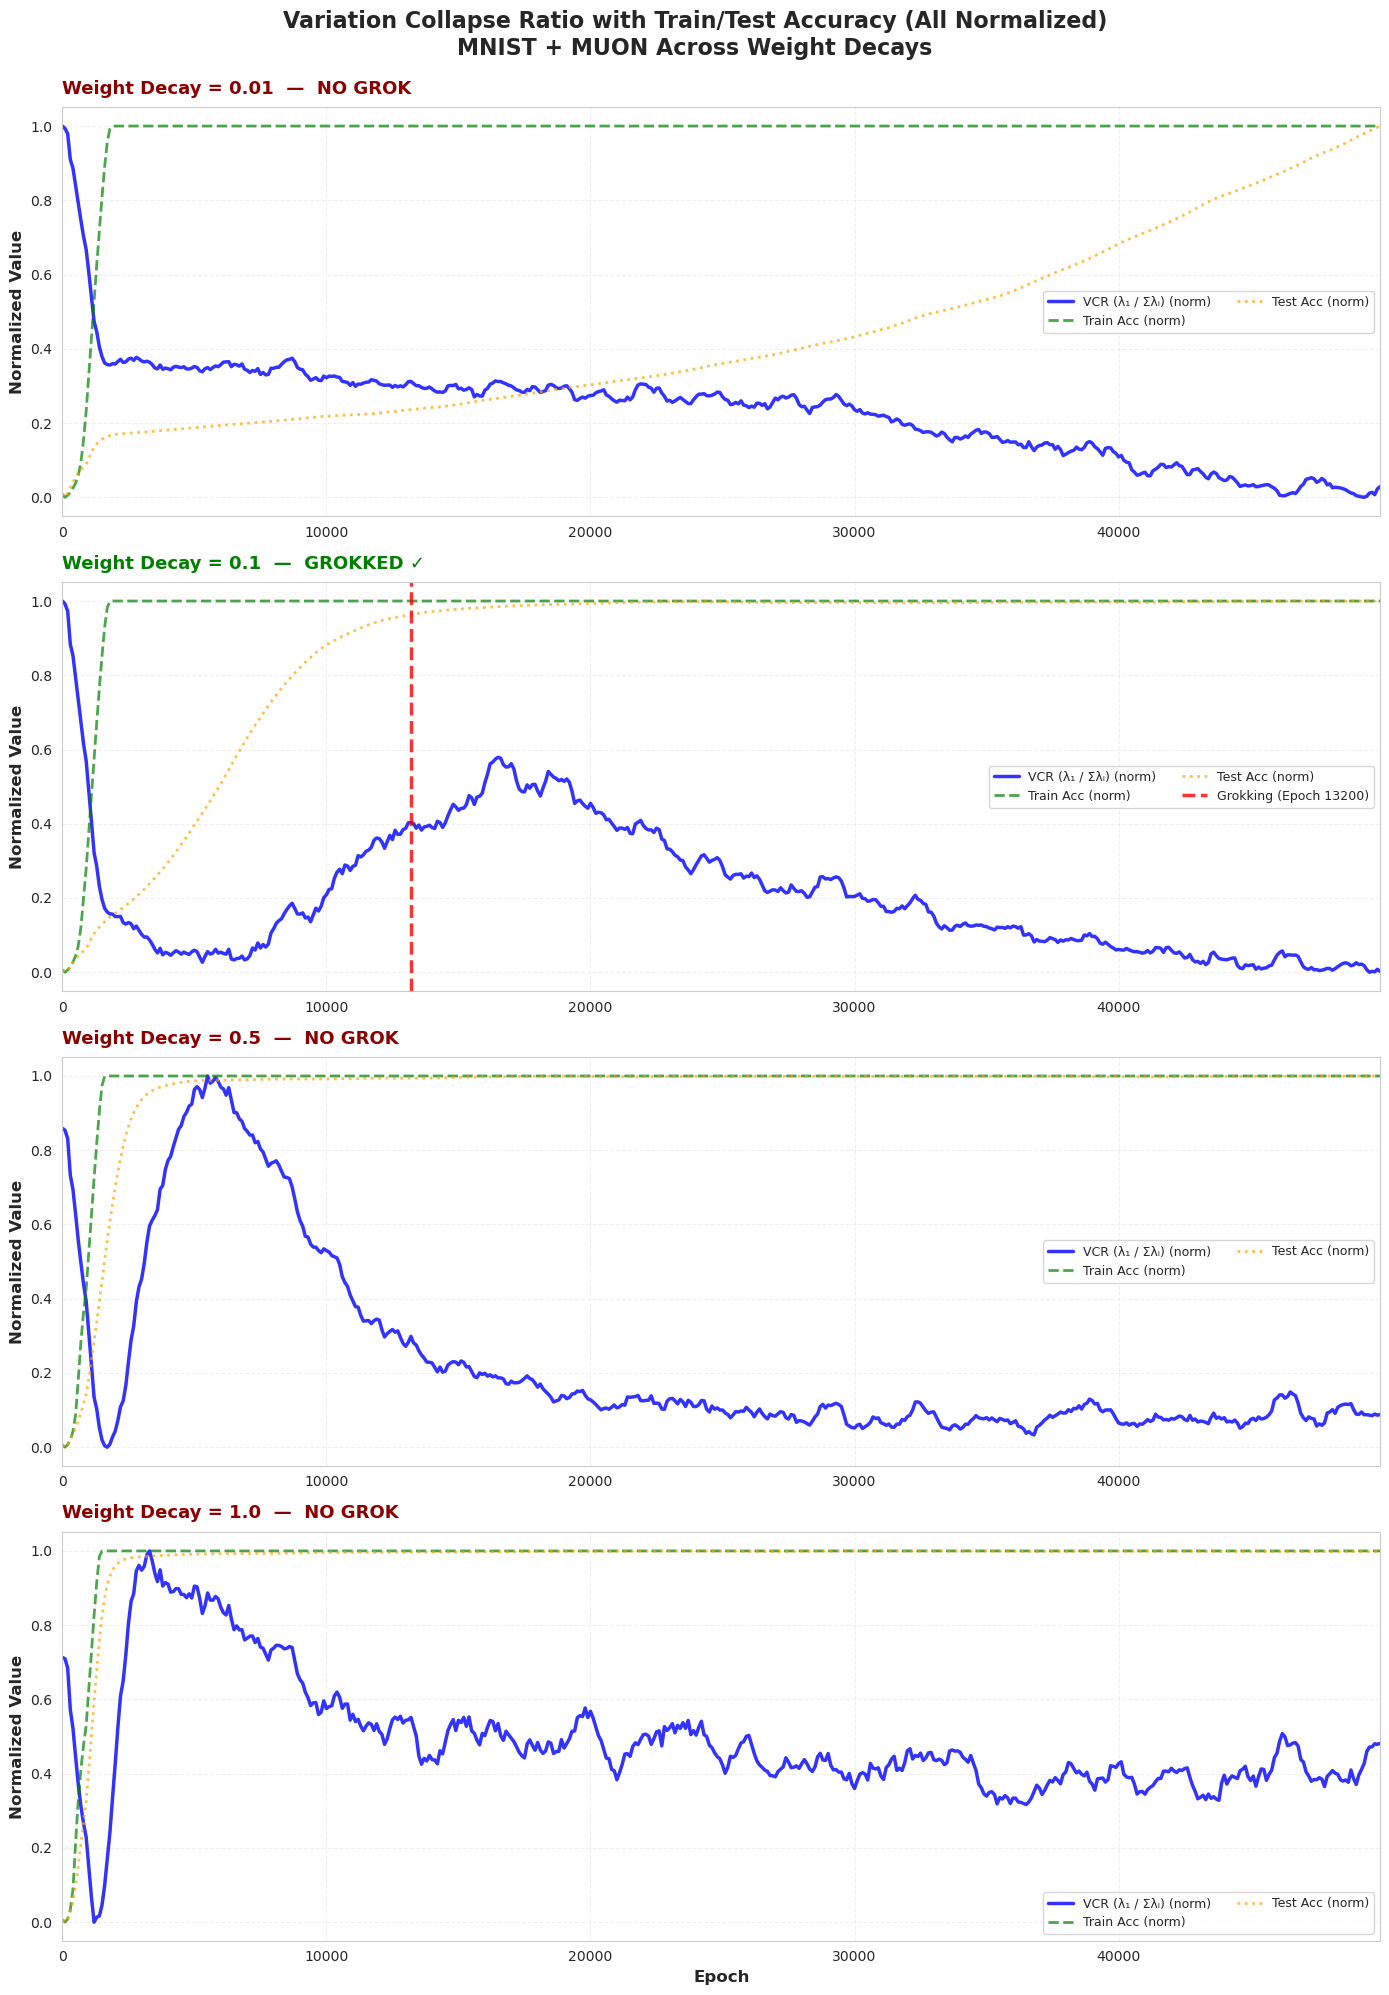

  Generated overlay panel for Variation Collapse Ratio


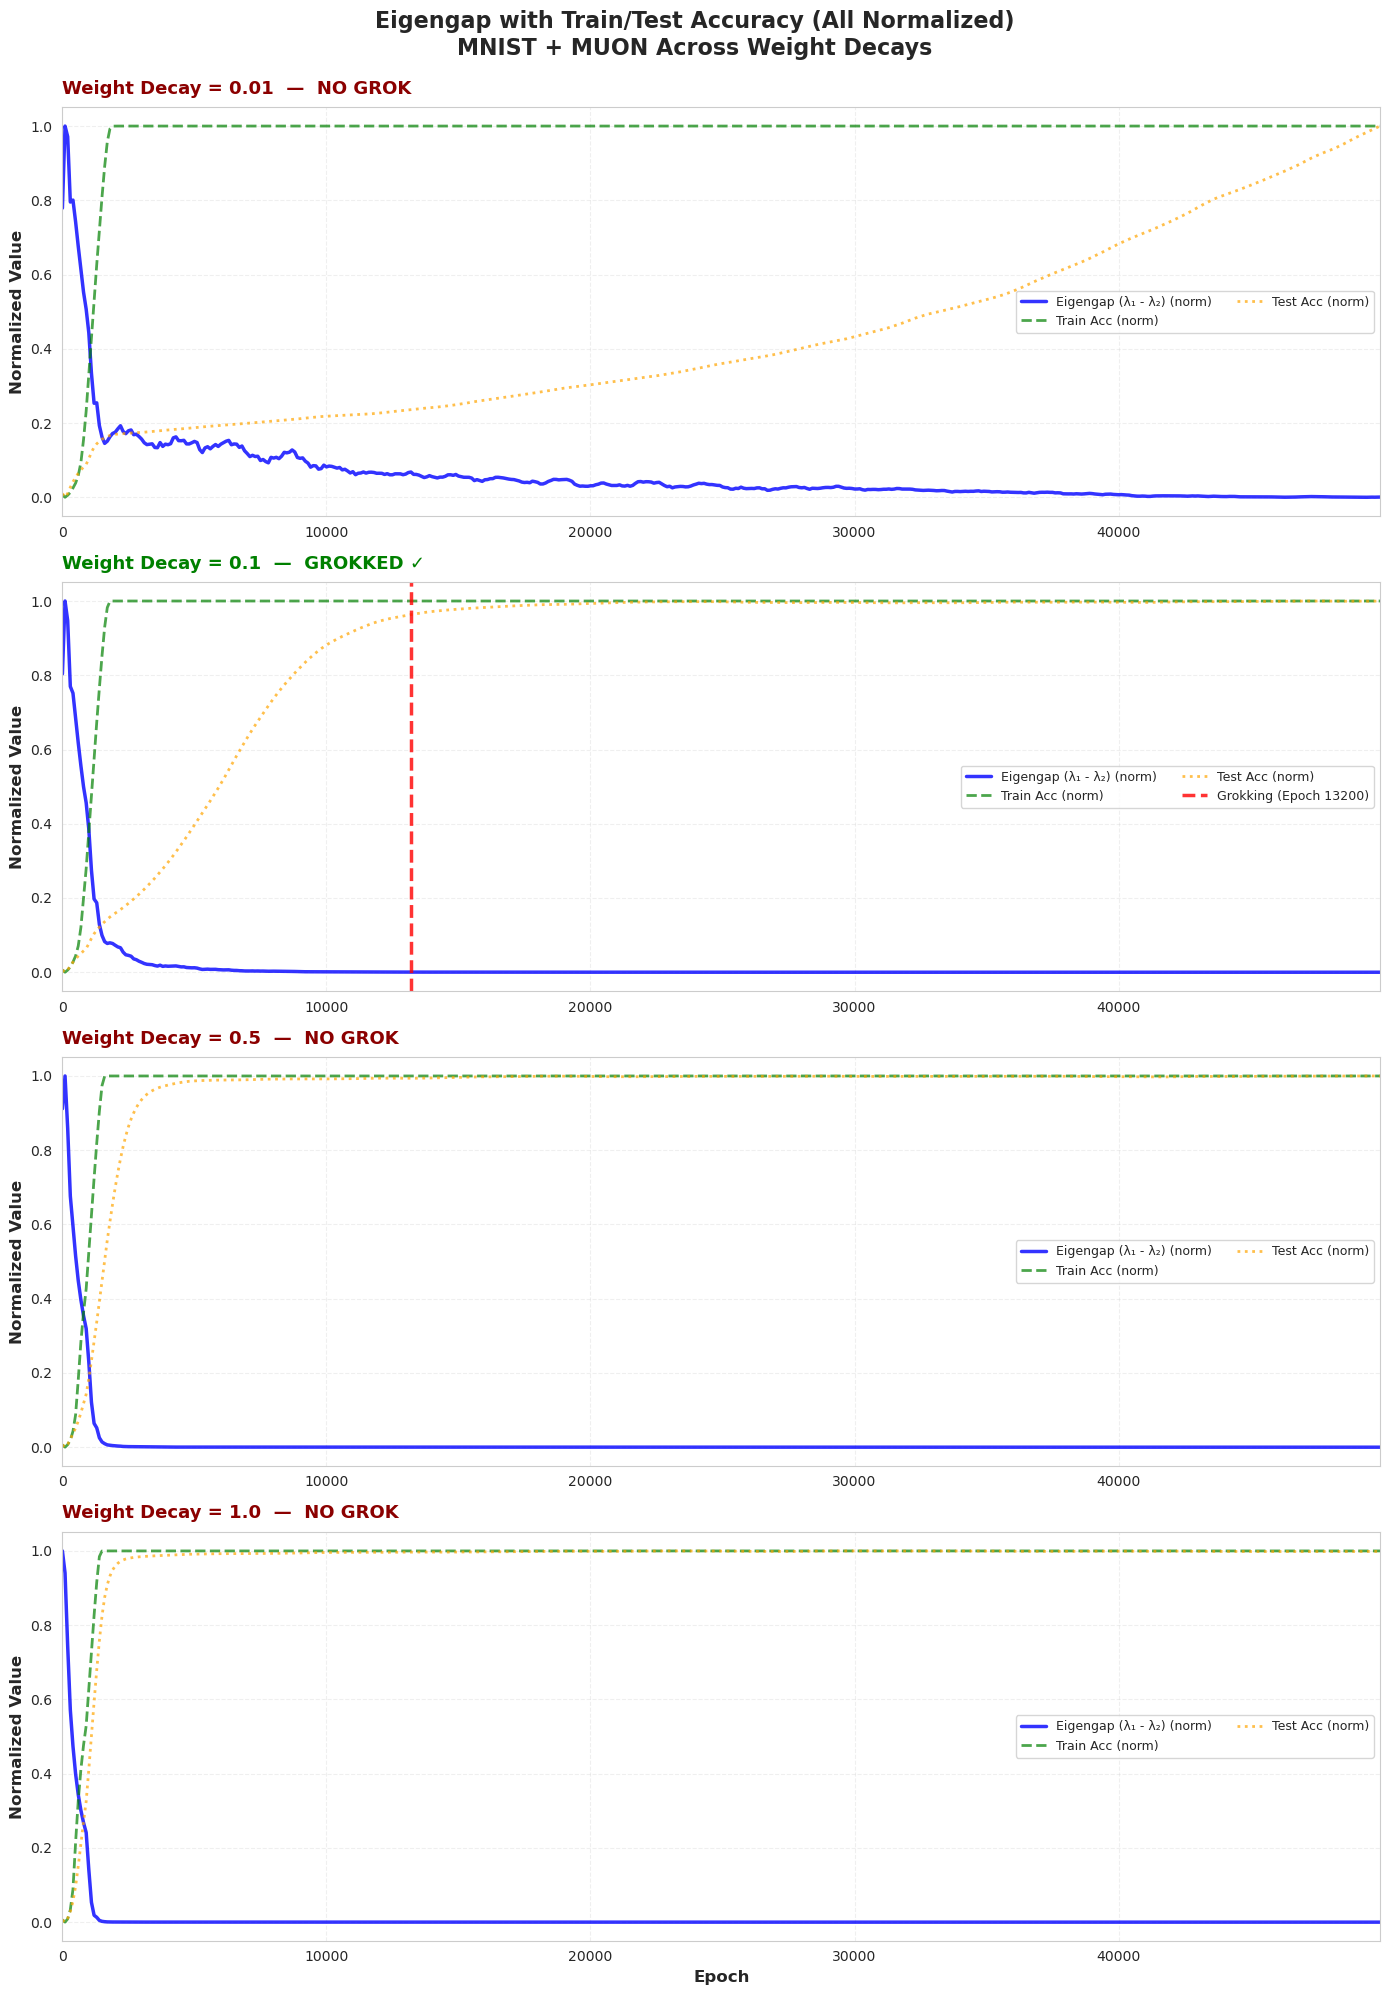

  Generated overlay panel for Eigengap


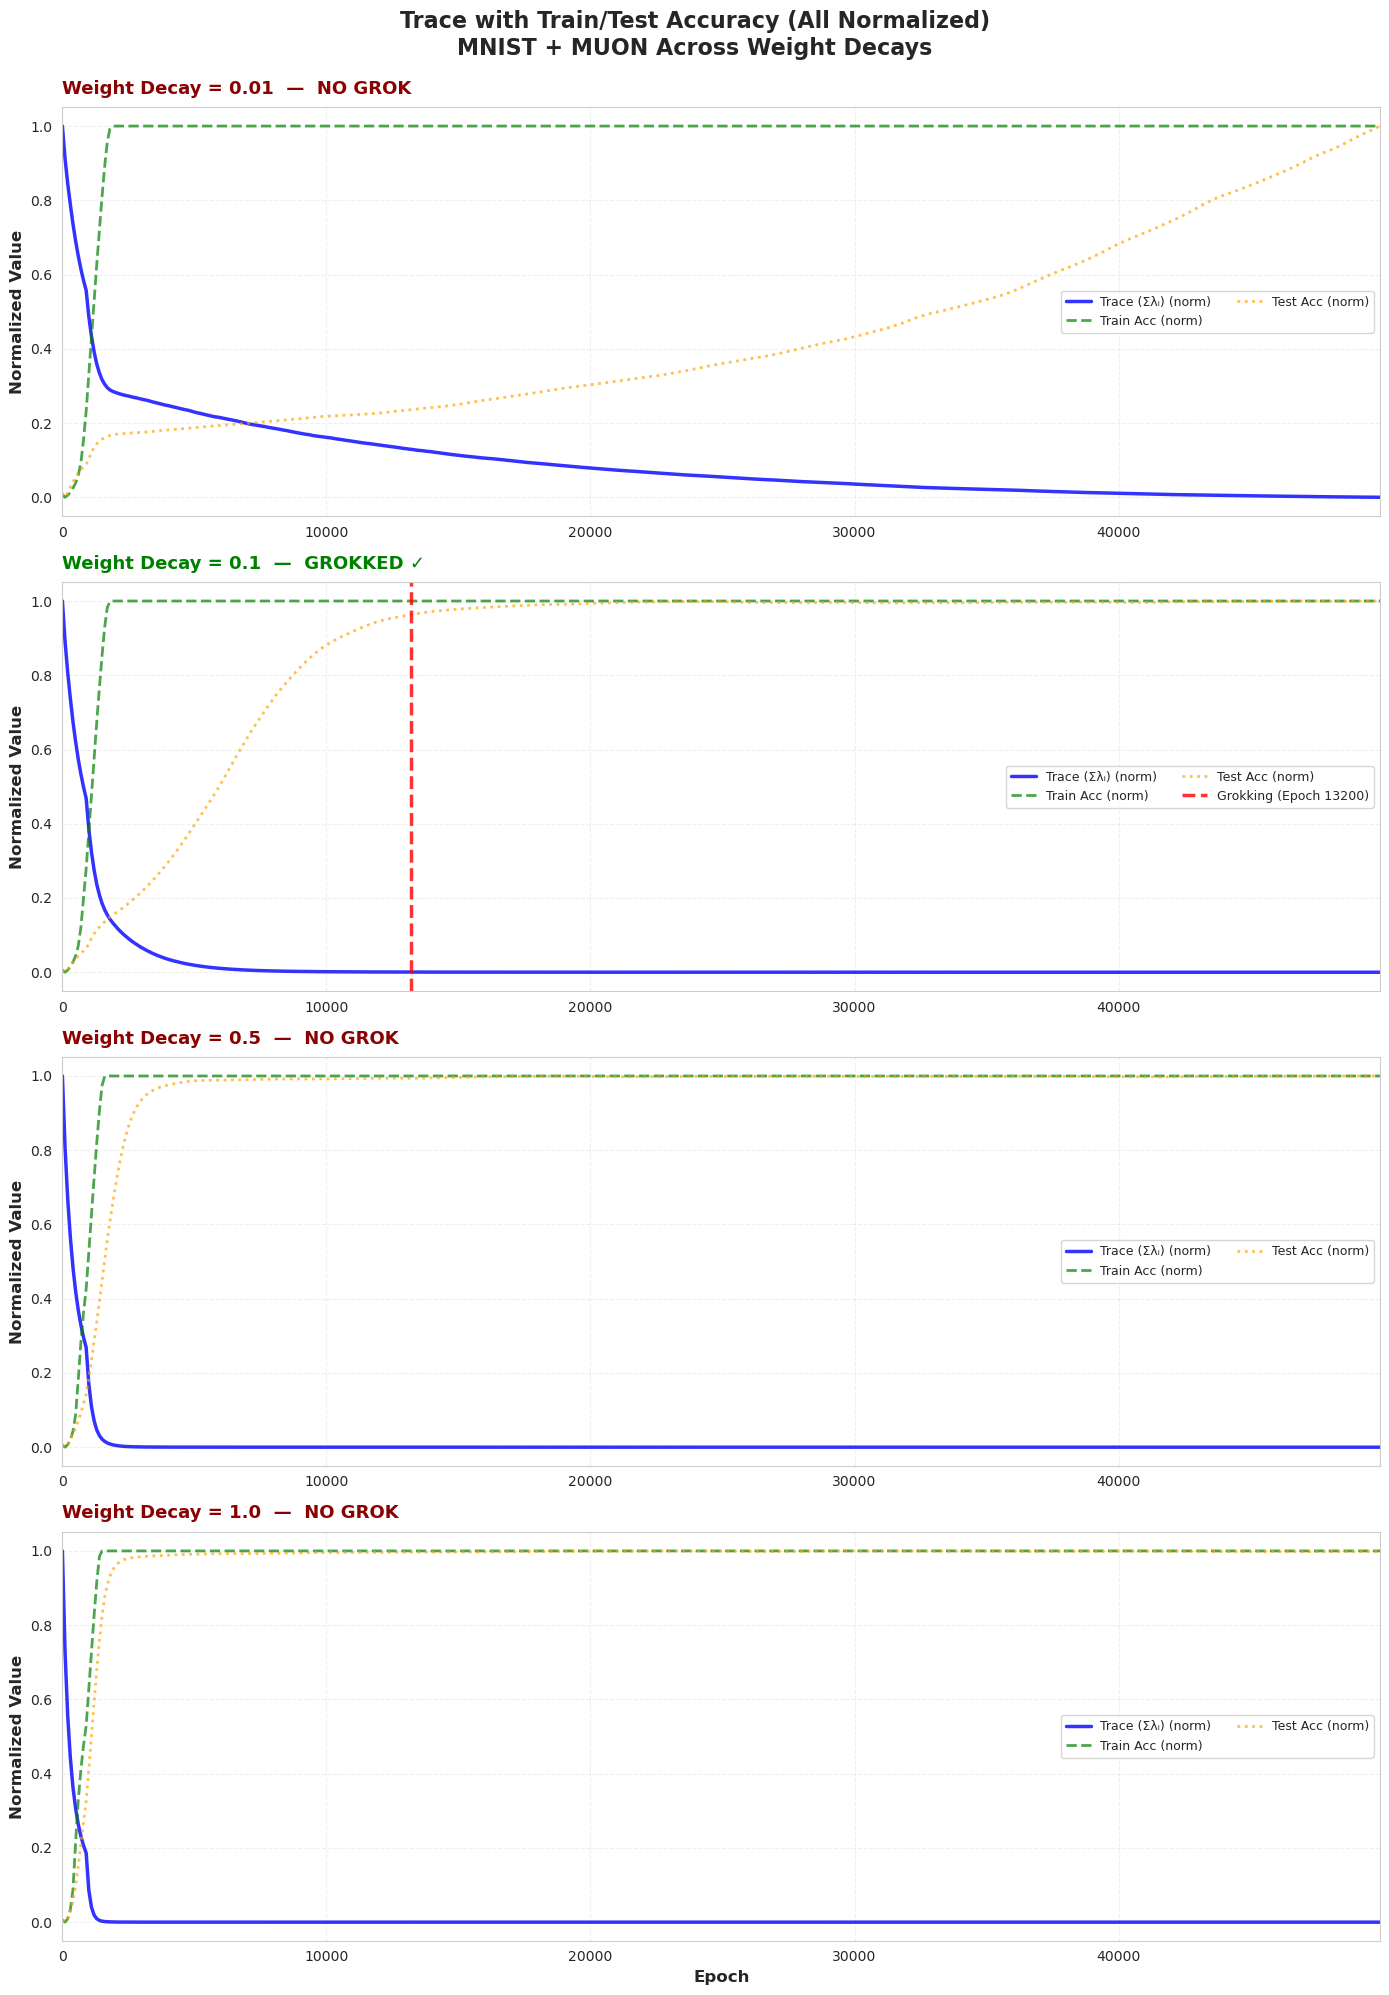

  Generated overlay panel for Trace


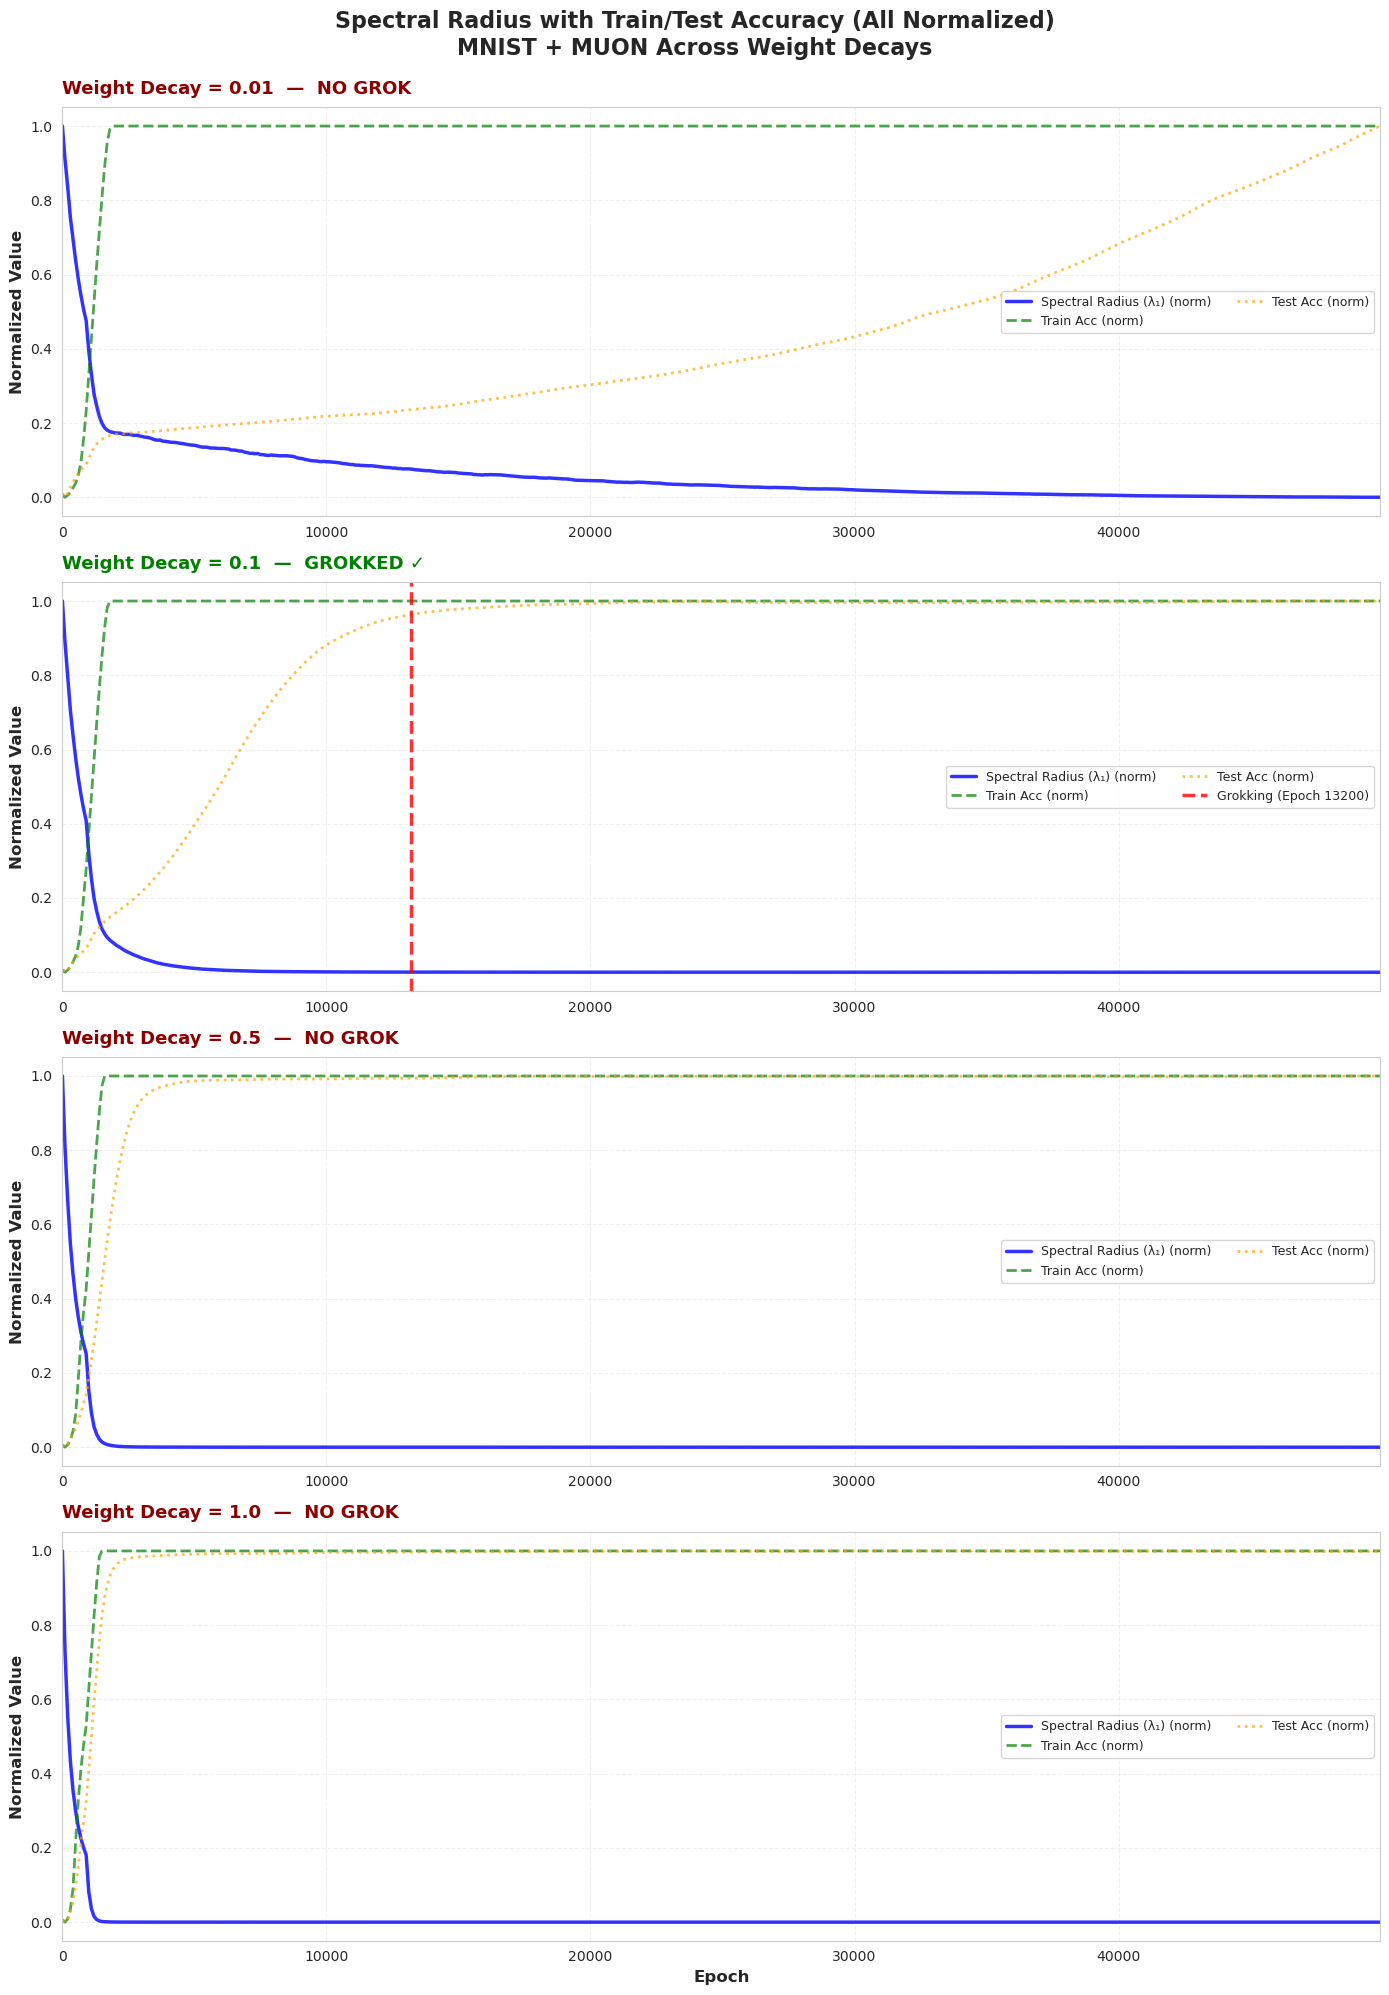

  Generated overlay panel for Spectral Radius

Processing SGD MNIST experiments...


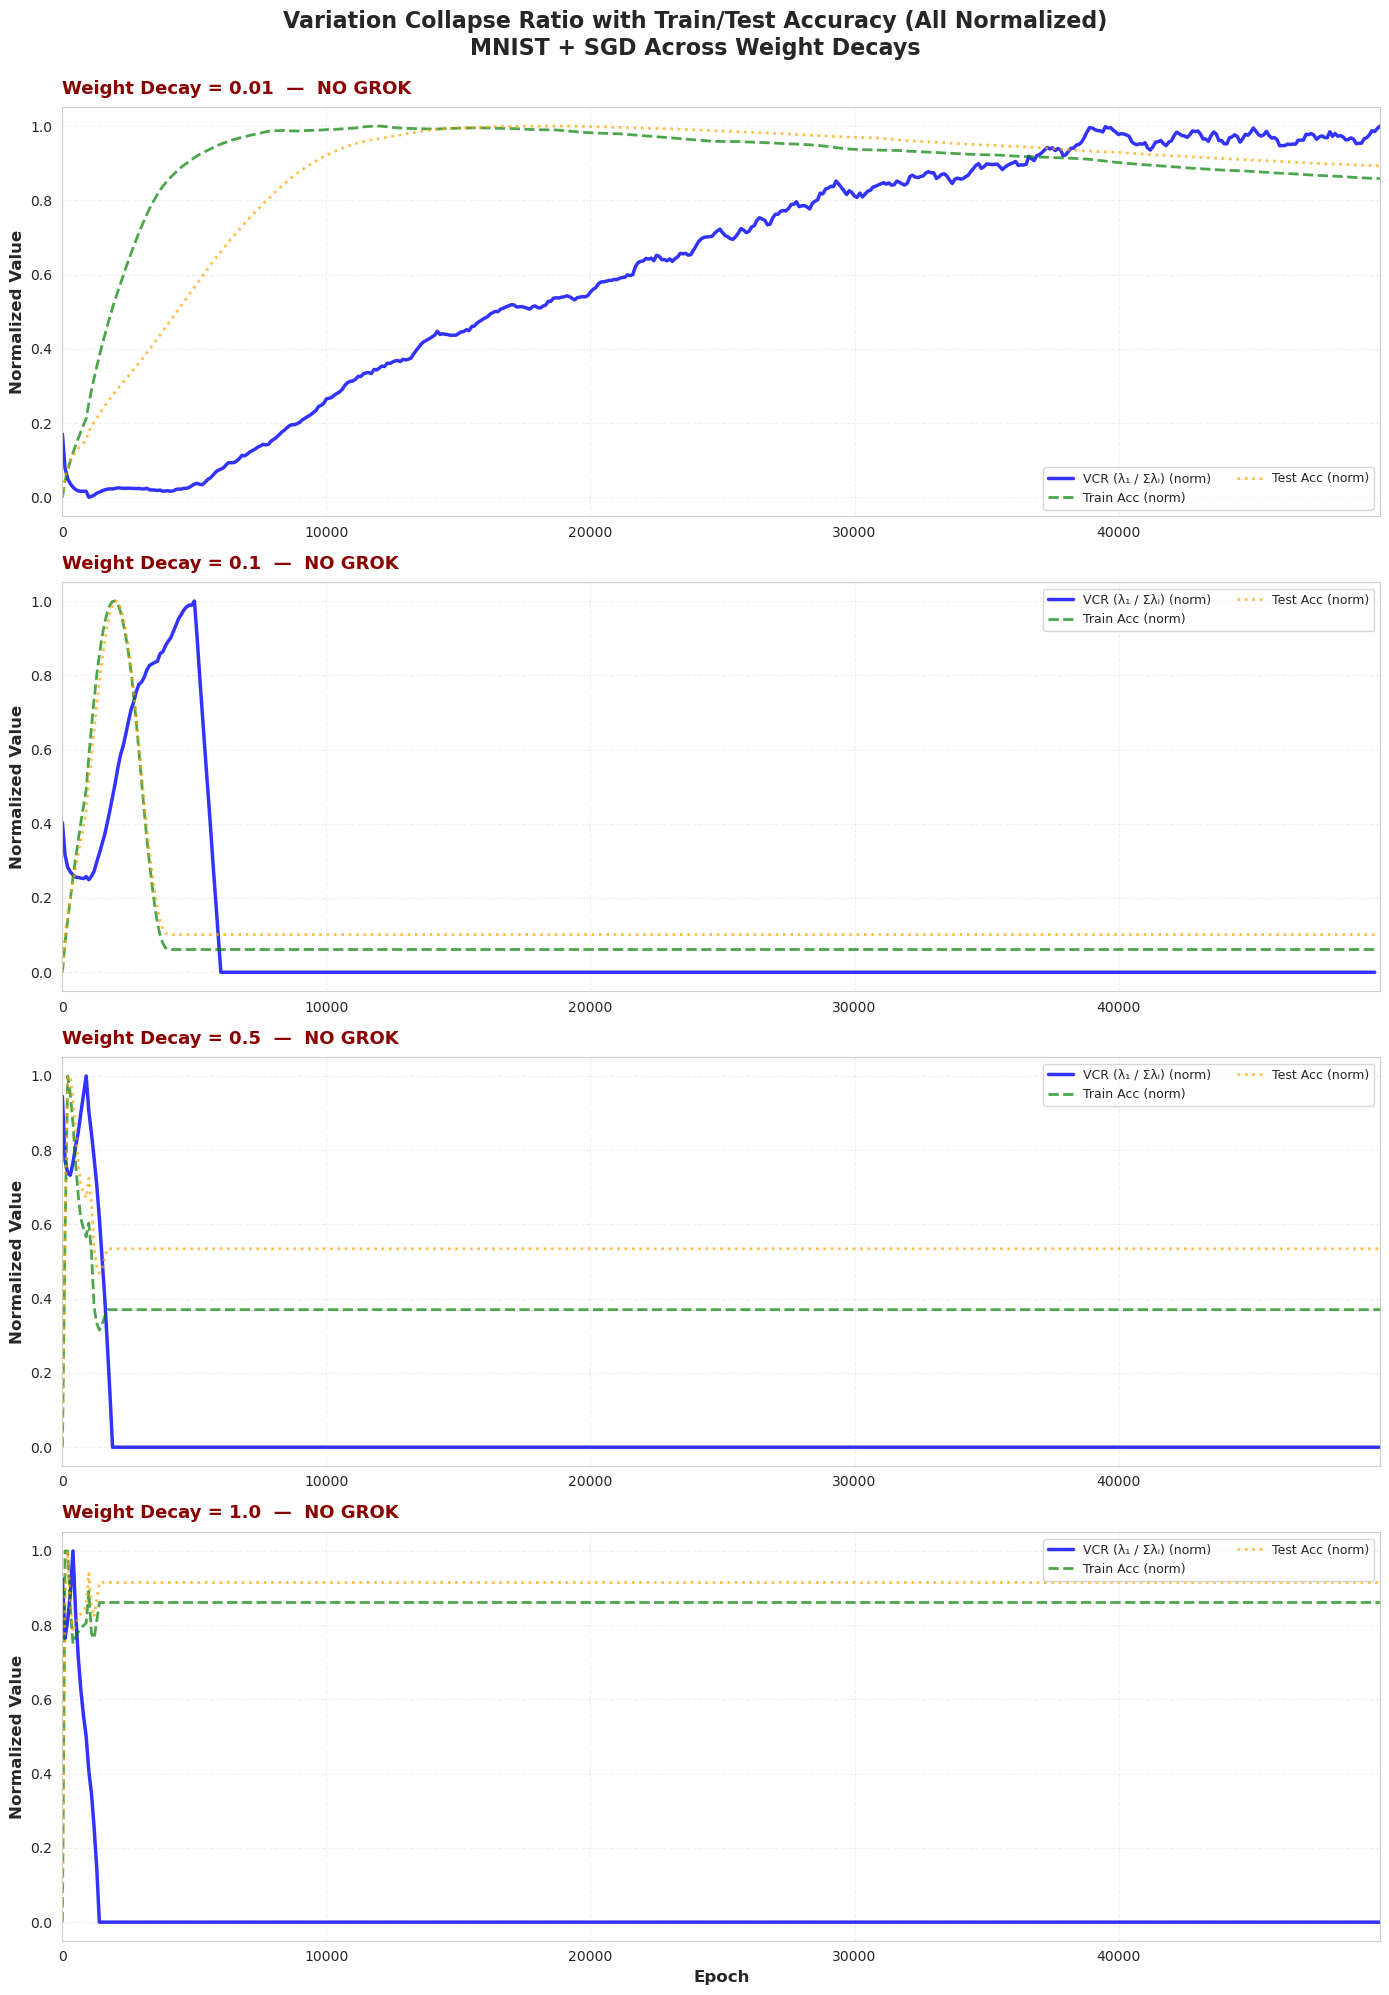

  Generated overlay panel for Variation Collapse Ratio


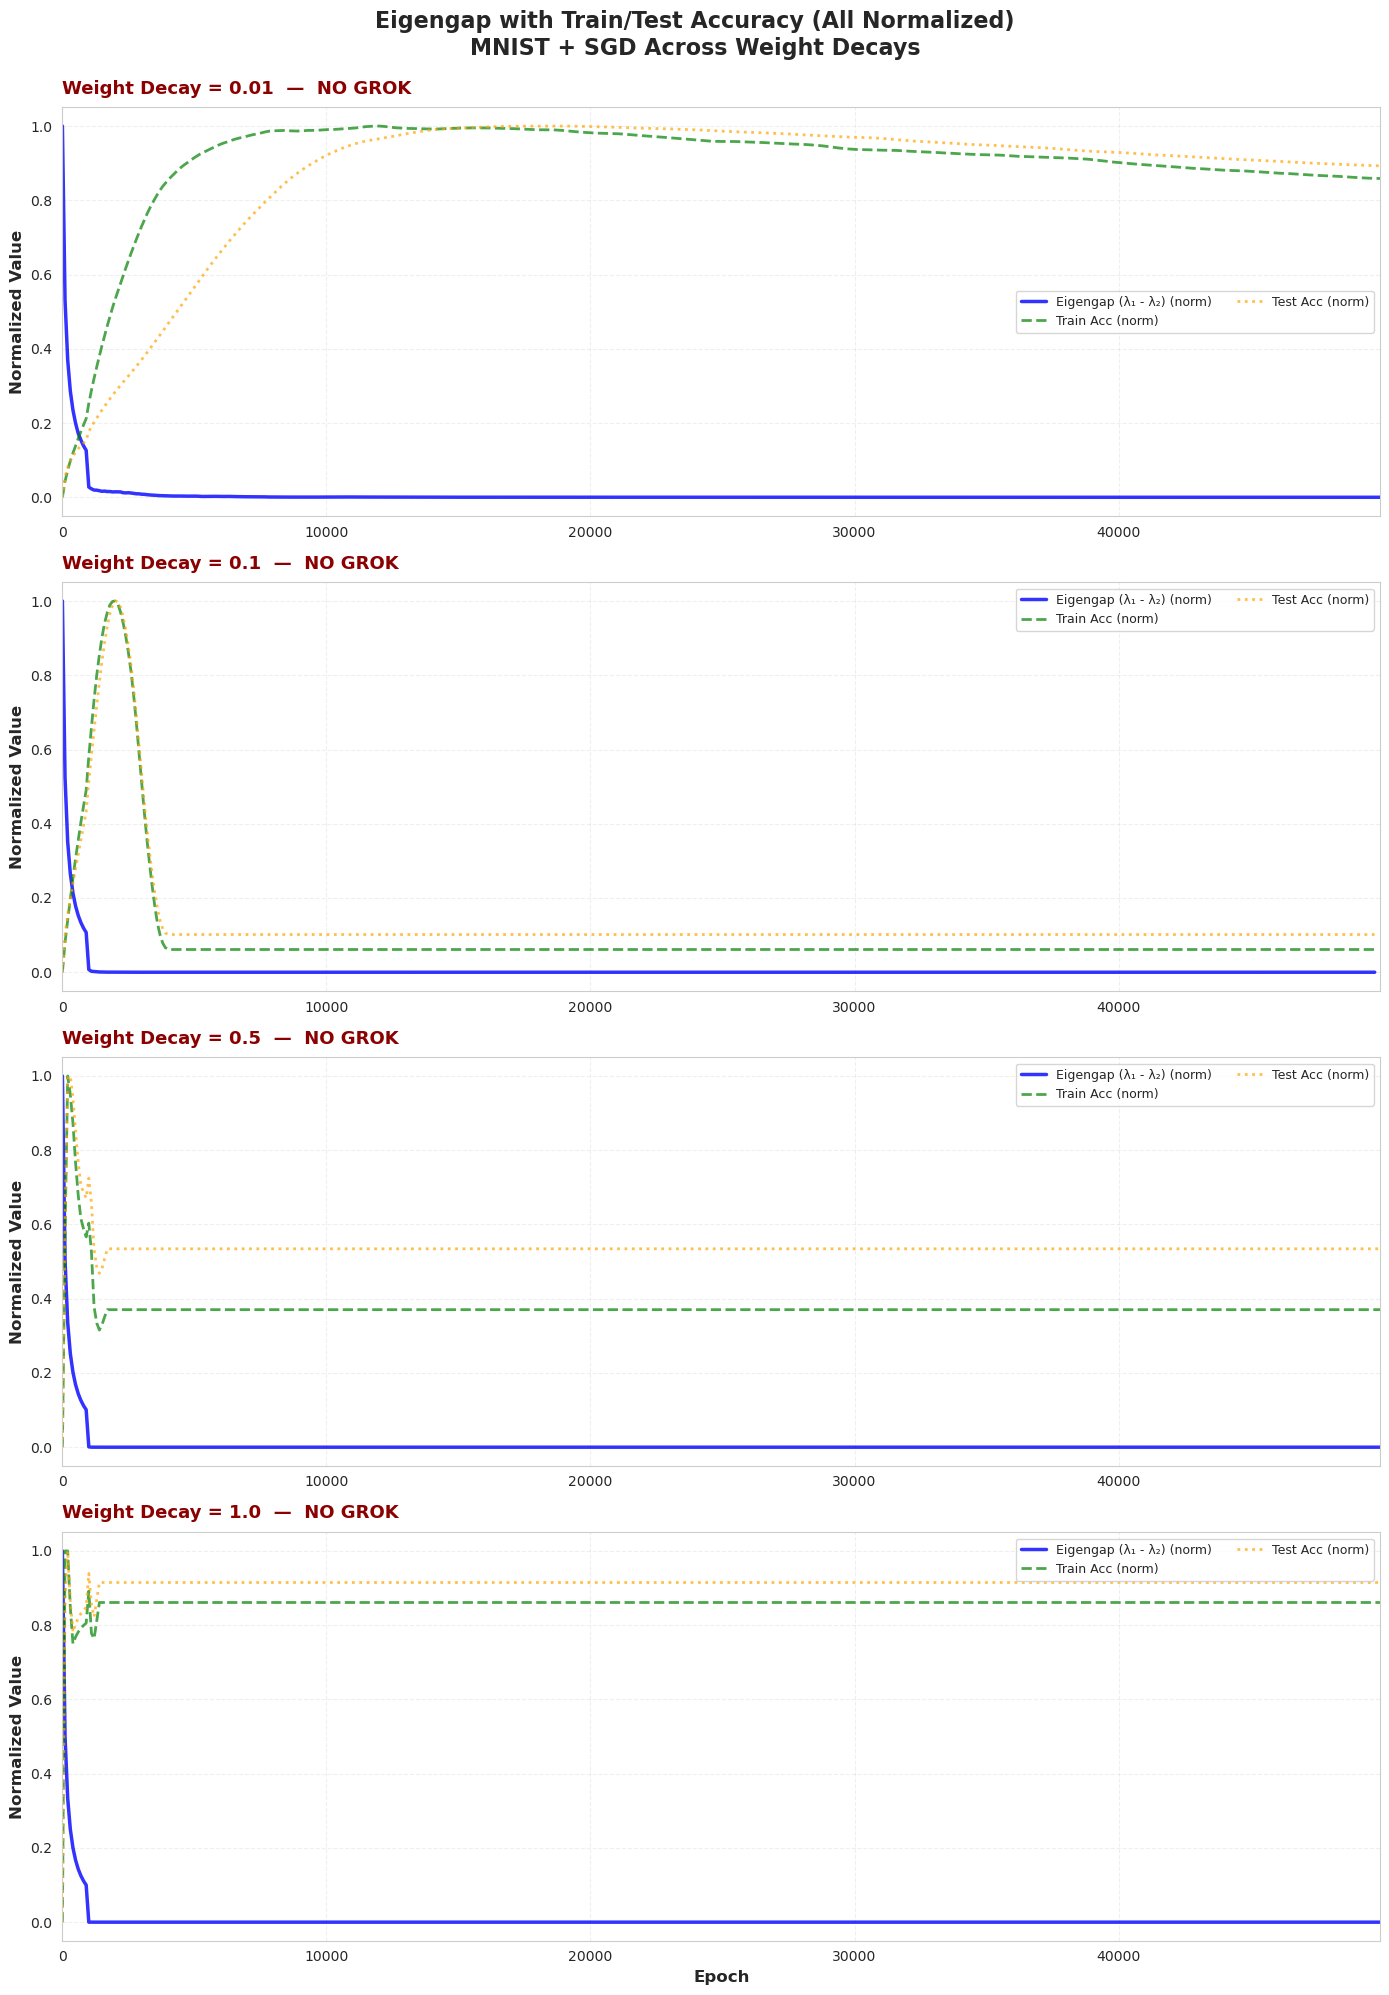

  Generated overlay panel for Eigengap


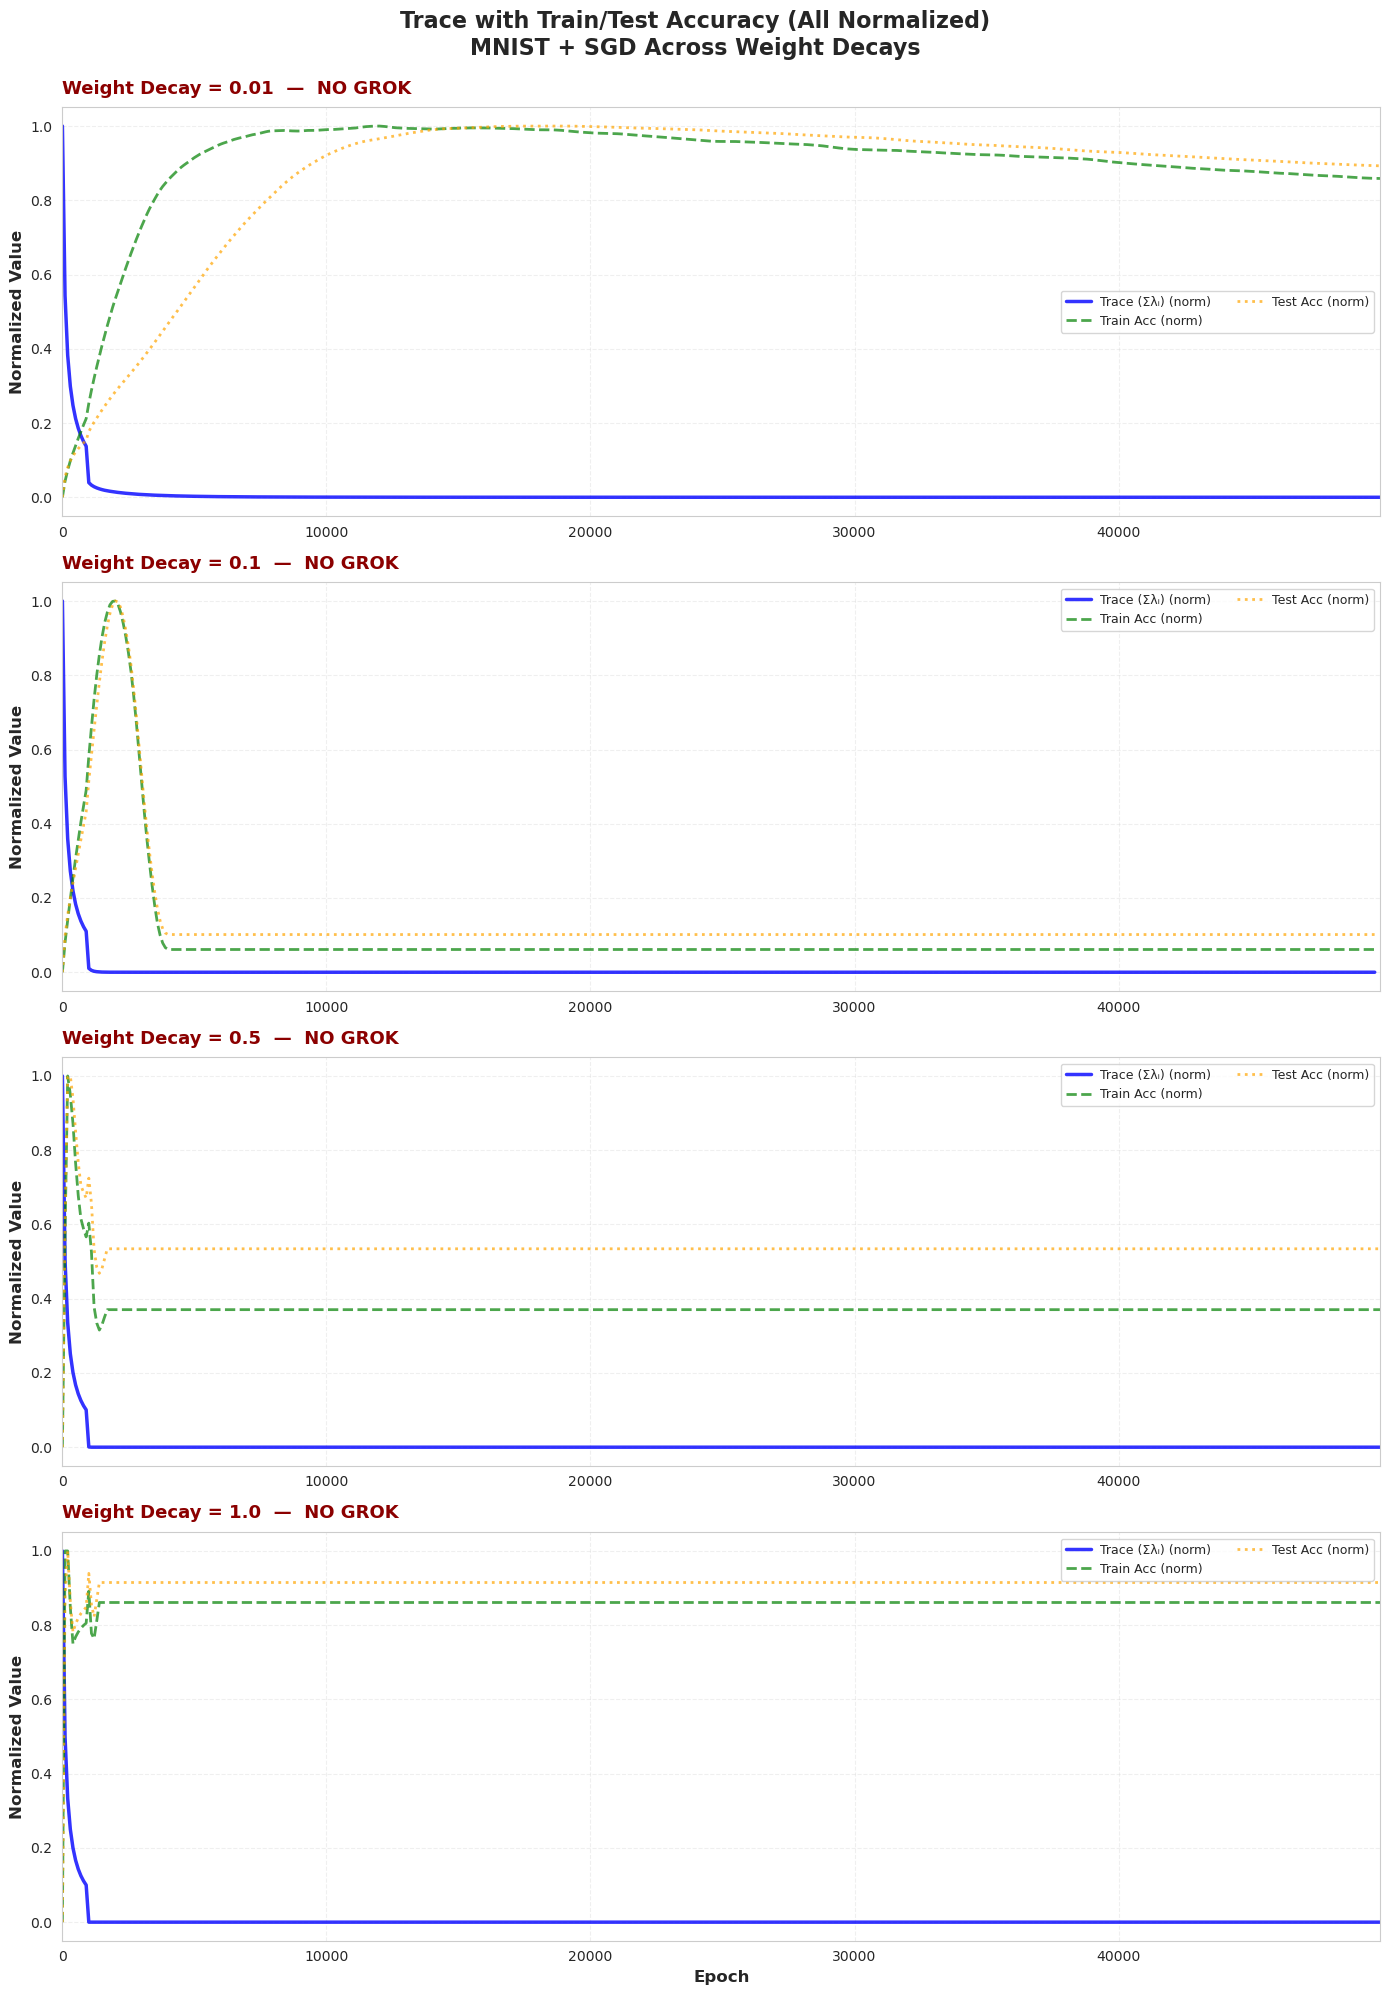

  Generated overlay panel for Trace


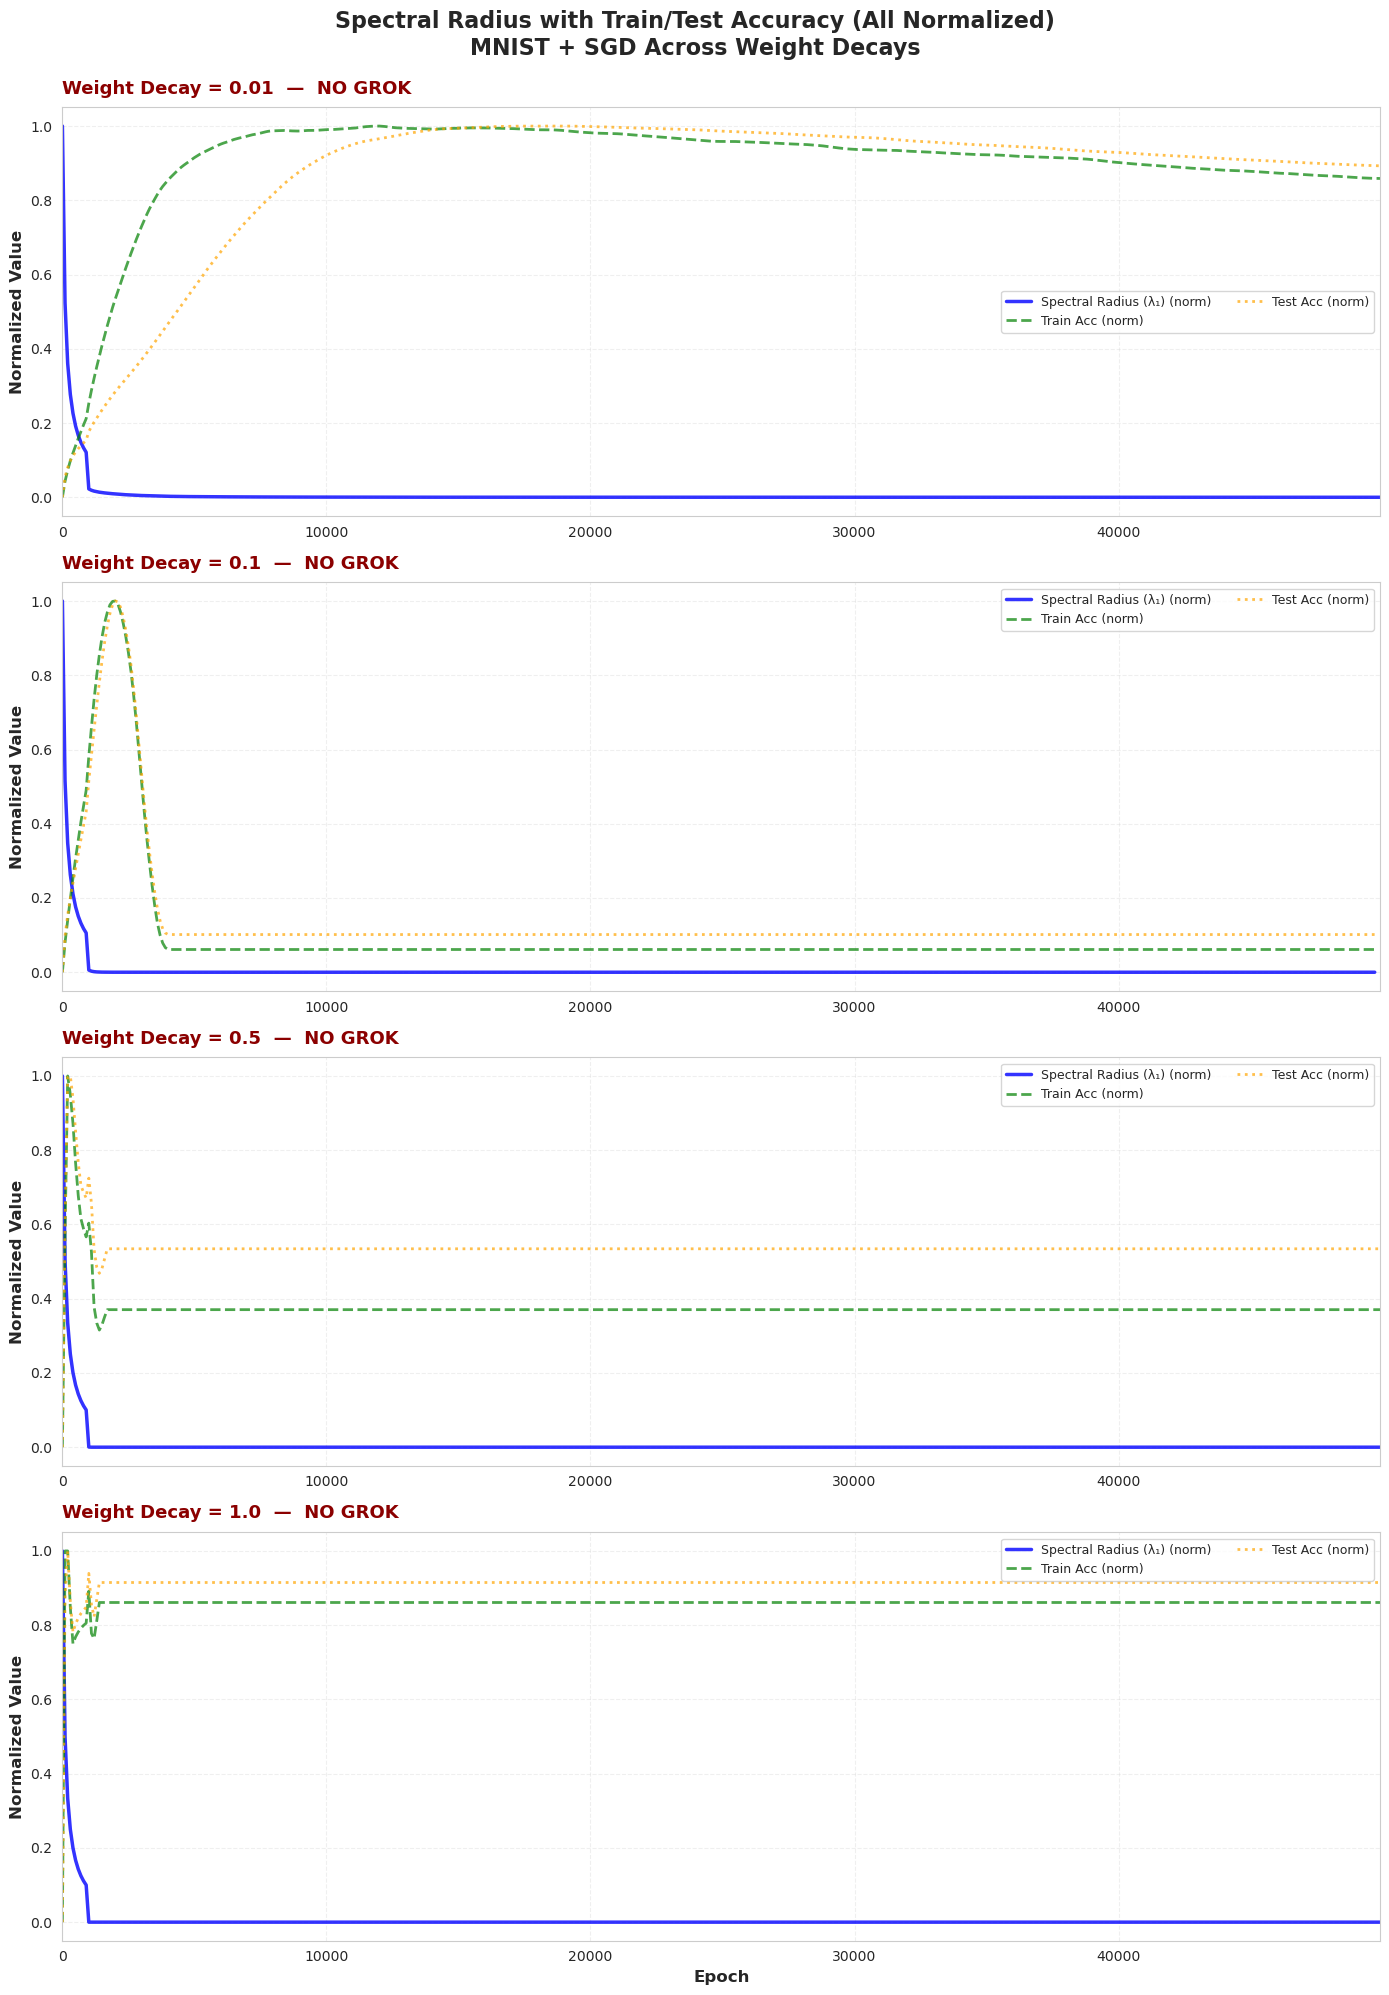

  Generated overlay panel for Spectral Radius


In [ ]:
# For each optimizer, create overlay plots for each AGOP metric
for opt, sorted_exps in mnist_by_opt.items():
    print(f"\nProcessing {opt.upper()} MNIST experiments...")
    
    for metric_name, metric_label, metric_title in agop_metrics:
        # Collect all data for this optimizer
        all_data = []
        
        for exp_name, exp_data in sorted_exps:
            history = exp_data.get('history', {})
            config = exp_data.get('config', {})
            
            # Check if all required data exists
            if metric_name not in history or 'train_acc' not in history or 'test_acc' not in history:
                continue
            
            epochs = np.array(history.get('epoch', range(len(history.get('test_acc', [])))))
            metric_values = np.array(history[metric_name])
            train_acc = np.array(history['train_acc'])
            test_acc = np.array(history['test_acc'])
            
            # Align lengths
            min_len = min(len(epochs), len(metric_values), len(train_acc), len(test_acc))
            epochs = epochs[:min_len]
            metric_values = metric_values[:min_len]
            train_acc = train_acc[:min_len]
            test_acc = test_acc[:min_len]
            
            # Detect grokking
            grok_epoch_idx = detect_grokking_epoch(train_acc, test_acc)
            grok_epoch = epochs[grok_epoch_idx] if grok_epoch_idx is not None else None
            
            # Smooth and normalize
            metric_smooth = smooth_series(metric_values, window=10)
            train_smooth = smooth_series(train_acc, window=10)
            test_smooth = smooth_series(test_acc, window=10)
            
            metric_norm = normalize_series(metric_smooth)
            train_norm = normalize_series(train_smooth)
            test_norm = normalize_series(test_smooth)
            
            all_data.append({
                'exp_name': exp_name,
                'config': config,
                'epochs': epochs,
                'metric_norm': metric_norm,
                'train_norm': train_norm,
                'test_norm': test_norm,
                'grok_epoch': grok_epoch
            })
        
        if not all_data:
            print(f"  No data available for {metric_title}, skipping...")
            continue
        
        max_epochs = max([d['epochs'][-1] for d in all_data if len(d['epochs']) > 0])
        
        # Create vertically stacked subplots (one per weight decay)
        n_subplots = len(all_data)
        fig, axes = plt.subplots(n_subplots, 1, figsize=(14, 5 * n_subplots))
        
        # Handle single subplot case
        if n_subplots == 1:
            axes = [axes]
        
        for idx, data_dict in enumerate(all_data):
            ax = axes[idx]
            
            epochs = data_dict['epochs']
            metric_norm = data_dict['metric_norm']
            train_norm = data_dict['train_norm']
            test_norm = data_dict['test_norm']
            grok_epoch = data_dict['grok_epoch']
            config = data_dict['config']
            wd = config.get('weight_decay', 0)
            
            # Plot all three normalized signals
            ax.plot(epochs, metric_norm, linewidth=2.5, color='blue', alpha=0.8, 
                   label=f'{metric_label} (norm)', linestyle='-')
            ax.plot(epochs, train_norm, linewidth=2.0, color='green', alpha=0.7, 
                   label='Train Acc (norm)', linestyle='--')
            ax.plot(epochs, test_norm, linewidth=2.0, color='orange', alpha=0.7, 
                   label='Test Acc (norm)', linestyle=':')
            
            # Mark grokking epoch if it exists
            if grok_epoch is not None:
                ax.axvline(x=grok_epoch, color='red', linestyle='--', linewidth=2.5, alpha=0.8, 
                          label=f'Grokking (Epoch {grok_epoch})')
                status = "GROKKED ✓"
                title_color = 'green'
            else:
                status = "NO GROK"
                title_color = 'darkred'
            
            # Formatting with unified axes
            ax.set_ylabel('Normalized Value', fontsize=12, fontweight='bold')
            ax.set_title(f'Weight Decay = {wd}  —  {status}', 
                        fontsize=13, fontweight='bold', color=title_color, pad=10, loc='left')
            ax.legend(fontsize=9, loc='best', ncol=2)
            ax.grid(alpha=0.3, linestyle='--')
            
            # Set unified axis limits
            ax.set_xlim([0, max_epochs])
            ax.set_ylim([-0.05, 1.05])
            
            # Only show x-label on bottom plot
            if idx == len(all_data) - 1:
                ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
            else:
                ax.set_xlabel('')
        
        # Overall title
        fig.suptitle(f'{metric_title} with Train/Test Accuracy (All Normalized)\nMNIST + {opt.upper()} Across Weight Decays', 
                    fontsize=16, fontweight='bold', y=0.995)
        plt.tight_layout()
        
        # Save figure
        safe_metric_name = metric_name.replace('_', '-')
        plt.savefig(FIGURES_DIR / f'mnist_{opt}_{safe_metric_name}_with_accuracy_overlay.png', 
                   dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"  Generated overlay panel for {metric_title}")


---
# Supplementary Analysis



Generating cross-optimizer comparison for Variation Collapse Ratio...


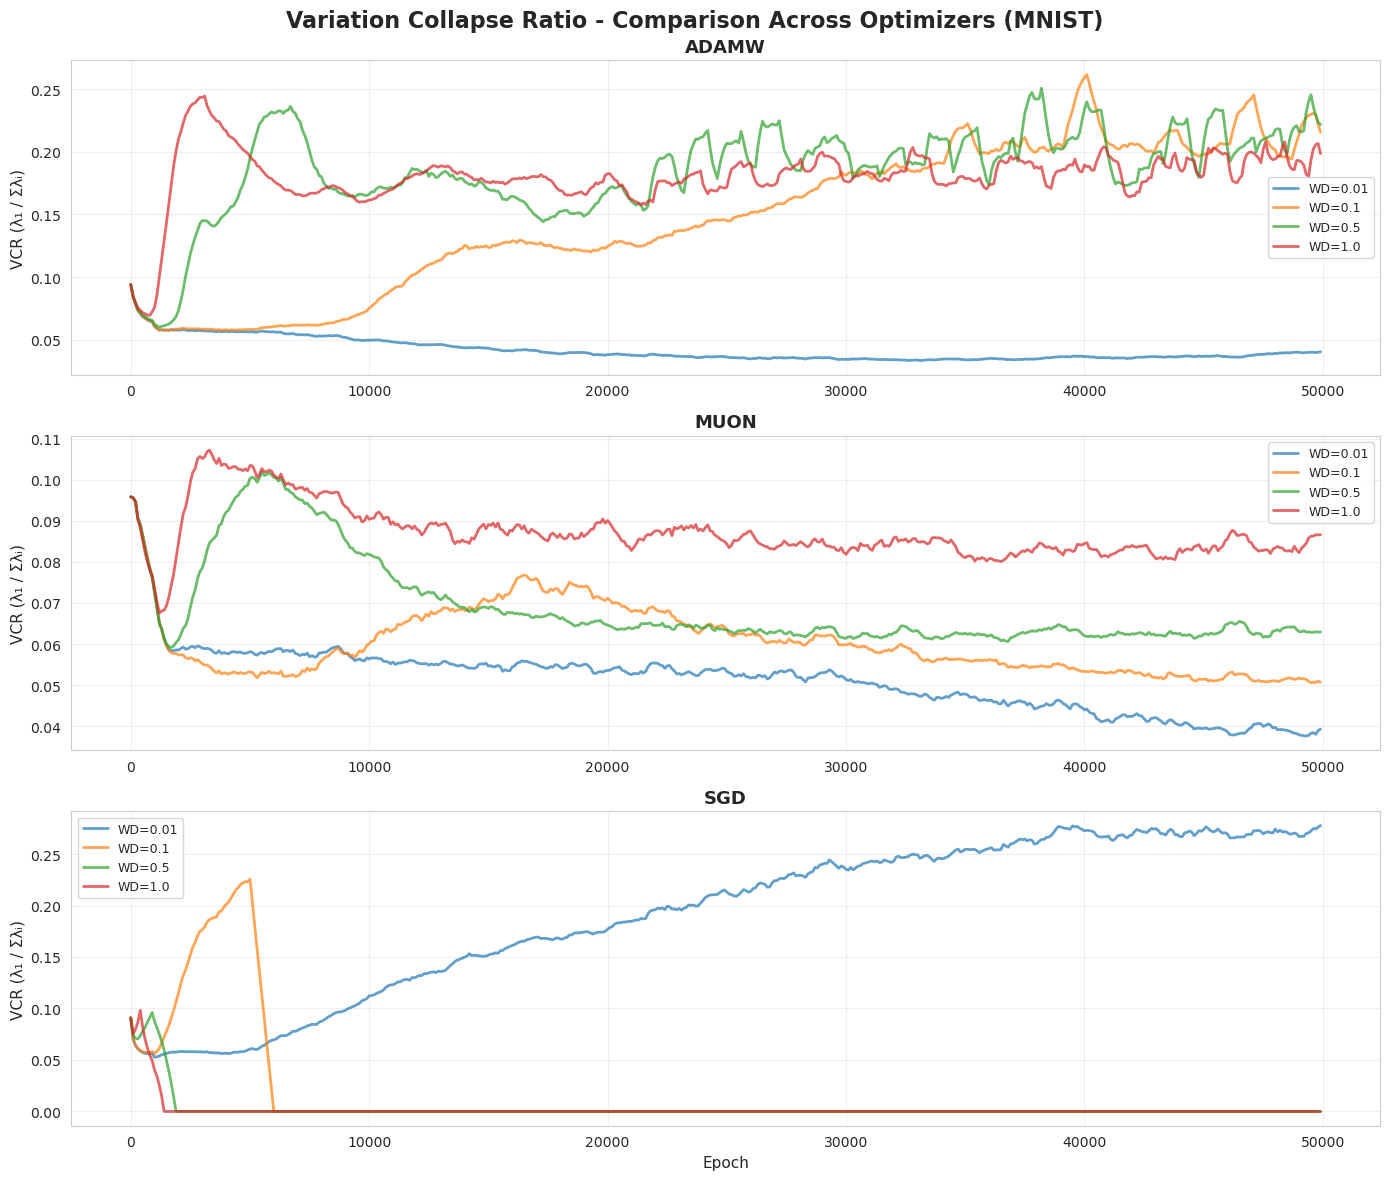

  Saved: mnist_agop-variation-collapse-ratio_optimizer_comparison.png

Generating cross-optimizer comparison for Eigengap...


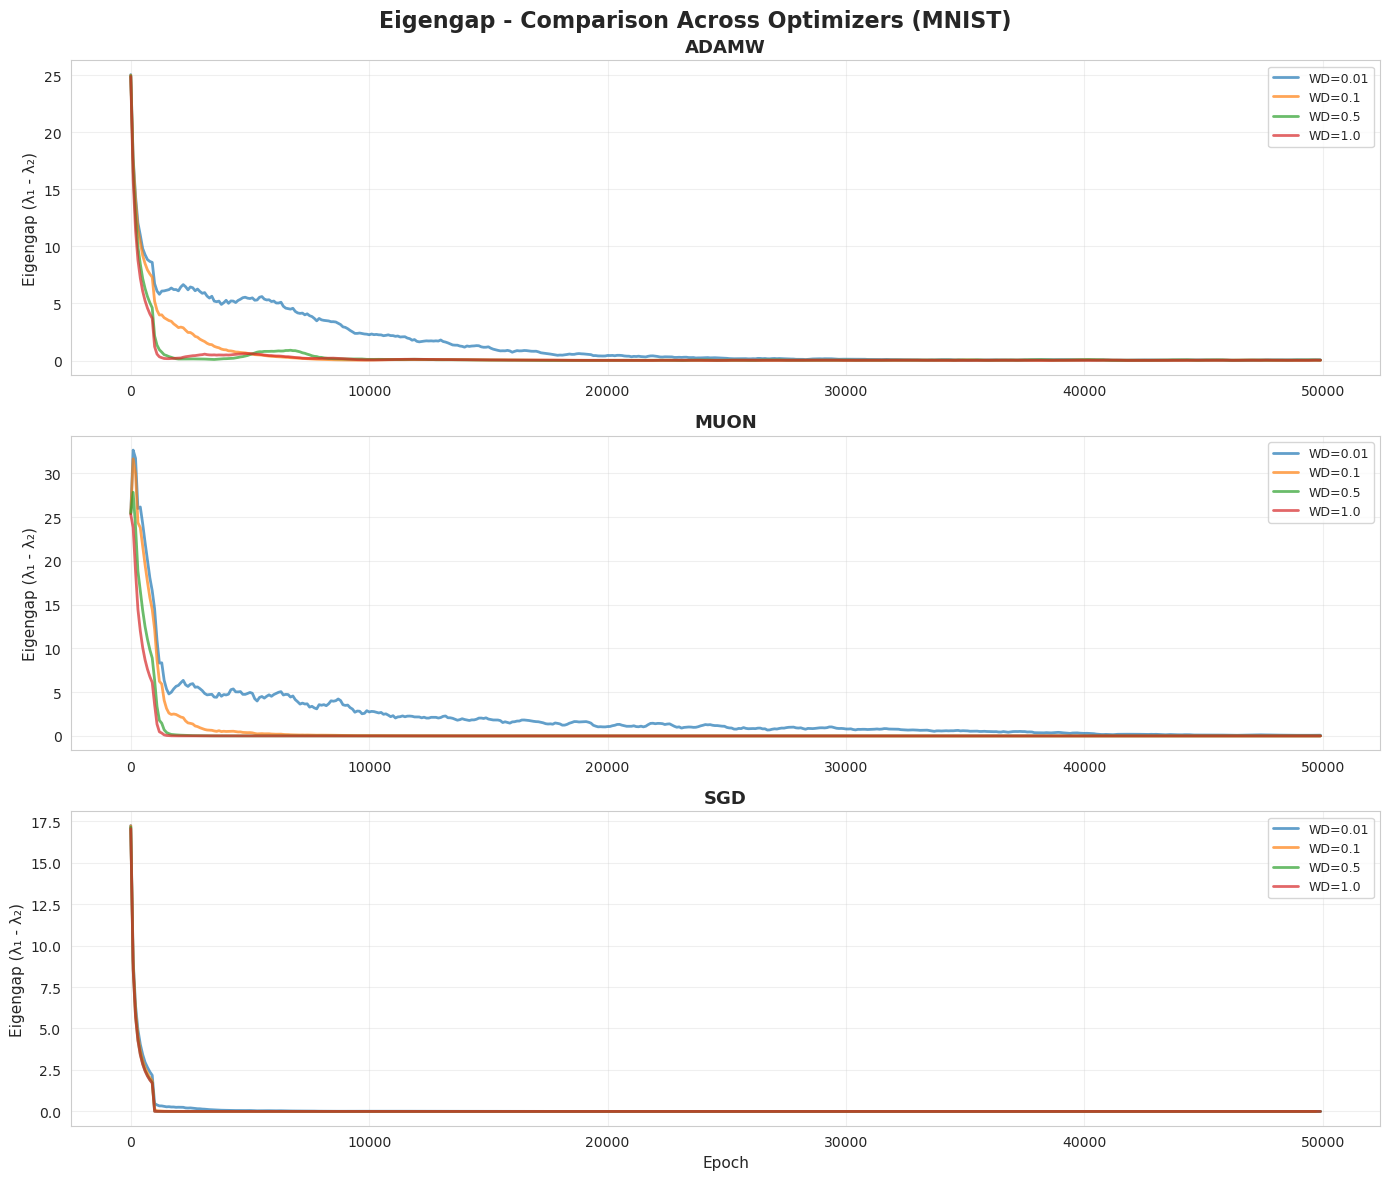

  Saved: mnist_agop-eigengap_optimizer_comparison.png

Generating cross-optimizer comparison for Trace...


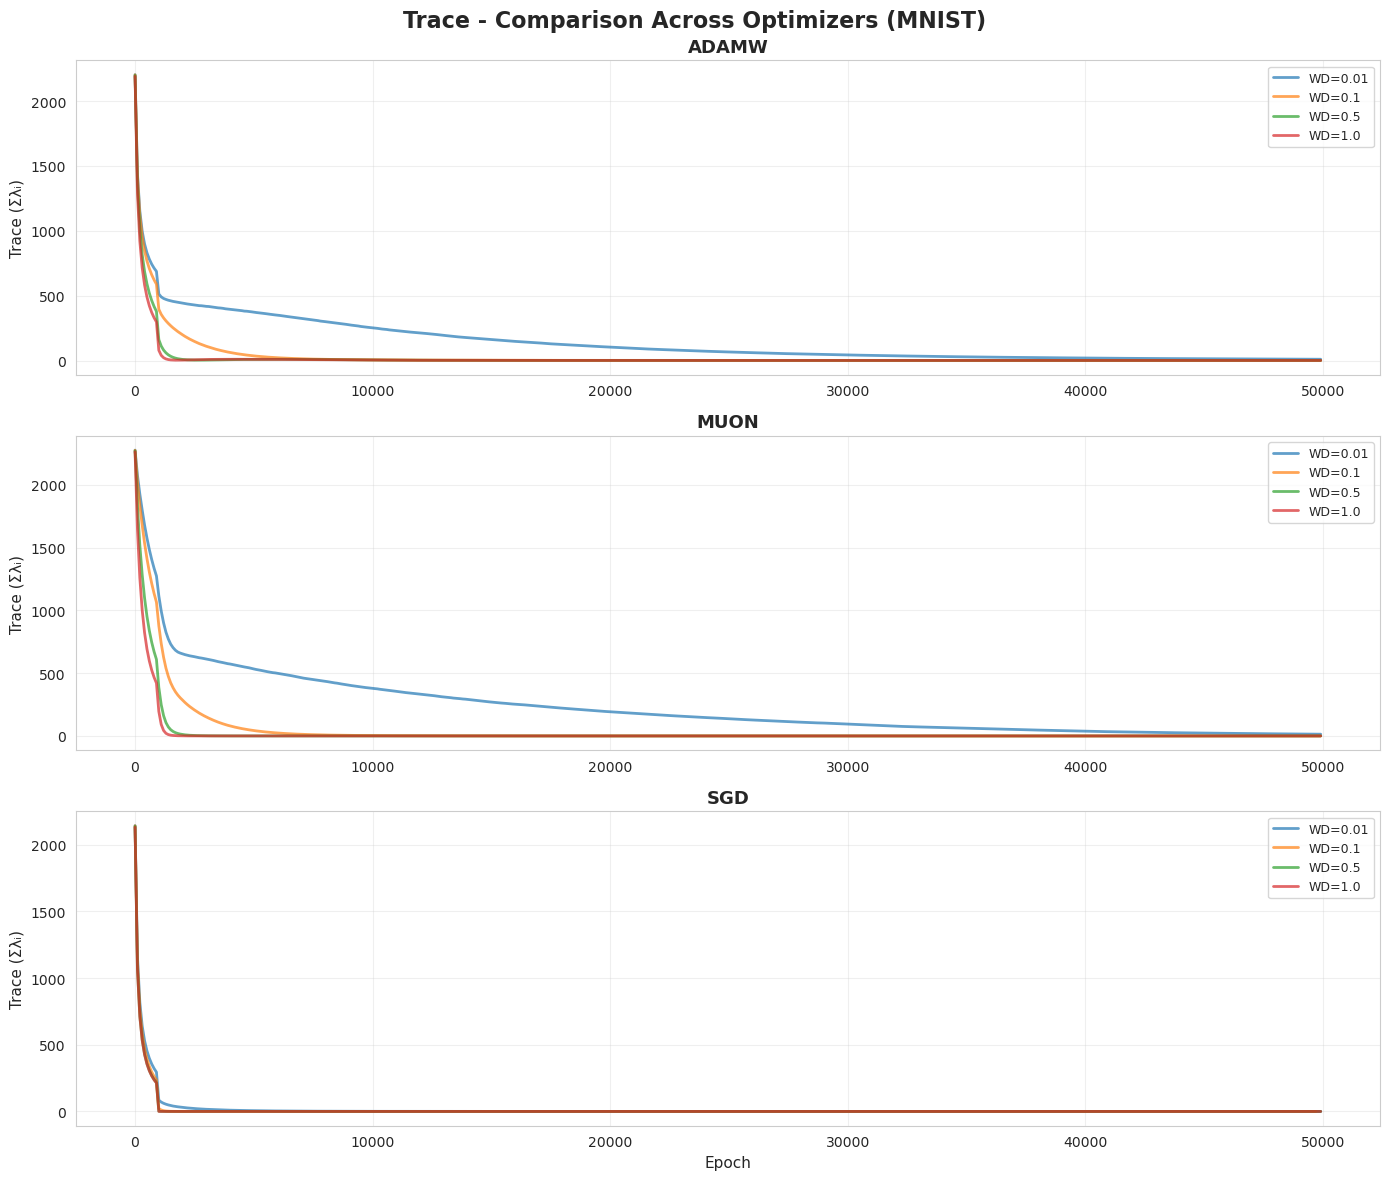

  Saved: mnist_agop-trace_optimizer_comparison.png

Generating cross-optimizer comparison for Spectral Radius...


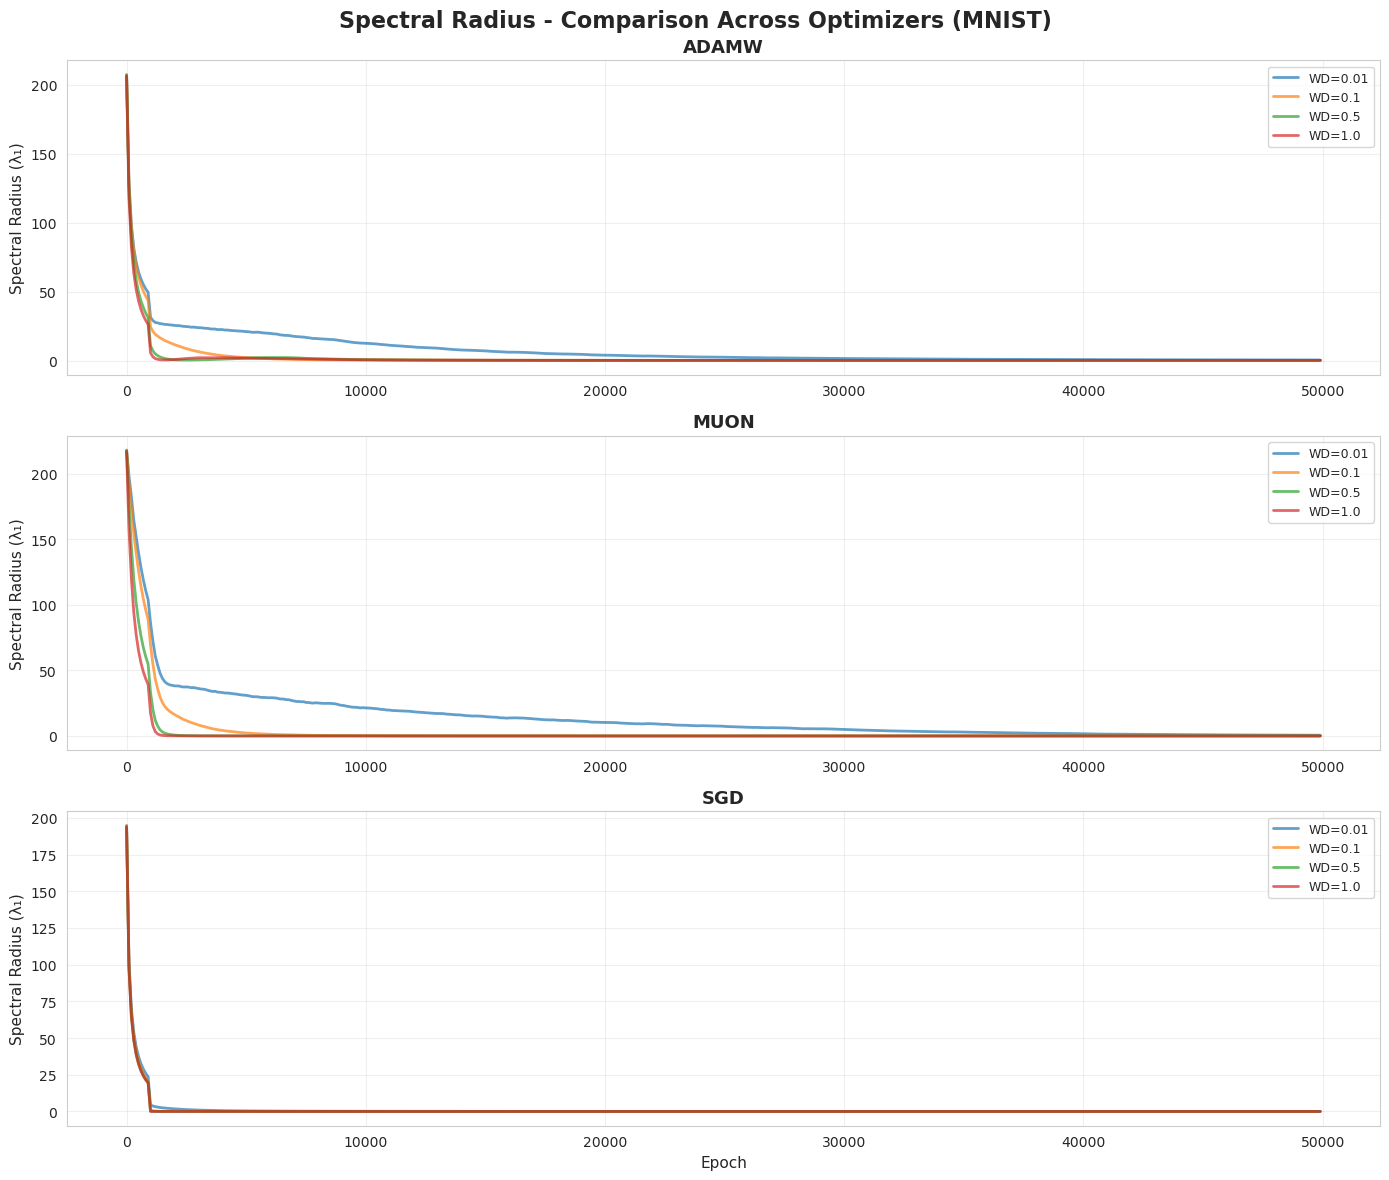

  Saved: mnist_agop-spectral-radius_optimizer_comparison.png


In [27]:
# Create comparison plots for each metric across all optimizers
for metric_name, metric_label, metric_title in agop_metrics:
    print(f"\nGenerating cross-optimizer comparison for {metric_title}...")
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))
    
    for opt_idx, (opt, sorted_exps) in enumerate(mnist_by_opt.items()):
        ax = axes[opt_idx]
        
        for exp_name, exp_data in sorted_exps:
            history = exp_data.get('history', {})
            config = exp_data.get('config', {})
            
            if metric_name not in history:
                continue
            
            epochs = np.array(history.get('epoch', range(len(history.get('test_acc', [])))))
            metric_values = np.array(history[metric_name])
            wd = config.get('weight_decay', 0)
            
            # Smooth the metric
            metric_smooth = smooth_series(metric_values, window=10)
            
            # Plot
            ax.plot(epochs[:len(metric_smooth)], metric_smooth, linewidth=2, 
                   label=f'WD={wd}', alpha=0.7)
        
        ax.set_title(f'{opt.upper()}', fontsize=13, fontweight='bold')
        ax.set_ylabel(metric_label, fontsize=11)
        ax.legend(fontsize=9, loc='best')
        ax.grid(alpha=0.3)
        
        if opt_idx == 2:
            ax.set_xlabel('Epoch', fontsize=11)
    
    fig.suptitle(f'{metric_title} - Comparison Across Optimizers (MNIST)', 
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    safe_metric_name = metric_name.replace('_', '-')
    plt.savefig(FIGURES_DIR / f'mnist_{safe_metric_name}_optimizer_comparison.png', 
               dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"  Saved: mnist_{safe_metric_name}_optimizer_comparison.png")


---
# Section 3: Correlation Analysis

Compute correlations between AGOP metrics and test accuracy to understand which metrics
are most predictive of generalization performance.


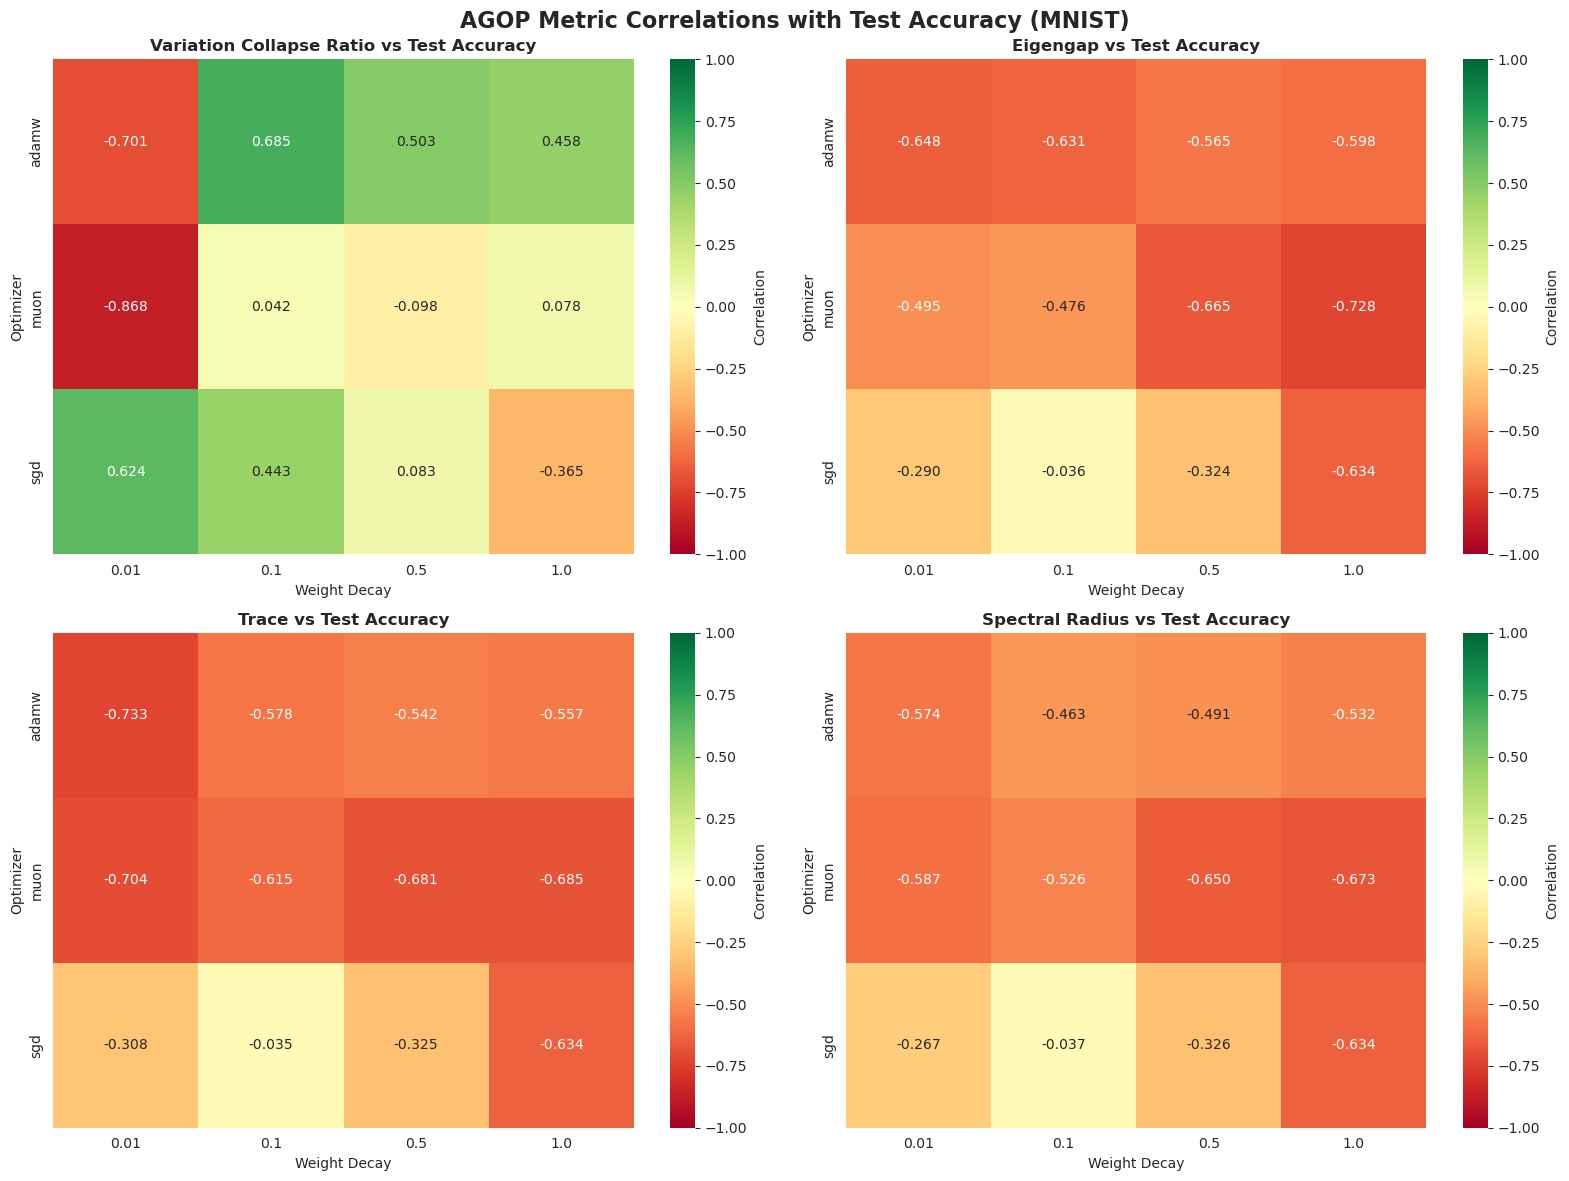

Saved: mnist_agop_correlation_heatmaps.png

Correlation Summary by Metric:


,mean,std,min,max
metric,,,,
Variation Collapse Ratio,0.073639,0.509404,-0.868154,0.684934
Spectral Radius,-0.480035,0.186013,-0.672742,-0.036939
Eigengap,-0.507555,0.200027,-0.728147,-0.036294
Trace,-0.533034,0.207939,-0.733356,-0.035205


In [28]:
# Compute correlations for each experiment
correlation_results = []

for exp_name, exp_data in experiments.items():
    history = exp_data.get('history', {})
    config = exp_data.get('config', {})
    
    if 'test_acc' not in history:
        continue
    
    test_acc = np.array(history['test_acc'])
    
    for metric_name, _, metric_title in agop_metrics:
        if metric_name not in history:
            continue
        
        metric_values = np.array(history[metric_name])
        
        # Align lengths
        min_len = min(len(test_acc), len(metric_values))
        
        # Compute correlation
        corr = np.corrcoef(test_acc[:min_len], metric_values[:min_len])[0, 1]
        
        correlation_results.append({
            'experiment': exp_name,
            'optimizer': config.get('optimizer', 'unknown'),
            'weight_decay': config.get('weight_decay', 0),
            'metric': metric_title,
            'correlation': corr
        })

corr_df = pd.DataFrame(correlation_results)

# Create pivot table for heatmap
pivot_data = {}
for metric_title in corr_df['metric'].unique():
    metric_data = corr_df[corr_df['metric'] == metric_title]
    pivot = metric_data.pivot_table(values='correlation', 
                                    index='optimizer', 
                                    columns='weight_decay',
                                    aggfunc='mean')
    pivot_data[metric_title] = pivot

# Plot heatmaps
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (metric_title, pivot) in enumerate(pivot_data.items()):
    ax = axes[idx]
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', center=0, 
                vmin=-1, vmax=1, ax=ax, cbar_kws={'label': 'Correlation'})
    ax.set_title(f'{metric_title} vs Test Accuracy', fontsize=12, fontweight='bold')
    ax.set_xlabel('Weight Decay', fontsize=10)
    ax.set_ylabel('Optimizer', fontsize=10)

fig.suptitle('AGOP Metric Correlations with Test Accuracy (MNIST)', 
            fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'mnist_agop_correlation_heatmaps.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: mnist_agop_correlation_heatmaps.png")

# Display summary statistics
print("\nCorrelation Summary by Metric:")
print("="*80)
summary = corr_df.groupby('metric')['correlation'].agg(['mean', 'std', 'min', 'max'])
display(summary.sort_values('mean', ascending=False))


---
# Section 4: Key Findings Summary

Summarize the main findings from the MNIST analysis.


In [ ]:
print("="*80)
print("MNIST AGOP ANALYSIS - KEY FINDINGS")
print("="*80)

# Overall grokking statistics
print(f"\n1. GROKKING STATISTICS:")
print(f"   Total experiments: {len(experiments)}")
print(f"   Experiments that grokked: {grokked} ({grok_rate:.1f}%)")
print(f"   Experiments that did not grok: {total - grokked} ({100-grok_rate:.1f}%)")

# By optimizer
print(f"\n2. GROKKING BY OPTIMIZER:")
for opt in ['adamw', 'muon', 'sgd']:
    opt_df = summary_df[summary_df['optimizer'] == opt]
    if len(opt_df) > 0:
        opt_grok = opt_df['grokked'].sum()
        opt_total = len(opt_df)
        print(f"   {opt.upper()}: {opt_grok}/{opt_total} grokked ({opt_grok/opt_total*100:.1f}%)")

# Grokking timing
print(f"\n3. GROKKING TIMING (for experiments that grokked):")
grokked_exps = grokking_df[grokking_df['grok_epoch'] > 0]
if len(grokked_exps) > 0:
    print(f"   Mean grokking epoch: {grokked_exps['grok_epoch'].mean():.0f}")
    print(f"   Median grokking epoch: {grokked_exps['grok_epoch'].median():.0f}")
    print(f"   Earliest grokking: {grokked_exps['grok_epoch'].min():.0f}")
    print(f"   Latest grokking: {grokked_exps['grok_epoch'].max():.0f}")

# Final performance
print(f"\n4. FINAL PERFORMANCE:")
print(f"   Mean final test accuracy (all): {grokking_df['final_test_acc'].mean():.4f}")
print(f"   Mean final test accuracy (grokked): {grokked_exps['final_test_acc'].mean():.4f}")
non_grokked = grokking_df[grokking_df['grok_epoch'] <= 0]
if len(non_grokked) > 0:
    print(f"   Mean final test accuracy (non-grokked): {non_grokked['final_test_acc'].mean():.4f}")

# AGOP metric correlations
print(f"\n5. AGOP METRIC CORRELATIONS WITH TEST ACCURACY:")
for metric_title in corr_df['metric'].unique():
    metric_corrs = corr_df[corr_df['metric'] == metric_title]['correlation']
    print(f"   {metric_title}: mean={metric_corrs.mean():.3f}, std={metric_corrs.std():.3f}")

print(f"\n{'='*80}")
print(f"Analysis complete! All figures saved to: {FIGURES_DIR.absolute()}")
print(f"{'='*80}")


MNIST AGOP ANALYSIS - KEY FINDINGS

1. GROKKING STATISTICS:
   Total experiments: 12
   Experiments that grokked: 4 (33.3%)
   Experiments that did not grok: 8 (66.7%)

2. GROKKING BY OPTIMIZER:
   ADAMW: 0/4 grokked (0.0%)
   MUON: 0/4 grokked (0.0%)
   SGD: 0/4 grokked (0.0%)

3. GROKKING TIMING (for experiments that grokked):


NameError: name 'grokking_df' is not defined

---
# Section 5: Lazy-to-Rich Training Dynamics Analysis

Based on Kumar et al. (2024) "Grokking as the Transition from Lazy to Rich Training Dynamics"

This section analyzes:
1. NTK distance from initialization (lazy→rich transition indicator)
2. Weight norm evolution during training
3. Feature kernel distance evolution
4. Correlation between lazy-rich metrics and AGOP metrics
5. Correlation between lazy-rich transition timing and grokking

Reference: https://arxiv.org/abs/2310.06110


In [ ]:
# Import additional lazy-rich analysis functions
from analysis_utils import (
    get_lazy_rich_metrics, detect_lazy_rich_transition, compute_lazy_rich_summary,
    plot_lazy_rich_dynamics, plot_transition_heatmap, correlate_agop_lazy_rich,
    generate_lazy_rich_summary_table
)

# Check if lazy-rich metrics are available
has_lazy_rich = False
for exp_name, exp_data in experiments.items():
    if 'lazy_rich' in exp_data and exp_data['lazy_rich']:
        has_lazy_rich = True
        break

if has_lazy_rich:
    print("Lazy-Rich metrics available! Proceeding with analysis...")
    
    # Generate summary table with lazy-rich metrics
    lr_summary_df = generate_lazy_rich_summary_table(experiments)
    print("\nLazy-Rich Summary:")
    display(lr_summary_df.sort_values(['optimizer', 'weight_decay']))
else:
    print("NOTE: Lazy-Rich metrics not yet available.")
    print("Re-run experiments with the updated training scripts to generate these metrics.")
    print("The new training scripts will compute:")
    print("  - NTK distance from initialization")
    print("  - Weight norm evolution")
    print("  - Feature kernel distance")


In [ ]:
# Plot NTK distance evolution (if available)
if has_lazy_rich:
    print("Plotting NTK Distance Evolution by Optimizer...")
    
    fig = plot_lazy_rich_dynamics(
        experiments, 
        metric='ntk_distance',
        groupby='optimizer',
        smooth_window=3,
        with_accuracy=True
    )
    
    plt.savefig(FIGURES_DIR / 'mnist_ntk_distance_by_optimizer.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: mnist_ntk_distance_by_optimizer.png")
else:
    print("Skipping NTK distance plot - metrics not available")


In [ ]:
# Plot Weight Norm evolution (if available)
if has_lazy_rich:
    print("Plotting Weight Norm Evolution by Optimizer...")
    
    fig = plot_lazy_rich_dynamics(
        experiments, 
        metric='weight_norm_total',
        groupby='optimizer',
        smooth_window=3,
        with_accuracy=True
    )
    
    plt.savefig(FIGURES_DIR / 'mnist_weight_norm_by_optimizer.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: mnist_weight_norm_by_optimizer.png")
else:
    print("Skipping weight norm plot - metrics not available")


In [ ]:
# Create heatmaps showing lazy-rich transition characteristics
if has_lazy_rich:
    print("Creating Lazy-Rich Transition Heatmaps...")
    
    # NTK Distance Max heatmap
    fig = plot_transition_heatmap(
        experiments,
        row_key='optimizer',
        col_key='weight_decay',
        metric='ntk_distance_max'
    )
    plt.savefig(FIGURES_DIR / 'mnist_ntk_distance_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: mnist_ntk_distance_heatmap.png")
    
    # Weight norm ratio heatmap
    fig = plot_transition_heatmap(
        experiments,
        row_key='optimizer',
        col_key='weight_decay',
        metric='weight_norm_ratio'
    )
    plt.savefig(FIGURES_DIR / 'mnist_weight_norm_ratio_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: mnist_weight_norm_ratio_heatmap.png")
else:
    print("Skipping heatmaps - metrics not available")


In [ ]:
# Compute correlations between AGOP and Lazy-Rich metrics
if has_lazy_rich:
    print("Computing AGOP ↔ Lazy-Rich Correlations...")
    print("="*80)
    
    agop_metrics_to_check = ['agop_eigengap', 'agop_trace', 'agop_variation_collapse_ratio']
    lr_metrics_to_check = ['ntk_distance', 'weight_norm_total']
    
    correlation_table = []
    
    for agop_m in agop_metrics_to_check:
        for lr_m in lr_metrics_to_check:
            corr_result = correlate_agop_lazy_rich(experiments, agop_m, lr_m)
            correlation_table.append({
                'AGOP Metric': agop_m.replace('agop_', ''),
                'Lazy-Rich Metric': lr_m,
                'Pearson r': corr_result.get('pearson_r', np.nan),
                'Pearson p': corr_result.get('pearson_p', np.nan),
                'Spearman r': corr_result.get('spearman_r', np.nan),
                'n': corr_result.get('n', 0)
            })
    
    corr_table_df = pd.DataFrame(correlation_table)
    print("\nCorrelation Table (final values):")
    display(corr_table_df)
    
    # Highlight significant correlations
    print("\nSignificant Correlations (p < 0.05):")
    sig = corr_table_df[corr_table_df['Pearson p'] < 0.05]
    if len(sig) > 0:
        display(sig)
    else:
        print("  No significant correlations found")
else:
    print("Skipping correlations - metrics not available")


In [ ]:
# Summary of Lazy-Rich Analysis
if has_lazy_rich:
    print("="*80)
    print("LAZY-RICH TRAINING DYNAMICS - KEY FINDINGS (MNIST)")
    print("="*80)
    
    # Get summary stats
    for opt in ['adamw', 'muon', 'sgd']:
        opt_exps = filter_experiments(experiments, optimizer=opt)
        if len(opt_exps) > 0:
            print(f"\n{opt.upper()} Optimizer:")
            
            ntk_distances = []
            weight_ratios = []
            transitions = []
            
            for exp_name, exp_data in opt_exps.items():
                summary = compute_lazy_rich_summary(exp_data)
                if 'ntk_distance_max' in summary:
                    ntk_distances.append(summary['ntk_distance_max'])
                if 'weight_norm_ratio' in summary:
                    weight_ratios.append(summary['weight_norm_ratio'])
                if summary.get('lazy_rich_transition_epoch', -1) > 0:
                    transitions.append(summary['lazy_rich_transition_epoch'])
            
            if ntk_distances:
                print(f"  Mean Max NTK Distance: {np.mean(ntk_distances):.4f}")
            if weight_ratios:
                print(f"  Mean Weight Norm Ratio (final/initial): {np.mean(weight_ratios):.4f}")
            if transitions:
                print(f"  Detected Transitions: {len(transitions)}/{len(opt_exps)}")
                print(f"  Mean Transition Epoch: {np.mean(transitions):.0f}")
    
    print(f"\n{'='*80}")
    print("Key Questions to Investigate:")
    print("  1. Does NTK distance spike correlate with test accuracy improvement?")
    print("  2. Do optimizers that grok have different NTK evolution patterns?")
    print("  3. Is weight norm growth predictive of lazy→rich transition?")
    print("  4. How do AGOP eigengap changes relate to NTK distance?")
    print(f"{'='*80}")
else:
    print("="*80)
    print("LAZY-RICH ANALYSIS - METRICS NOT YET AVAILABLE")
    print("="*80)
    print("\nTo generate lazy-rich metrics, re-run experiments with updated training scripts.")
    print("The new metrics will enable analysis of:")
    print("  - NTK evolution and lazy→rich transition timing")
    print("  - Weight norm dynamics during grokking")
    print("  - Correlation between feature learning and AGOP metrics")
    print("="*80)
